# RM Training with CustomRewardTrainer

In [ ]:
# To Do
# * deepspeed
# * loss with sentence similarity coefficient

In [ ]:
'''
cd /workspace
pip install "huggingface_hub[hf_transfer]"
pip install hf_transfer
HF_HUB_ENABLE_HF_TRANSFER=1 huggingface-cli download Ray2333/GRM-Llama3.2-3B-rewardmodel-ft --local-dir ./llama3b-rm/
'''

In [ ]:
!pip install datasets
!pip install transformers
!pip install accelerate
!pip install numpy, pandas, polars
!pip install matplotlib
!pip install sentence_transformers
#!pip install huggingface_hub
!pip install evaluate
#!pip install mistralai
#!pip install flask

# For vLLM
#!pip install vllm  #==0.6.5
#!pip install ray
#!pip install packaging
#!pip install typing

In [1]:
!pip install transformers #==4.48.0
!pip install datasets  #==3.2.0
!pip install trl==0.14.0
!pip install peft
#!pip install deepspeed
#!pip install mpi4py-mpich
!pip install pandas
!pip install vllm==0.6.5
!pip install evaluate
!pip install sentence_transformers

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 1.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.5/40.5 kB 5.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.7/57.7 kB 19.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 171.3 MB/s eta 0:00:00 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 469.0/469.0 kB 125.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 781.7/781.7 kB 165.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 471.6/471.6 kB 138.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 215.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.5/78.5 kB 35.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.6/193.6 kB 77.4 MB/s eta 0:00:00
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2023.4.0
    Uninstalling fsspec-2023.4.0:
      Successfully uninstalled fsspec-2023.4.0

[notice] A new release of pi

In [ ]:
!pip install -U typing_extensions==4.11.0
!pip install pandas
!pip install numpy
!pip install pyarrow

In [2]:
from trl import RewardTrainer, RewardConfig
from peft import LoraConfig, TaskType
import accelerate

In [3]:
import random
import pandas as pd
from operator import itemgetter
import torch
import torch.nn as nn
import warnings
warnings.filterwarnings('ignore')
from datasets import Dataset, load_dataset, load_from_disk
from transformers import AutoModelForSequenceClassification,AutoTokenizer,TrainingArguments,AutoConfig,AutoModelForCausalLM

## Prepare Data

In [ ]:
# Reference
# https://medium.com/towards-generative-ai/reward-model-training-2209d1befb5f

exp_dir = "exp10"
model_save_dir = f"{exp_dir}/model2"
model_name = "llama3b-rm"
data_save_path = "bigcodebench3.json"
advice_save_path = "code-log5-corr1.json"
data_dict_save_path = f"{exp_dir}/data_dict.json"
dataset_list_save_path = f"{exp_dir}/dataset_list2"
dataset_save_path = f"{exp_dir}/dataset2"
batch_size_per_device = 1
num_advice_per_batch = 13  # total number of advice including both chosen and rejected per 1 batch
num_gpu = 4
test_size = 48
avoid_topk = 10 # avoid topk similar advices to each advice list being included in rejected advice

import json, os

if not os.path.exists(exp_dir):
    os.makedirs(exp_dir)

if not os.path.exists(data_dict_save_path):
    
    with open(data_save_path) as f:
        data_dict = json.load(f)
    
    task_id=data_dict["task_id"]
    complete_prompt=data_dict["complete_prompt"]
    instruct_prompt=data_dict["instruct_prompt"]
    canonical_solution=data_dict["canonical_solution"]
    code_prompt=data_dict["code_prompt"]
    test=data_dict["test"]
    doc_struct=data_dict["doc_struct"]
    num_problems = len(task_id)
    
    with open(advice_save_path) as f:
        log = json.load(f)
    
    data_dict = {"problem_id":[], "problem":[], "advice":[], "advice_id":[], "output":[], "correct":[], "log_ids":[], "node_state":[]}
    
    def search_log(log_dict, log_ids):  # node_id: str
        global data_dict
        node_id = log_ids[-1]
    
        if type(log_dict[node_id]) != dict:
            return None
            
        if "children" in log_dict[node_id]:
            for next_node_id in log_dict[node_id]["children"]:
                problem_id_str = log_ids[0]
                problem_id = int(problem_id_str)
                problem = instruct_prompt[problem_id]
                advice_list = log_dict[node_id]["children"][next_node_id]["instruction_list"]
    
                if "corrects" in log_dict[node_id]["children"][next_node_id]:  # when quiting the inference after finihing creating advice
                    all_correct = True
                    all_incorrect = True
                    child_num_correct = 0
                    child_num_problem = 0
                    for advice_id, advice in enumerate(advice_list):
                        correct = log_dict[node_id]["children"][next_node_id]["corrects"][str(advice_id)]
                        child_num_problem += 1
                        if correct:
                            all_incorrect = False
                            child_num_correct += 1
                        else:
                            all_correct = False
    
                    if child_num_problem == 0: continue
    
                    for advice_id, advice in enumerate(advice_list):
                        correct = log_dict[node_id]["children"][next_node_id]["corrects"][str(advice_id)]
                        #output = log_dict[node_id]["children"][next_node_id]["outputs"][str(advice_id)]
                        output = log_dict[node_id]["outputs"]["0"]
                        data_dict["problem_id"].append(problem_id)
                        data_dict["problem"].append(problem)
                        data_dict["output"].append(output)
                        data_dict["advice"].append(advice)
                        data_dict["advice_id"].append(advice_id)
                        data_dict["correct"].append(correct)
                        data_dict["log_ids"].append(log_ids+[next_node_id])
                        data_dict["node_state"].append({"num_problem":len(advice_list), "child_num_correct":child_num_correct, "all_correct":all_correct, "all_incorrect":all_incorrect})
    
                    if all_incorrect:
                        search_log(log_dict[node_id]["children"], log_ids + [next_node_id])
    
    problem_ids_with_advice = []
    for problem_id_str in log:
        if type(log[problem_id_str])==dict:
            if "children" in log[problem_id_str]:
                problem_ids_with_advice.append(int(problem_id_str))
                search_log(log, [problem_id_str])
    
    with open(f"{exp_dir}/data_dict.json", "w") as f: json.dump(data_dict, f)
    with open(f"{exp_dir}/problem_ids_with_advice.json", "w") as f: json.dump(problem_ids_with_advice, f)

else:
    with open(f"{exp_dir}/data_dict.json") as f: data_dict = json.load(f)
    with open(f"{exp_dir}/problem_ids_with_advice.json") as f: problem_ids_with_advice = json.load(f)



In [ ]:

if not os.path.exists(f"{exp_dir}/advice_similarities.pt"):
    # Get similarities between advice so that avoid rejected advice being important for the problems
    from sentence_transformers import SentenceTransformer
    from sentence_transformers.util import cos_sim
    from sentence_transformers.quantization import quantize_embeddings
    
    # 1. Specify preffered dimensions
    dimensions = 512
    
    # 2. load model
    model = SentenceTransformer("mixedbread-ai/mxbai-embed-large-v1", truncate_dim=dimensions).to("cuda")
    advices = data_dict["advice"]
    # The prompt used for query retrieval tasks:
    # query_prompt = 'Represent this sentence for searching relevant passages: '
    
    # 2. Encode
    query_embedding = model.encode(advices, prompt_name="query")
    # Equivalent Alternatives:
    # query_embedding = model.encode(query_prompt + query)
    # query_embedding = model.encode(query, prompt=query_prompt)
    
    docs_embeddings = model.encode(advices)
    
    # Optional: Quantize the embeddings
    binary_query_embedding = quantize_embeddings(query_embedding, precision="ubinary")
    binary_query_embedding = torch.tensor(binary_query_embedding).to("cuda")
    binary_docs_embeddings = quantize_embeddings(docs_embeddings, precision="ubinary")
    binary_docs_embeddings = torch.tensor(binary_docs_embeddings).to("cuda")
    
    advice_similarities = cos_sim(query_embedding, docs_embeddings)
    torch.save(advice_similarities, f"{exp_dir}/advice_similarities.pt")
    
else:
    advice_similarities = torch.load(f"{exp_dir}/advice_similarities.pt")


In [ ]:

if not os.path.exists(dataset_list_save_path):
    df = pd.DataFrame(data_dict)
    df['id'] = range(len(df))
    dataset_list = []
    
    for problem_id in problem_ids_with_advice:
        #problem = instruct_prompt[problem_id]
        chosen_df = df[df['problem_id'] == problem_id]
        problem = chosen_df['problem'].values[0]
        output = chosen_df['output'].values[0]
        chosen_ids = chosen_df["id"].tolist()
        all_avoid_ids = []
        for chosen_id in chosen_ids:
            _, avoid_ids = torch.topk(advice_similarities[chosen_id], k=avoid_topk)
            avoid_ids = avoid_ids.tolist()
            all_avoid_ids += avoid_ids
        
        rejected_df = df.drop(all_avoid_ids)[df['problem_id'] != problem_id]
        len_chosen_df = len(chosen_df)
        if not chosen_df.empty and not rejected_df.empty:
            if len_chosen_df<4:
                num_chosen = len_chosen_df
                num_rejected = num_advice_per_batch - len_chosen_df
            else: # For the case there are too many chosen advices
                num_chosen = 3
                num_rejected = num_advice_per_batch - num_chosen
            chosen_rows = chosen_df.sample(n=num_chosen)
            rejected_rows = rejected_df.sample(n=num_rejected)
            chosen_advice_ids = chosen_rows["id"].tolist()
            rejected_advice_ids = rejected_rows["id"].tolist()
            #chosen_reject_similarities = advice_similarities[chosen_ids][:, rejected_ids]
            chosen_advices = []
            rejected_advices = []
            for i in range(num_chosen):
                chosen_advice = chosen_rows['advice'].values[i]
                #chosen_advice_id = chosen_rows['advice_id'].values[i]
                chosen_advices.append(chosen_advice)
                #chosen_advice_ids.append(int(chosen_advice_id))
            for i in range(num_rejected):
                rejected_advice = rejected_rows['advice'].values[i]
                #rejected_advice_id = rejected_rows['advice_id'].values[i]
                rejected_advices.append(rejected_advice)
                #rejected_advice_ids.append(int(rejected_advice_id))
                
            dataset_list.append({
                "problem_id": problem_id,
                "problem": problem,
                "output": output,
                "chosen_advices": chosen_advices,
                "rejected_advices": rejected_advices,
                "chosen_advice_ids":chosen_advice_ids,
                "rejected_advice_ids":rejected_advice_ids,
            })
        else:
            #print(f"problem {problem_id} doesn't have any advice")
            continue
    
    if num_gpu*batch_size_per_device != 1:
        num_trash = len(dataset_list)%(num_gpu*batch_size_per_device)
        dataset_list = dataset_list[:-num_trash]
    
    with open(dataset_list_save_path, "w") as f:
        json.dump(dataset_list, f)
        
else:
    with open(dataset_list_save_path) as f:
        dataset_list = json.load(f)

dataset1 = Dataset.from_list(dataset_list)
dataset1.to_pandas()

In [ ]:
import os
if not os.path.exists(dataset_save_path):
    tokenizer = AutoTokenizer.from_pretrained(model_name, padding_side="left",add_eos_token=True,add_bos_token=True)
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token
        config.pad_token_id = config.eos_token_id
    
    def formatting_func(examples):
        kwargs = {"padding": "max_length", "truncation": True, "max_length": 4000, "return_tensors": "pt", "add_special_tokens":False}
        answer = examples['output'][:4000]
        problem = examples['problem']
        chosen_advices = examples['chosen_advices']
        rejected_advices = examples['rejected_advices']
        chosen_ids = examples['chosen_advice_ids']
        rejected_ids = examples['rejected_advice_ids']
    
        chosen_prompts=[]
        for chosen_advice in chosen_advices:
            message = [
              {'role': 'user', 'content': f"Give me an advice to the problem and answer below;\n\nProblem:{problem}\n\nAnswer:{answer}"},
              {'role': 'assistant', 'content': f"{chosen_advice}"}
            ]
            prompt_plus_chosen_response = tokenizer.apply_chat_template(message, tokenize=False)
            chosen_prompts.append(prompt_plus_chosen_response)
    
        rejected_prompts=[]
        for rejected_advice in rejected_advices:
            message = [
              {'role': 'user', 'content': f"Give me an advice to the problem and answer below;\n\nProblem:{problem}\n\nAnswer:{answer}"},
              {'role': 'assistant', 'content': f"{rejected_advice}"}
            ]
            prompt_plus_rejected_response = tokenizer.apply_chat_template(message, tokenize=False)
            rejected_prompts.append(prompt_plus_rejected_response)

        
        prompts = chosen_prompts+rejected_prompts
        inputs = tokenizer(prompts, **kwargs)

        chosen_reject_similarities = advice_similarities[chosen_ids][:, rejected_ids]
        
        return {
            "num_chosen":len(chosen_prompts), "num_rejected":len(rejected_prompts),
            "input_ids":inputs["input_ids"], "attention_mask":inputs["attention_mask"],
            "chosen_reject_similarities":chosen_reject_similarities,
        }

    formatted_dataset = dataset1.map(formatting_func)
    formatted_dataset = formatted_dataset.train_test_split(test_size=test_size)
    formatted_dataset.save_to_disk(dataset_save_path)
else:
    formatted_dataset = load_from_disk(dataset_save_path)
    
formatted_dataset

## Load Model

In [ ]:
from transformers import AutoModelForSequenceClassification,AutoTokenizer,TrainingArguments,AutoConfig,AutoModelForCausalLM
#model_name = "Ray2333/GRM-gemma2-2B-rewardmodel-ft"
#model_name = "gemma2b-rm"
model_name = "llama3b-rm"

tokenizer = AutoTokenizer.from_pretrained(model_name, padding_side="left",add_eos_token=True,add_bos_token=True)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
    config.pad_token_id = config.eos_token_id

# Load the pre-trained model without the LM head.
# AutoModelForCausalLM usually refers to models with the LM head included, so you'd typically use a more specific base model class.
#base_model = AutoModelForCausalLM.from_config(config).base_model
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=1)


## Custom RewardTrainer

In [ ]:
# Copyright 2025 The HuggingFace Team. All rights reserved.
#
# Licensed under the Apache License, Version 2.0 (the "License");
# you may not use this file except in compliance with the License.
# You may obtain a copy of the License at
#
#     http://www.apache.org/licenses/LICENSE-2.0
#
# Unless required by applicable law or agreed to in writing, software
# distributed under the License is distributed on an "AS IS" BASIS,
# WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
# See the License for the specific language governing permissions and
# limitations under the License.

import inspect
import os
import warnings
from collections import defaultdict
from dataclasses import FrozenInstanceError, replace
from typing import Any, Callable, Optional, Union

import pandas as pd
import torch
import torch.nn as nn
from accelerate import PartialState
from accelerate.utils import gather_object
from datasets import Dataset
from transformers import (
    BaseImageProcessor,
    DataCollator,
    FeatureExtractionMixin,
    PreTrainedModel,
    PreTrainedTokenizerBase,
    ProcessorMixin,
    Trainer,
    is_wandb_available,
)
from transformers.trainer_callback import TrainerCallback
from transformers.trainer_pt_utils import nested_detach
from transformers.trainer_utils import EvalPrediction
from transformers.utils import is_peft_available

from transformers import Trainer
from trl.trainer.utils import compute_accuracy

'''
from trl.data_utils import maybe_apply_chat_template
from trl.trainer.reward_config import RewardConfig
from trl.trainer.utils import (
    RewardDataCollatorWithPadding,
    compute_accuracy,
    decode_and_strip_padding,
    disable_dropout_in_model,
    generate_model_card,
    get_comet_experiment_url,
    log_table_to_comet_experiment,
    print_rich_table,
)
'''

#class CustomRewardTrainer(RewardTrainer):
class CustomRewardTrainer(Trainer):
    _tag_names = ["trl", "reward-trainer"]

    def __init__(self, *args, **kwargs):
        super().__init__(compute_metrics=compute_accuracy, *args, **kwargs)

    def compute_loss(
        self,
        model: Union[PreTrainedModel, nn.Module],
        inputs: dict[str, Union[torch.Tensor, Any]],
        return_outputs=False,
        num_items_in_batch=None,
    ) -> Union[torch.Tensor, tuple[torch.Tensor, dict[str, torch.Tensor]]]:

        n_chosens = inputs["num_chosen"]  #[num_gpus]
        n_rejecteds = inputs["num_rejected"]  #[num_gpus]
        chosen_reject_similarities = inputs["chosen_reject_similarities"]  #[num_gpus, n_chosens, n_rejecteds]

        #print(inputs["input_ids_chosen"].shape)
        #print(inputs["input_ids_rejected"].shape)

        num_gpus, num_advice, max_length = inputs["input_ids"].shape
        input_ids = inputs["input_ids"].reshape(num_gpus*num_advice, max_length)
        attention_mask = inputs["attention_mask"].reshape(num_gpus*num_advice, max_length)
        #print(inputs["input_ids"].shape)
        #attention_mask = inputs["attention_mask"].reshape(inputs["attention_mask"].shape[0]*inputs["attention_mask"].shape[1], inputs["attention_mask"].shape[2])

        all_rewards = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            return_dict=True,
        )["logits"]

        #print("1", all_rewards.shape)
        all_rewards = all_rewards.reshape(num_gpus,num_advice)
        #print("2", all_rewards.shape)
        
        all_chosen_idx = []
        all_rejected_idx = []
        total_loss = 0
        for i in range(num_gpus):
            rewards = all_rewards[i]
            
            n_chosen = n_chosens[i]
            n_rejected = n_rejecteds[i]
            n_rows = n_chosen * n_rejected
            n_cols = n_chosen + n_rejected
            chosen_idx = torch.arange(n_chosen).repeat_interleave(n_rejected)   # shape: [n_rows]
            rejected_idx = torch.arange(n_rejected).repeat(n_chosen)   # shape: [n_rows]
            all_chosen_idx.append(chosen_idx)
            all_rejected_idx.append(rejected_idx)
            
            # Create cr_matrix
            cr_matrix = torch.zeros(n_rows, n_cols)
            rows = torch.arange(n_rows)
            cr_matrix[rows, chosen_idx] = 1
            cr_matrix[rows, n_chosen + rejected_idx] = -1
            cr_matrix = cr_matrix.to(rewards.device)

            # Create coe_vector
            sims = chosen_reject_similarities[chosen_idx, rejected_idx] # shape: [n_rows]
            coe_vector = 1-sims

            print(coe_vector.shape)
            print(coe_vector)

            # Test cr_matrix
            test_tensor = torch.ones(rewards.shape).to(cr_matrix.device)
            result_tensor = torch.matmul(cr_matrix, test_tensor)
            #print("result_tensor.shape: ", result_tensor.shape)
            #print("result_tensor.mean() : ", result_tensor.mean())
            
            # calculate loss, optionally modulate with margin
            if "margin" in inputs:
                loss = -nn.functional.logsigmoid(coe_vector * torch.matmul(cr_matrix, rewards) - inputs["margin"]).mean()
            else:
                loss = -nn.functional.logsigmoid(coe_vector * torch.matmul(cr_matrix, rewards)).mean()

            total_loss += loss
            #all_losses.append(loss)

        #total_loss = torch.tensor(all_losses).mean()
        
        if return_outputs:
            return total_loss, {
                "all_rewards": all_rewards,
                "all_chosen_idx": all_chosen_idx,
                "all_rejected_idx": all_rejected_idx,
                "n_chosen":n_chosen,
                "n_rejected":n_rejected,
            }
        return total_loss

    def prediction_step(
        self,
        model: Union[PreTrainedModel, nn.Module],
        inputs: dict[str, Union[torch.Tensor, Any]],
        prediction_loss_only: bool,
        ignore_keys: Optional[list[str]] = None,
    ) -> tuple[Optional[torch.Tensor], Optional[torch.Tensor], Optional[torch.Tensor]]:
        
        inputs = self._prepare_inputs(inputs)
        if ignore_keys is None:
            if hasattr(self.model, "config"):
                ignore_keys = getattr(self.model.config, "keys_to_ignore_at_inference", [])
            else:
                ignore_keys = []

        with torch.no_grad():
            loss, logits_dict = self.compute_loss(model, inputs, return_outputs=True)

        '''
        chosen_rewards = logits_dict["chosen_rewards"]
        rejected_rewards = logits_dict["rejected_rewards"]
        chosen_idx = logits_dict["chosen_idx"]
        rejected_idx = logits_dict["rejected_idx"]
        '''

        all_rewards = logits_dict["all_rewards"]
        all_chosen_idx = logits_dict["all_chosen_idx"]
        all_rejected_idx = logits_dict["all_rejected_idx"]
        n_chosen = logits_dict["n_chosen"]
        n_rejected = logits_dict["n_rejected"]
        
        if prediction_loss_only:
            return (loss, None, None)

        loss = loss.detach()
        all_logits = torch.tensor([])
        for i in range(len(all_rewards)):
            rewards = all_rewards[i]
            #print("rewards.shape: ", rewards.shape)
            #print("all_chosen_idx[i]: ", all_chosen_idx[i])
            chosen_logits = rewards[all_chosen_idx[i]].unsqueeze(-1)
            rejected_logits = rewards[n_chosen + all_rejected_idx[i]].unsqueeze(-1)
            logits = torch.cat((chosen_logits, rejected_logits), dim=1)
            #print("logits.shape: ", logits.shape)
            all_logits = all_logits.to(logits.device)
            all_logits = torch.cat((all_logits, logits), dim=0)

        all_logits = all_logits.softmax(dim=1).detach()
        #print("all_logits: ", all_logits)
        #print("all_logits.shape: ", all_logits.shape)
        #logits = torch.cat((chosen_rewards[chosen_idx], rejected_rewards[rejected_idx]), dim=1)
        #logits = logits.softmax(dim=1).detach()
        '''
        logits = tuple(v for k, v in logits_dict.items() if k not in ignore_keys)
        logits = nested_detach(logits)
        # Stack accepted against rejected, mean over logits
        # and softmax to get preferences between accepted and rejected to sum to 1
        logits = torch.stack(logits).mean(dim=2).softmax(dim=0).T
        '''

        labels = torch.zeros(all_logits.shape[0])
        labels = self._prepare_inputs(labels)

        return loss, all_logits, labels

    def train(self, *args, **kwargs): # You need this because it will use RewardTrainer compute_loss method without this. To use a subclass function, some method in the subclass must be called from main directly. 
        return super().train(*args, **kwargs)

    def evaluate(self, *args, **kwargs):
        return super().evaluate(*args, **kwargs)
        #return super(RewardTrainer, self).evaluate(*args, **kwargs)
        #return super().evaluate(num_print_samples=1, *args, **kwargs) # this fell in an error for some reason


## Train

In [ ]:
# Configuring the training arguments
training_args = TrainingArguments(   #RewardConfig(  #
    output_dir=model_save_dir,
    per_device_train_batch_size=batch_size_per_device,
    per_device_eval_batch_size=batch_size_per_device,
    evaluation_strategy="steps",
    eval_steps=20,
    eval_on_start=True,
    save_steps=20,
    logging_steps=1,
    num_train_epochs = 3,
    report_to=None,
    remove_unused_columns=False,
)

from peft import get_peft_model

peft_config = LoraConfig(
    task_type=TaskType.SEQ_CLS,
    inference_mode=False,
    target_modules=["k_proj","q_proj","o_proj", "v_proj","down_proj","gate_proj","up_proj",],
    layers_to_transform=[25,26,27],
    r=16,
    lora_alpha=16,
    lora_dropout=0.1,
)

model = get_peft_model(model, peft_config)

def custom_data_collator(features):
    batch = {}
    
    # For fields that are tensors, we stack them.
    
    tensor_fields = [
        "input_ids", "attention_mask",
    ]
    '''
    tensor_fields = [
        "input_ids_chosen", "attention_mask_chosen",
        "input_ids_rejected", "attention_mask_rejected"
    ]
    '''
    
    for field in tensor_fields:
        batch[field] = torch.stack([torch.tensor(f[field]) for f in features])  #[num_gpus, num_advice_per_batch, max_length]
    
    # For the original prompts (strings), we simply collect them in a list.
    non_tensor_fields = ["num_chosen", "num_rejected", "problem_id"]
    for field in non_tensor_fields:
        batch[field] = [f[field] for f in features]
    
    return batch

# Loading the RewardTrainer from TRL
trainer = CustomRewardTrainer(
    model=model,
    args=training_args,
    tokenizer=tokenizer,
    train_dataset=formatted_dataset["train"],
    eval_dataset=formatted_dataset["test"],
    data_collator=custom_data_collator,
    #peft_config=peft_config,
)

accelerator = trainer.accelerator
model = model.to(accelerator.device)

train_output = trainer.train()

### Visualize

In [ ]:
exp_dir = "exp8"
param_save_path = "model1"
last_check_point = "checkpoint-140"
train_data_path = f"{exp_dir}/{param_save_path}/{last_check_point}/trainer_state.json"

import json
with open(train_data_path) as f:
    train_data = json.load(f)
    log_hist = train_data["log_history"]

train_epoch = []
eval_epoch = []
train_loss = []
eval_loss = []
eval_acc = []
for i, log_hist_data in enumerate(log_hist):
    if "eval_loss" in log_hist_data:
        eval_epoch.append(log_hist_data["epoch"])
        eval_loss.append(log_hist_data["eval_loss"])
        eval_acc.append(log_hist_data["eval_accuracy"])
    else:
        train_epoch.append(log_hist_data["epoch"])
        train_loss.append(log_hist_data["loss"])

import matplotlib.pyplot as plt
# Create a new figure with a specific size
plt.figure(figsize=(8, 6))

# Plot each set of values with markers and labels
plt.plot(train_epoch, train_loss, marker='o', label='train_loss')
plt.plot(eval_epoch, eval_loss, marker='s', label='eval_loss')
plt.plot(eval_epoch, eval_acc, marker='^', label='eval_acc')

# Add labels and title
plt.xlabel('Epoch')
plt.ylabel('Eval Loss and Eval Acc')
plt.title('Search Engine Training')

# Enable the legend and grid
plt.legend()
plt.grid(True)

# Display the plot
plt.show()



## Checkpoint -> Lora Model -> Generate Model

In [ ]:
!pip install -U transformers
!pip install -U peft

In [ ]:
base_model_name = "llama3b-rm"
checkpoint_path = "exp8/model1/checkpoint-120"
save_dir = "exp8-model1-step120"
score_save_path = f"{save_dir}-score.pt"  # default

from transformers import AutoModelForSequenceClassification,AutoTokenizer,TrainingArguments,AutoConfig,AutoModelForCausalLM
from peft import PeftModel, PeftConfig

tokenizer = AutoTokenizer.from_pretrained(base_model_name, padding_side="left",add_eos_token=False,add_bos_token=False)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
    config.pad_token_id = config.eos_token_id

# Load the pre-trained model without the LM head.
# AutoModelForCausalLM usually refers to models with the LM head included, so you'd typically use a more specific base model class.
#base_model = AutoModelForCausalLM.from_config(config).base_model
model = AutoModelForSequenceClassification.from_pretrained(base_model_name, num_labels=1)

lora_model = PeftModel.from_pretrained(model, checkpoint_path)

merged_model = lora_model.merge_and_unload()

merged_model

import torch
torch.save(merged_model.score.weight.data, score_save_path)
tokenizer.save_pretrained(save_dir)
merged_model.save_pretrained(save_dir)

# Convert Classification class into Causal class(because LlamaClassification class is not supported by vllm yet)
from transformers import AutoTokenizer, AutoModelForSequenceClassification, AutoModelForCausalLM
merged_generate_model = AutoModelForCausalLM.from_pretrained(save_dir)
merged_generate_model.save_pretrained(save_dir)
print("Successfully Saved Model")

### test

In [ ]:
base_model_name = "llama3b-rm"
checkpoint_path = "exp7/model1/checkpoint-140"
save_dir = "exp7-model1-step140"
score_save_path = f"{save_dir}-score.pt"  # default

from transformers import AutoModelForSequenceClassification,AutoTokenizer,TrainingArguments,AutoConfig,AutoModelForCausalLM
from peft import PeftModel, PeftConfig

tokenizer = AutoTokenizer.from_pretrained(base_model_name, padding_side="left",add_eos_token=True,add_bos_token=True)
#tokenizer = AutoTokenizer.from_pretrained(base_model_name, padding_side="left",add_eos_token=False,add_bos_token=False)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
    config.pad_token_id = config.eos_token_id

# Load the pre-trained model without the LM head.
# AutoModelForCausalLM usually refers to models with the LM head included, so you'd typically use a more specific base model class.
#base_model = AutoModelForCausalLM.from_config(config).base_model
model = AutoModelForSequenceClassification.from_pretrained(base_model_name, num_labels=1)

lora_model = PeftModel.from_pretrained(model, checkpoint_path)

merged_model = lora_model.merge_and_unload()

merged_model

In [ ]:
merged_model.score.weight.data

In [ ]:
#prompt="Hello, my name is"

message = [
  {'role': 'user', 'content': f"Give me an advice to the problem and answer below;\n\nProblem:\n\nAnswer:"},
  {'role': 'assistant', 'content': f"Advice"}
]
prompt = tokenizer.apply_chat_template(message, tokenize=False)

inputs = tokenizer(prompt, return_tensors="pt", add_special_tokens=False)
outputs = merged_model(**inputs, output_hidden_states=True)

In [ ]:
prompt[17:]

In [ ]:
print(tokenizer.decode(inputs["input_ids"][0], skip_special_tokens=False))
print(outputs.logits)
print(outputs.hidden_states[-1][0][-1])

In [ ]:
tokenizer = AutoTokenizer.from_pretrained(base_model_name, padding_side="left",add_eos_token=False,add_bos_token=False)
print(tokenizer.decode(inputs["input_ids"][0]))
#print(outputs)
print(outputs.hidden_states[-1][0][-1])

In [ ]:
print(tokenizer.decode(inputs["input_ids"][0]))
print(outputs)

In [ ]:
from vllm import LLM, SamplingParams
class pooler_config:
    def __init__(self):
        self.pooling_type = "LAST"
        self.normalize = False
        self.softmax = False
        self.softmax = False
        self.step_tag_id = None
        self.returned_token_ids = None

base_model_name = "llama3b-rm"
checkpoint_path = "exp7/model1/checkpoint-140"
save_dir = "exp7-model1-step140"
score_save_path = f"{save_dir}-score.pt"  # default

from transformers import AutoModelForSequenceClassification,AutoTokenizer,TrainingArguments,AutoConfig,AutoModelForCausalLM

tokenizer = AutoTokenizer.from_pretrained(base_model_name, padding_side="left",add_eos_token=True,add_bos_token=True)
#tokenizer = AutoTokenizer.from_pretrained(base_model_name, padding_side="left",add_eos_token=False,add_bos_token=False)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
    config.pad_token_id = config.eos_token_id

message = [
  {'role': 'user', 'content': f"Give me an advice to the problem and answer below;\n\nProblem:\n\nAnswer:"},
  {'role': 'assistant', 'content': f"Advice"}
]
prompt = tokenizer.apply_chat_template(message, tokenize=False)

pooler_config_ = pooler_config()
model_name = "exp7-model1-step140"
#sampling_params = SamplingParams(skip_special_tokens=False)
llm = LLM(model=model_name,
          dtype="float32",
           tensor_parallel_size=1,
           task="embed",
           override_pooler_config=pooler_config_,)

#prompt="Hello, my name is"

outputs = llm.embed([prompt])


In [ ]:
from vllm import LLM, SamplingParams
class pooler_config:
    def __init__(self):
        self.pooling_type = "LAST"
        self.normalize = False
        self.softmax = False
        self.softmax = False
        self.step_tag_id = None
        self.returned_token_ids = None

base_model_name = "llama3b-rm"
checkpoint_path = "exp7/model1/checkpoint-140"
save_dir = "exp7-model1-step140"
score_save_path = f"{save_dir}-score.pt"  # default

from transformers import AutoModelForSequenceClassification,AutoTokenizer,TrainingArguments,AutoConfig,AutoModelForCausalLM

tokenizer = AutoTokenizer.from_pretrained(base_model_name, padding_side="left",add_eos_token=True,add_bos_token=True)
#tokenizer = AutoTokenizer.from_pretrained(base_model_name, padding_side="left",add_eos_token=False,add_bos_token=False)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
    config.pad_token_id = config.eos_token_id

message = [
  {'role': 'user', 'content': f"Give me an advice to the problem and answer below;\n\nProblem:\n\nAnswer:"},
  {'role': 'assistant', 'content': f"Advice"}
]
prompt = tokenizer.apply_chat_template(message, tokenize=False)

pooler_config_ = pooler_config()
model_name = "exp7-model1-step140"
#sampling_params = SamplingParams(skip_special_tokens=False)
pooling_params = PoolingParams(skip_special_tokens=False)
llm = LLM(model=model_name,
          dtype="float32",
           tensor_parallel_size=1,
           task="encode",
           override_pooler_config=pooler_config_,)

#prompt="Hello, my name is"

outputs = llm.encode([prompt], )


#"float16"
import torch
save_dir = "exp7-model1-step140"
score_save_path = f"{save_dir}-score.pt"  # default
score = torch.load(score_save_path)
print(torch.tensor(outputs[0].outputs.embedding))
reward = torch.matmul(torch.tensor(outputs[0].outputs.embedding), score.transpose(0,1))
reward

In [ ]:
#"float32"
import torch
save_dir = "exp7-model1-step140"
score_save_path = f"{save_dir}-score.pt"  # default
score = torch.load(score_save_path)
print(torch.tensor(outputs[0].outputs.embedding))
reward = torch.matmul(torch.tensor(outputs[0].outputs.embedding), score.transpose(0,1))
reward

In [ ]:
#"bfloat16"
import torch
save_dir = "exp7-model1-step140"
score_save_path = f"{save_dir}-score.pt"  # default
score = torch.load(score_save_path)
print(torch.tensor(outputs[0].outputs.embedding))
reward = torch.matmul(torch.tensor(outputs[0].outputs.embedding), score.transpose(0,1))
reward

In [ ]:
#"float32"
#outputs = llm.embed([prompt[17:]])
outputs = llm.embed([prompt])

import torch
save_dir = "exp7-model1-step140"
score_save_path = f"{save_dir}-score.pt"  # default
score = torch.load(score_save_path)
print(torch.tensor(outputs[0].outputs.embedding))
#outputs #print(tokenizer.decode([128000, 128000, 128006, 9125, 128007, 271, 38766, 1303, 33025, 2696, 25, 6790, 220, 2366, 18, 198, 15724, 2696, 25, 220, 1591, 13806, 220, 2366, 20, 271, 128009, 128006, 882, 128007, 271, 36227, 757, 459, 9650, 311, 279, 3575, 323, 4320, 3770, 401, 32298, 1473, 16533, 25, 128009, 128006, 78191, 128007, 271, 80039, 128009], skip_special_tokens=False))
reward = torch.matmul(torch.tensor(outputs[0].outputs.embedding), score.transpose(0,1))
reward

## Evaluate

In [ ]:
!pip install datasets
!pip install transformers
#!pip install accelerate
!pip install numpy, pandas, polars
!pip install matplotlib
!pip install sentence_transformers
#!pip install huggingface_hub
!pip install evaluate
#!pip install mistralai
#!pip install flask

# For vLLM
!pip install vllm  #==0.6.5
!pip install ray
!pip install packaging
!pip install typing
!pip install -U typing_extensions==4.11.0
!pip install pyarrow

### Delete Overlapping Advices

In [ ]:
exp_dir = "exp8"
model_name = "exp8-model1-step120"
exp_eval_dir = f"{model_name}-eval"
import os
if not os.path.exists(exp_eval_dir): os.makedirs(exp_eval_dir)

data_load_path = "bigcodebench3.json"
advice_load_path = "code-log5-corr1.json"
dataset_load_path = f"{exp_dir}/dataset"

result_save_path = f"{exp_eval_dir}/overlapping_advice_data.json"
train_data_dict_save_path = f"{exp_eval_dir}/train_data_dict.json"
test_data_dict_save_path = f"{exp_eval_dir}/test_data_dict.json"
#train_relevance_save_path = f"{exp_eval_dir}/train_relevance.pt"  # relevance between test_problem and train_advice
#test_relevance_save_path = f"{exp_eval_dir}/test_relevance.pt"  # relevance between test_problem and test_advice
test_problem_and_answer_save_path = f"{exp_eval_dir}/test_problem_and_answer.json"


In [ ]:
import random
import pandas as pd
from operator import itemgetter
import torch
import torch.nn as nn
#from transformers import AutoModelForSequenceClassification,AutoTokenizer,TrainingArguments,AutoConfig,AutoModelForCausalLM
import time

import json
with open(data_load_path) as f:
    data_dict = json.load(f)

task_id=data_dict["task_id"]
complete_prompt=data_dict["complete_prompt"]
instruct_prompt=data_dict["instruct_prompt"]
canonical_solution=data_dict["canonical_solution"]
code_prompt=data_dict["code_prompt"]
test=data_dict["test"]
doc_struct=data_dict["doc_struct"]
num_problems = len(task_id)

with open(advice_load_path) as f:
    log = json.load(f)

from datasets import load_from_disk
formatted_dataset = load_from_disk(dataset_load_path)
train_problem_ids = formatted_dataset["train"]["problem_id"]
test_problem_ids = formatted_dataset["test"]["problem_id"]

data_dict = {"problem_id":[], "problem":[], "advice":[], "advice_id":[], "output":[], "correct":[], "log_ids":[], "node_state":[]}

def search_log(log_dict, log_ids):  # node_id: str
    global data_dict
    node_id = log_ids[-1]

    if type(log_dict[node_id]) != dict:
        return None
        
    if "children" in log_dict[node_id]:
        for next_node_id in log_dict[node_id]["children"]:
            problem_id_str = log_ids[0]
            problem_id = int(problem_id_str)
            problem = instruct_prompt[problem_id]
            advice_list = log_dict[node_id]["children"][next_node_id]["instruction_list"]

            if "corrects" in log_dict[node_id]["children"][next_node_id]:  # when quiting the inference after finihing creating advice
                all_correct = True
                all_incorrect = True
                child_num_correct = 0
                child_num_problem = 0
                for advice_id, advice in enumerate(advice_list):
                    correct = log_dict[node_id]["children"][next_node_id]["corrects"][str(advice_id)]
                    child_num_problem += 1
                    if correct:
                        all_incorrect = False
                        child_num_correct += 1
                    else:
                        all_correct = False

                if child_num_problem == 0: continue

                for advice_id, advice in enumerate(advice_list):
                    correct = log_dict[node_id]["children"][next_node_id]["corrects"][str(advice_id)]
                    output = log_dict[node_id]["children"][next_node_id]["outputs"][str(advice_id)]
                    data_dict["problem_id"].append(problem_id)
                    data_dict["problem"].append(problem)
                    data_dict["output"].append(output)
                    data_dict["advice"].append(advice)
                    data_dict["advice_id"].append(advice_id)
                    data_dict["correct"].append(correct)
                    data_dict["log_ids"].append(log_ids+[next_node_id])
                    data_dict["node_state"].append({"num_problem":len(advice_list), "child_num_correct":child_num_correct, "all_correct":all_correct, "all_incorrect":all_incorrect})

                if all_incorrect:
                    search_log(log_dict[node_id]["children"], log_ids + [next_node_id])


problem_ids_with_advice = []
for problem_id_str in log:
    if problem_id_str.isdigit():
        if int(problem_id_str) in train_problem_ids:
            if "children" in log[problem_id_str]:
                problem_ids_with_advice.append(int(problem_id_str))
                search_log(log, [problem_id_str])

#advices = data_dict["advice"] # this includes only train advice
with open(train_data_dict_save_path, "w") as f:
    json.dump(data_dict, f)


data_dict = {"problem_id":[], "problem":[], "advice":[], "advice_id":[], "output":[], "correct":[], "log_ids":[], "node_state":[]}

problem_ids_with_advice = []
for problem_id_str in log:
    if problem_id_str.isdigit():
        if int(problem_id_str) in test_problem_ids:
            if "children" in log[problem_id_str]:
                problem_ids_with_advice.append(int(problem_id_str))
                search_log(log, [problem_id_str])
                
#advices = data_dict["advice"] # this includes only train advice
with open(test_data_dict_save_path, "w") as f:
    json.dump(data_dict, f)
    

import time
import torch
problems = []
answers = []
new_problem_ids = []
for new_problem_id, problem_id in enumerate(test_problem_ids):
    new_problem_ids.append(new_problem_id)
    problem = instruct_prompt[problem_id]
    problems.append(problem)
    answer = log[str(problem_id)]["outputs"]["0"]
    answers.append(answer)

with open(test_problem_and_answer_save_path, "w") as f:
    json.dump({"problems":problems, "answers":answers}, f)

In [ ]:
import json

if not os.path.exists(f"{exp_eval_dir}/advice_similarities.pt"):
    
    with open(train_data_dict_save_path) as f:
        train_data_dict = json.load(f)

    advices = train_data_dict["advice"]
    
    # Get similarities between advice so that avoid rejected advice being important for the problems
    from sentence_transformers import SentenceTransformer
    from sentence_transformers.util import cos_sim
    from sentence_transformers.quantization import quantize_embeddings
    
    # 1. Specify preffered dimensions
    dimensions = 512

    print("Model Loading...")
    # 2. load model
    model = SentenceTransformer("mixedbread-ai/mxbai-embed-large-v1", truncate_dim=dimensions).to("cuda")
    # The prompt used for query retrieval tasks:
    # query_prompt = 'Represent this sentence for searching relevant passages: '
    
    print("Encoding...")
    # 2. Encode
    query_embedding = model.encode(advices, prompt_name="query")
    # Equivalent Alternatives:
    # query_embedding = model.encode(query_prompt + query)
    # query_embedding = model.encode(query, prompt=query_prompt)
    
    docs_embeddings = model.encode(advices)

    print("Tensorizing...")
    # Optional: Quantize the embeddings
    binary_query_embedding = quantize_embeddings(query_embedding, precision="ubinary")
    binary_query_embedding = torch.tensor(binary_query_embedding).to("cuda")
    binary_docs_embeddings = quantize_embeddings(docs_embeddings, precision="ubinary")
    binary_docs_embeddings = torch.tensor(binary_docs_embeddings).to("cuda")
    
    print("Calculateing Similarities")
    advice_similarities = cos_sim(query_embedding, docs_embeddings)
    torch.save(advice_similarities, f"{exp_eval_dir}/advice_similarities.pt")

    print("Finished Saving")
    
else:
    advice_similarities = torch.load(f"{exp_eval_dir}/advice_similarities.pt")
    
    with open(train_data_dict_save_path) as f:
        train_data_dict = json.load(f)

    advices = train_data_dict["advice"]


In [ ]:
advice_similarities

In [ ]:
import torch

def remove_similar_sentences_optimized(relevance_matrix: torch.Tensor, sentences: list, threshold: float = 0.85):
    """
    Efficiently remove sentences that are too similar based on a precomputed relevance matrix.
    
    This function assumes that if sentence i (with i < j) is accepted and the similarity 
    between sentence i and sentence j exceeds the threshold, then sentence j is removed.
    It uses torch.nonzero to find candidate pairs and loops only over unique candidate j's.
    
    Additionally, the function returns two mappings:
        - similar_mapping_r2a: Mapping from each removed sentence index (r) to the list of accepted 
          sentence indices (a) that are similar.
        - similar_mapping_a2r: Mapping from each accepted sentence index (a) to the list of removed 
          sentence indices (r) that were removed because of similarity.
    
    Args:
        relevance_matrix (torch.Tensor): A square tensor of pairwise relevance scores.
        sentences (list of str): List of sentence strings.
        threshold (float): Similarity threshold above which a sentence is considered too similar.
    
    Returns:
        removed_ids (list of int): Indices of sentences that were removed.
        similar_mapping_r2a (dict): Mapping removed sentence index -> list of accepted similar sentence indices.
        similar_mapping_a2r (dict): Mapping accepted sentence index -> list of removed sentence indices.
    """
    num_sentences = len(sentences)
    # Boolean mask for accepted sentences: True means accepted, False means removed.
    accepted_mask = torch.ones(num_sentences, dtype=torch.bool, device=relevance_matrix.device)
    removed_ids = []
    similar_mapping_r2a = {}  # Mapping: removed sentence index -> accepted sentence indices
    similar_mapping_a2r = {}  # Mapping: accepted sentence index -> removed sentence indices

    # Get candidate pairs (i, j) with i < j and similarity >= threshold.
    candidate_pairs = torch.nonzero(torch.triu(relevance_matrix, diagonal=1) >= threshold, as_tuple=False)
    
    if candidate_pairs.numel() == 0:
        return [], {}, {}

    # Sort candidate pairs by j (the later sentence index).
    candidate_pairs = candidate_pairs[candidate_pairs[:, 1].argsort()]

    # Get unique candidate j's (the ones that might be removed).
    unique_j = torch.unique(candidate_pairs[:, 1])
    
    # Loop only over the candidate j's
    for j in unique_j.tolist():
        # Get all candidate pairs where the second column is j.
        rows = candidate_pairs[candidate_pairs[:, 1] == j]
        # Extract corresponding i indices.
        candidate_is = rows[:, 0]
        # Consider only those i that are still accepted.
        accepted_is = candidate_is[accepted_mask[candidate_is]]
        if accepted_is.numel() > 0:
            # Mark sentence j as removed since it is too similar to one or more accepted sentences.
            accepted_mask[j] = False
            removed_ids.append(j)
            similar_mapping_r2a[j] = accepted_is.tolist()
            # For each accepted sentence that is similar, record that j was removed.
            for acc_id in accepted_is.tolist():
                if acc_id in similar_mapping_a2r:
                    similar_mapping_a2r[acc_id].append(j)
                else:
                    similar_mapping_a2r[acc_id] = [j]
    
    return removed_ids, similar_mapping_r2a, similar_mapping_a2r

'''
# Example usage:
if __name__ == "__main__":
    sentences = [
        "The quick brown fox jumps over the lazy dog.",
        "A quick brown fox jumps over a lazy dog.",
        "Lorem ipsum dolor sit amet, consectetur adipiscing elit.",
        "Consectetur adipiscing elit, sed do eiusmod tempor incididunt ut labore."
    ]
    
    # Example relevance matrix as a torch.Tensor (symmetric, with 1.0 on the diagonal)
    relevance_matrix = torch.tensor([
        [1.0, 0.90, 0.2, 0.1],
        [0.90, 1.0, 0.3, 0.2],
        [0.2, 0.3, 1.0, 0.8],
        [0.1, 0.2, 0.8, 1.0]
    ])
'''

removed_ids, sim_r2a, sim_a2r = remove_similar_sentences_optimized(advice_similarities, advices, threshold=0.8)

print(f"N removed senteces: {len(removed_ids)} / {len(advices)}")
#print("Removed sentence indices:", removed_ids)
print()
print("Mapping of removed sentences to similar accepted sentences:")
print()
for rem_id, sim_ids in sim_r2a.items():
    print(f"rem_id {rem_id}, sim_ids {sim_ids}")
    print(f"Removed Sentence: {advices[rem_id]}")
    for sim_id in sim_ids:
        print(f"Similar Accepted Sentence: {advices[sim_id]}")
    print()

print()
for acc_id, rem_ids in sim_a2r.items():
    print(f"acc_id {acc_id}, rem_ids {rem_ids}")
    print(f"Accept Sentence: {advices[acc_id]}")
    for rem_id in rem_ids:
        print(f"Similar Removed Sentence: {advices[rem_id]}")
    print()

'''
print("Mapping of removed sentences to similar accepted sentences (r2a):")
for rem_id, sim_ids in sim_r2a.items():
    print(f"Sentence {rem_id} is similar to accepted sentences with indices: {sim_ids}")

print()
print()
print("\nMapping of accepted sentences to removed sentences (a2r):")
for acc_id, rem_ids in sim_a2r.items():
    print(f"Sentence {acc_id} has removed similar sentences with indices: {rem_ids}")

'''


In [ ]:
import json

accepted_ids = list(set(range(len(advices))) - set(removed_ids))
with open(result_save_path, "w") as f:
    json.dump({"accepted_ids":accepted_ids, "removed_ids":removed_ids, "sim_r2a":sim_r2a, "sim_a2r":sim_a2r}, f)


In [ ]:
len(accepted_ids), len(removed_ids), len(advices)

#### old

In [ ]:
import torch

def remove_similar_sentences_optimized(relevance_matrix: torch.Tensor, sentences: list, threshold: float = 0.85):
    """
    Remove sentences that are too similar based on a precomputed relevance matrix.
    
    This function assumes that if sentence i (with i < j) is accepted and the similarity 
    between sentence i and sentence j exceeds the threshold, then sentence j is removed.
    It uses torch.nonzero to find candidate pairs and loops only over unique candidate j's.
    
    Args:
        relevance_matrix (torch.Tensor): A square tensor of pairwise relevance scores.
        sentences (list of str): List of sentence strings.
        threshold (float): Similarity threshold above which a sentence is considered too similar.
    
    Returns:
        removed_ids (list of int): Indices of sentences that were removed.
        similar_ids_mapping (dict): A mapping where each key is a removed sentence index and its value
                                    is a list of accepted sentence indices (from the original list)
                                    that are similar.
    """
    num_sentences = len(sentences)
    # Boolean mask for accepted sentences: True means accepted, False means removed.
    accepted_mask = torch.ones(num_sentences, dtype=torch.bool, device=relevance_matrix.device)
    removed_ids = []
    similar_ids_mapping = {}

    # Get candidate pairs (i, j) with i < j and similarity >= threshold.
    # Using torch.triu ensures we only consider pairs with i < j.
    candidate_pairs = torch.nonzero(torch.triu(relevance_matrix, diagonal=1) >= threshold, as_tuple=False)
    
    if candidate_pairs.numel() == 0:
        return [], {}

    # Sort candidate pairs by j (the later sentence index).
    candidate_pairs = candidate_pairs[candidate_pairs[:, 1].argsort()]

    # Get unique candidate j's (the ones that might be removed).
    unique_j = torch.unique(candidate_pairs[:, 1])
    
    # Loop only over the candidate j's
    for j in unique_j.tolist():
        # Get all candidate pairs where the second column is j.
        rows = candidate_pairs[candidate_pairs[:, 1] == j]
        # Extract corresponding i indices.
        candidate_is = rows[:, 0]
        # Consider only those i that are still accepted.
        accepted_is = candidate_is[accepted_mask[candidate_is]]
        if accepted_is.numel() > 0:
            # Mark sentence j as removed since it is too similar to one or more accepted sentences.
            accepted_mask[j] = False
            removed_ids.append(j)
            similar_ids_mapping[j] = accepted_is.tolist()
    
    return removed_ids, similar_ids_mapping



removed_ids, similar_mapping = remove_similar_sentences_optimized(advice_similarities, advices, threshold=0.8)

print(f"N removed senteces: {len(removed_ids)} / {len(advices)}")
#print("Removed sentence indices:", removed_ids)
print()
print("Mapping of removed sentences to similar accepted sentences:")
print()
for rem_id, sim_ids in similar_mapping.items():
    print(f"rem_id {rem_id}, sim_ids {sim_ids}")
    print(f"Removed Sentence: {advices[rem_id]}")
    for sim_id in sim_ids:
        print(f"Similar Sentence: {advices[sim_id]}")
    print()

# You have to check if the similar sentences are different from each other becuase if so, you should also delete them.


### Get Relevance

In [ ]:
exp_dir = "exp8"
model_name = "exp8-model1-step120"
#model_name = "llama3b-generate"
exp_eval_dir = f"{model_name}-eval"
import os
if not os.path.exists(exp_eval_dir): os.makedirs(exp_eval_dir)

data_load_path = "bigcodebench3.json"
advice_load_path = "code-log5-corr1.json"
dataset_load_path = f"{exp_dir}/dataset"
#overlapping_advice_data_load_path = None
overlapping_advice_data_load_path = f"{exp_eval_dir}/overlapping_advice_data.json"

train_data_dict_save_path = f"{exp_eval_dir}/train_data_dict.json"
test_data_dict_save_path = f"{exp_eval_dir}/test_data_dict.json"
train_relevance_save_path = f"{exp_eval_dir}/train_relevance.pt"  # relevance between test_problem and train_advice
test_relevance_save_path = f"{exp_eval_dir}/test_relevance.pt"  # relevance between test_problem and test_advice
test_problem_and_answer_save_path = f"{exp_eval_dir}/test_problem_and_answer.json"

#num_retrival = 30
tensor_parallel_size = 1
num_instances = 4

#model_name = "Ray2333/GRM-Llama3.2-3B-rewardmodel-ft"
score_path = f"{model_name}-score.pt"  # Default
#score_path = f"llama3b_rm_head.pt"

In [ ]:
import random
import pandas as pd
from operator import itemgetter
import torch
import torch.nn as nn
#from transformers import AutoModelForSequenceClassification,AutoTokenizer,TrainingArguments,AutoConfig,AutoModelForCausalLM
import time

import json
with open(data_load_path) as f:
    data_dict = json.load(f)

task_id=data_dict["task_id"]
complete_prompt=data_dict["complete_prompt"]
instruct_prompt=data_dict["instruct_prompt"]
canonical_solution=data_dict["canonical_solution"]
code_prompt=data_dict["code_prompt"]
test=data_dict["test"]
doc_struct=data_dict["doc_struct"]
num_problems = len(task_id)

with open(advice_load_path) as f:
    log = json.load(f)

from datasets import load_from_disk
formatted_dataset = load_from_disk(dataset_load_path)
train_problem_ids = formatted_dataset["train"]["problem_id"]
test_problem_ids = formatted_dataset["test"]["problem_id"]

data_dict = {"problem_id":[], "problem":[], "advice":[], "advice_id":[], "output":[], "correct":[], "log_ids":[], "node_state":[]}

def search_log(log_dict, log_ids):  # node_id: str
    global data_dict
    node_id = log_ids[-1]

    if type(log_dict[node_id]) != dict:
        return None
        
    if "children" in log_dict[node_id]:
        for next_node_id in log_dict[node_id]["children"]:
            problem_id_str = log_ids[0]
            problem_id = int(problem_id_str)
            problem = instruct_prompt[problem_id]
            advice_list = log_dict[node_id]["children"][next_node_id]["instruction_list"]

            if "corrects" in log_dict[node_id]["children"][next_node_id]:  # when quiting the inference after finihing creating advice
                all_correct = True
                all_incorrect = True
                child_num_correct = 0
                child_num_problem = 0
                for advice_id, advice in enumerate(advice_list):
                    correct = log_dict[node_id]["children"][next_node_id]["corrects"][str(advice_id)]
                    child_num_problem += 1
                    if correct:
                        all_incorrect = False
                        child_num_correct += 1
                    else:
                        all_correct = False

                if child_num_problem == 0: continue

                for advice_id, advice in enumerate(advice_list):
                    correct = log_dict[node_id]["children"][next_node_id]["corrects"][str(advice_id)]
                    output = log_dict[node_id]["children"][next_node_id]["outputs"][str(advice_id)]
                    data_dict["problem_id"].append(problem_id)
                    data_dict["problem"].append(problem)
                    data_dict["output"].append(output)
                    data_dict["advice"].append(advice)
                    data_dict["advice_id"].append(advice_id)
                    data_dict["correct"].append(correct)
                    data_dict["log_ids"].append(log_ids+[next_node_id])
                    data_dict["node_state"].append({"num_problem":len(advice_list), "child_num_correct":child_num_correct, "all_correct":all_correct, "all_incorrect":all_incorrect})

                if all_incorrect:
                    search_log(log_dict[node_id]["children"], log_ids + [next_node_id])


problem_ids_with_advice = []
for problem_id_str in log:
    if problem_id_str.isdigit():
        if int(problem_id_str) in train_problem_ids:
            if "children" in log[problem_id_str]:
                problem_ids_with_advice.append(int(problem_id_str))
                search_log(log, [problem_id_str])

#advices = data_dict["advice"] # this includes only train advice
with open(train_data_dict_save_path, "w") as f:
    json.dump(data_dict, f)


data_dict = {"problem_id":[], "problem":[], "advice":[], "advice_id":[], "output":[], "correct":[], "log_ids":[], "node_state":[]}

problem_ids_with_advice = []
for problem_id_str in log:
    if problem_id_str.isdigit():
        if int(problem_id_str) in test_problem_ids:
            if "children" in log[problem_id_str]:
                problem_ids_with_advice.append(int(problem_id_str))
                search_log(log, [problem_id_str])
                
#advices = data_dict["advice"] # this includes only train advice
with open(test_data_dict_save_path, "w") as f:
    json.dump(data_dict, f)
    

import time
import torch

problems = []
answers = []
new_problem_ids = []
for new_problem_id, problem_id in enumerate(test_problem_ids):
    new_problem_ids.append(new_problem_id)
    problem = instruct_prompt[problem_id]
    problems.append(problem)
    answer = log[str(problem_id)]["outputs"]["0"]
    answers.append(answer)

with open(test_problem_and_answer_save_path, "w") as f:
    json.dump({"problems":problems, "answers":answers}, f)

In [ ]:
from typing import Any, Dict, List
import numpy as np
import ray
from packaging.version import Version
from ray.util.scheduling_strategies import PlacementGroupSchedulingStrategy
from vllm import LLM, SamplingParams
assert Version(ray.__version__) >= Version(
    "2.22.0"), "Ray version must be at least 2.22.0"
from transformers import AutoTokenizer, AutoModelForSequenceClassification, AutoModelForCausalLM

class pooler_config:
    def __init__(self):
        self.pooling_type = "LAST"
        self.normalize = False
        self.softmax = False
        self.softmax = False
        self.step_tag_id = None
        self.returned_token_ids = None

pooler_config_ = pooler_config()

tokenizer = AutoTokenizer.from_pretrained(model_name, padding_side="left",add_eos_token=True,add_bos_token=True)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
    config.pad_token_id = config.eos_token_id


# Create a class to do batch inference.
class LLMPredictor:

    def __init__(self):
        # Create an LLM.
        self.llm = LLM(model=model_name,
                       dtype="bfloat16",
                       #dtype="float32",
                       tensor_parallel_size=tensor_parallel_size,
                       task="embed",
                       override_pooler_config=pooler_config_,)

    def __call__(self, batch: Dict[str, np.ndarray]) -> Dict[str, list]:
        outputs = self.llm.embed(batch["prompt"])

        embeddings = []
        for output in outputs:
            embeddings.append(output.outputs.embedding)
            #generated_text.append(' '.join([o.text for o in output.outputs]))

        return {
            "embeddings": embeddings
        }


# Read one text file from S3. Ray Data supports reading multiple files
# from cloud storage (such as JSONL, Parquet, CSV, binary format).
#ds = ray.data.read_text("s3://anonymous@air-example-data/prompts.txt")

# For tensor_parallel_size > 1, we need to create placement groups for vLLM
# to use. Every actor has to have its own placement group.
def scheduling_strategy_fn():
    # One bundle per tensor parallel worker
    pg = ray.util.placement_group(
        [{
            "GPU": 1,
            "CPU": 1
        }] * tensor_parallel_size,
        strategy="STRICT_PACK",
    )
    return dict(scheduling_strategy=PlacementGroupSchedulingStrategy(
        pg, placement_group_capture_child_tasks=True))


resources_kwarg: Dict[str, Any] = {}
if tensor_parallel_size == 1:
    # For tensor_parallel_size == 1, we simply set num_gpus=1.
    resources_kwarg["num_gpus"] = 1
else:
    # Otherwise, we have to set num_gpus=0 and provide
    # a function that will create a placement group for
    # each instance.
    resources_kwarg["num_gpus"] = 0
    resources_kwarg["ray_remote_args_fn"] = scheduling_strategy_fn



def get_relevance(problems, answers, advices):
    
    import pandas as pd
    import itertools
    
    # Generate the Cartesian product
    new_problem_ids = list(range(len(problems)))
    combinations = list(itertools.product(new_problem_ids, advices))
    df = pd.DataFrame(combinations, columns=['problem_id', 'advice'])
    df['problem'] = df['problem_id'].apply(lambda idx: problems[idx])
    df['answer'] = df['problem_id'].apply(lambda idx: answers[idx])
    
    from datasets import Dataset
    dataset1 = Dataset.from_pandas(df)
    
    def format(row):
        advice = row["advice"]
        problem = row["problem"]
        answer = row["answer"]
        answer = answer[:4000]
        
        message = [
          {'role': 'user', 'content': f"Give me an advice to the problem and answer below;\n\nProblem:{problem}\n\nAnswer:{answer}"},
          {'role': 'assistant', 'content': f"{advice}"}
        ]
        prompt = tokenizer.apply_chat_template(message, tokenize=False)
        prompt = prompt[17:]  # to eliminate <|begin_of_text|> because vllm automatically add it to prompt
        row["prompt"] = prompt
        return row
    
    formatted_dataset = dataset1.map(format)
    df_formatted = formatted_dataset.to_pandas()
    list_of_prompts = df_formatted[['prompt']].to_dict('records')  # [{"prompt":".."}, ...]
    
    ds = ray.data.from_items(list_of_prompts)
    #ds = ray.data.read_text("s3://anonymous@air-example-data/prompts.txt")
    
    batch_size = len(list_of_prompts)//num_instances
    
    # Apply batch inference for all input data.
    ds = ds.map_batches(
        LLMPredictor,
        # Set the concurrency to the number of LLM instances.
        concurrency=num_instances,
        # Specify the batch size for inference.
        batch_size=batch_size,
        **resources_kwarg,
    )
    
    # Peek first 10 results.
    # NOTE: This is for local testing and debugging. For production use case,
    # one should write full result out as shown below.
    # outputs = ds.take(limit=10)
    outputs = ds.take_all()  # [{"embeddings":(2d list)}, ...]
    
    #outputs = model.embed(prompts)
    from datasets import Dataset
    import torch
    dataset1 = Dataset.from_list(outputs)
    print("Putting All Embeddings onto GPU...")
    all_embeddings = torch.tensor(dataset1["embeddings"]).to("cuda")
    #all_embeddings = torch.tensor([outputs[i].outputs.embedding for i in range(len(outputs))]).to("cuda")
    rm_head = torch.load(score_path, weights_only=True)
    rm_head = rm_head.to(all_embeddings.device)
    print("Calculating matmul...")
    advice_rewards = torch.matmul(all_embeddings, rm_head.transpose(0,1)).squeeze()
    relevance = advice_rewards.reshape(len(problems), len(advices))  # [len(problems), len(advices)]
    print("Obtained Relevance")
    
    return relevance

#top_advice_rewards, advice_indices = torch.topk(reshaped_advice_rewards, k=num_retrival) # [len(problems), num_advices]
#torch.save(advice_indices, retrieved_advice_ids_save_path)  #all_advice_indices: [len(test_problem_ids), num_retrival]


In [ ]:
import torch

with open(test_problem_and_answer_save_path) as f:
    data_dict = json.load(f)
    problems = data_dict["problems"]
    answers = data_dict["answers"]

with open(train_data_dict_save_path) as f:
    train_data_dict = json.load(f)
    train_advices = train_data_dict["advice"]

with open(test_data_dict_save_path) as f:
    test_data_dict = json.load(f)
    test_advices = test_data_dict["advice"]

if overlapping_advice_data_load_path:
    with open(overlapping_advice_data_load_path) as f:
        overlapping_advice_data = json.load(f)

    accepted_ids = overlapping_advice_data["accepted_ids"]

    accepted_train_advices = []
    for a_id in accepted_ids:
        accepted_train_advices.append(train_advices[a_id])

    n_train_advices = len(accepted_train_advices)
    advices = accepted_train_advices+test_advices
    relevance = get_relevance(problems, answers, advices)
    
    train_relevance = relevance[:,:n_train_advices]
    test_relevance = relevance[:,n_train_advices:]
    
    torch.save(train_relevance, train_relevance_save_path)
    torch.save(test_relevance, test_relevance_save_path)
    
else:
    n_train_advices = len(train_advices)
    advices = train_advices+test_advices
        
    relevance = get_relevance(problems, answers, advices)
    
    train_relevance = relevance[:,:n_train_advices]
    test_relevance = relevance[:,n_train_advices:]
    
    torch.save(train_relevance, train_relevance_save_path)
    torch.save(test_relevance, test_relevance_save_path)

#### old

In [ ]:
import torch

with open(test_problem_and_answer_save_path) as f:
    data_dict = json.load(f)
    problems = data_dict["problems"]
    answers = data_dict["answers"]

with open(train_data_dict_save_path) as f:
    train_data_dict = json.load(f)
    train_advices = train_data_dict["advice"]
    
relevance = get_relevance(problems, answers, train_advices)

torch.save(relevance, train_relevance_save_path)

In [ ]:
import torch

with open(test_problem_and_answer_save_path) as f:
    data_dict = json.load(f)
    problems = data_dict["problems"]
    answers = data_dict["answers"]

with open(test_data_dict_save_path) as f:
    test_data_dict = json.load(f)
    test_advices = test_data_dict["advice"]
    
relevance = get_relevance(problems, answers, test_advices)

torch.save(relevance, test_relevance_save_path)

#### test

In [ ]:
import pandas as pd
import itertools

from typing import Any, Dict, List
import numpy as np
import ray
from packaging.version import Version
from ray.util.scheduling_strategies import PlacementGroupSchedulingStrategy
from vllm import LLM, SamplingParams
assert Version(ray.__version__) >= Version(
    "2.22.0"), "Ray version must be at least 2.22.0"
from transformers import AutoTokenizer, AutoModelForSequenceClassification, AutoModelForCausalLM

class pooler_config:
    def __init__(self):
        self.pooling_type = "LAST"
        self.normalize = False
        self.softmax = False
        self.softmax = False
        self.step_tag_id = None
        self.returned_token_ids = None

pooler_config_ = pooler_config()

tokenizer = AutoTokenizer.from_pretrained(model_name, padding_side="left",add_eos_token=True,add_bos_token=True)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
    config.pad_token_id = config.eos_token_id

with open(test_data_dict_save_path) as f:
    test_data_dict = json.load(f)
    advices = test_data_dict["advice"]

print(len(problems), len(answers), len(advices))

# Generate the Cartesian product
new_problem_ids = list(range(len(problems)))
combinations = list(itertools.product(new_problem_ids, advices))
#print(combinations)
df = pd.DataFrame(combinations, columns=['problem_id', 'advice'])
print(df)
df['problem'] = df['problem_id'].apply(lambda idx: problems[idx])
df['answer'] = df['problem_id'].apply(lambda idx: answers[idx])
print(df)

from datasets import Dataset
dataset1 = Dataset.from_pandas(df)
print(dataset1)

def format(row):
    advice = row["advice"]
    problem = row["problem"]
    answer = row["answer"]
    answer = answer[:4000]
    
    message = [
      {'role': 'user', 'content': f"Give me an advice to the problem and answer below;\n\nProblem:{problem}\n\nAnswer:{answer}"},
      {'role': 'assistant', 'content': f"{advice}"}
    ]
    prompt = tokenizer.apply_chat_template(message, tokenize=False)
    row["prompt"] = prompt
    return row

formatted_dataset = dataset1.map(format)
df_formatted = formatted_dataset.to_pandas()
list_of_prompts = df_formatted[['prompt']].to_dict('records')  # [{"prompt":".."}, ...]
list_of_problem_id = df_formatted[['problem_id']].to_dict('records')  # [{"prompt":".."}, ...]
print(list_of_problem_id[:100])


In [ ]:
torch.tensor(formatted_dataset["problem_id"]).reshape(48, 233)

### Retrival Task

In [ ]:
exp_dir = "exp8"
model_name = "exp8-model1-step120"
#model_name = "llama3b-generate"
exp_eval_dir = f"{model_name}-eval"

data_load_path = "bigcodebench3.json"
advice_load_path = "code-log5-corr1.json"
dataset_load_path = f"{exp_dir}/dataset"
overlapping_advice_data_load_path = f"{exp_eval_dir}/overlapping_advice_data.json"

train_data_dict_save_path = f"{exp_eval_dir}/train_data_dict.json"
test_data_dict_save_path = f"{exp_eval_dir}/test_data_dict.json"
train_relevance_save_path = f"{exp_eval_dir}/train_relevance.pt"  # relevance between test_problem and train_advice
test_relevance_save_path = f"{exp_eval_dir}/test_relevance.pt"  # relevance between test_problem and test_advice
test_problem_and_answer_save_path = f"{exp_eval_dir}/test_problem_and_answer.json"
eval_result_save_path = f"{exp_eval_dir}/eval_result.json"

#num_retrival = 30
#tensor_parallel_size = 1
#num_instances = 2
k_values = [5, 10, 30, 100, 500, 1000]
num_retrieval = max(k_values)

#### With OverlappingAdvice Data

In [ ]:
import json
import torch

with open(train_data_dict_save_path) as f:
    train_data_dict = json.load(f)
    train_advices = train_data_dict["advice"]
    train_advice_problem_ids = train_data_dict["problem_id"]  # index of train_advices -> original_problem_id where advice belongs

with open(overlapping_advice_data_load_path) as f:
    overlapping_advice_data = json.load(f)
    accepted_ids = overlapping_advice_data["accepted_ids"]
    accepted_train_advices = []
    accepted_train_advice_problem_ids = []
    for a_id in accepted_ids:
        accepted_train_advices.append(train_advices[a_id])
        accepted_train_advice_problem_ids.append(train_advice_problem_ids[a_id])
    
with open(test_problem_and_answer_save_path) as f:
    data_dict = json.load(f)
    test_problems = data_dict["problems"]
    test_answers = data_dict["answers"]

with open(test_data_dict_save_path) as f:
    test_data_dict = json.load(f)
    test_advices = test_data_dict["advice"]
    test_advice_problem_ids = test_data_dict["problem_id"]  # index of test_advices -> original_problem_id where advice belongs

train_relevance = torch.load(train_relevance_save_path)  # [len(test_problems), len(train_advices)]
test_relevance = torch.load(test_relevance_save_path)  # [len(test_problems), len(test_dvices)]
n_test_problems, n_train_advices = train_relevance.shape
n_test_problems2, n_test_advices = test_relevance.shape
if not n_test_problems == n_test_problems2: raise Exception("wrong shape")
relevance = torch.cat((train_relevance, test_relevance), dim=1)

advice_problem_ids = accepted_train_advice_problem_ids + test_advice_problem_ids

from datasets import load_from_disk
formatted_dataset = load_from_disk(dataset_load_path)
train_problem_ids = formatted_dataset["train"]["problem_id"]
test_problem_ids = formatted_dataset["test"]["problem_id"]


num_correct_advice_dict = {str(k):[] for k in k_values}
for new_problem_id, original_problem_id in enumerate(test_problem_ids):
    top_values, top_indices = torch.topk(relevance[new_problem_id], k=num_retrieval) # [num_retrieval]
    #print(top_values, top_indices)
    top_indices = top_indices.tolist()
    
    for k in k_values:
        top_indices_ = top_indices[:k]
        top_original_problem_ids = torch.tensor([advice_problem_ids[top_index] for top_index in top_indices_])
        #print(top_original_problem_ids, original_problem_id)
        result_tensor = torch.where(top_original_problem_ids==original_problem_id, 1, 0)
        n_correct_advice = torch.sum(result_tensor).item()
        num_correct_advice_dict[str(k)].append(n_correct_advice)

eval_result = {"num_correct_advice_dict":num_correct_advice_dict, "mean_n_correct_advice":{}}

for k in k_values:
    print()
    print(f"top-{k}")
    mean_n_correct_advice = sum(num_correct_advice_dict[str(k)])/len(num_correct_advice_dict[str(k)])
    print(f"mean n_correct_advice: {mean_n_correct_advice}")
    eval_result["mean_n_correct_advice"][str(k)] = mean_n_correct_advice

with open(eval_result_save_path, "w") as f:
    json.dump(eval_result, f)

print("eval_result has been saved")


#### Normal

In [ ]:
import json
import torch

with open(train_data_dict_save_path) as f:
    train_data_dict = json.load(f)
    train_advices = train_data_dict["advice"]
    train_advice_problem_ids = train_data_dict["problem_id"]  # index of train_advices -> original_problem_id where advice belongs

with open(test_problem_and_answer_save_path) as f:
    data_dict = json.load(f)
    test_problems = data_dict["problems"]
    test_answers = data_dict["answers"]

with open(test_data_dict_save_path) as f:
    test_data_dict = json.load(f)
    test_advices = test_data_dict["advice"]
    test_advice_problem_ids = test_data_dict["problem_id"]  # index of test_advices -> original_problem_id where advice belongs

train_relevance = torch.load(train_relevance_save_path)  # [len(test_problems), len(train_advices)]
test_relevance = torch.load(test_relevance_save_path)  # [len(test_problems), len(test_dvices)]
n_test_problems, n_train_advices = train_relevance.shape
n_test_problems2, n_test_advices = test_relevance.shape
if not n_test_problems == n_test_problems2: raise Exception("wrong shape")
relevance = torch.cat((train_relevance, test_relevance), dim=1)

advice_problem_ids = train_advice_problem_ids + test_advice_problem_ids

from datasets import load_from_disk
formatted_dataset = load_from_disk(dataset_load_path)
train_problem_ids = formatted_dataset["train"]["problem_id"]
test_problem_ids = formatted_dataset["test"]["problem_id"]


num_correct_advice_dict = {str(k):[] for k in k_values}
for new_problem_id, original_problem_id in enumerate(test_problem_ids):
    top_values, top_indices = torch.topk(relevance[new_problem_id], k=num_retrieval) # [num_retrieval]
    #print(top_values, top_indices)
    top_indices = top_indices.tolist()
    
    for k in k_values:
        top_indices_ = top_indices[:k]
        top_original_problem_ids = torch.tensor([advice_problem_ids[top_index] for top_index in top_indices_])
        #print(top_original_problem_ids, original_problem_id)
        result_tensor = torch.where(top_original_problem_ids==original_problem_id, 1, 0)
        n_correct_advice = torch.sum(result_tensor).item()
        num_correct_advice_dict[str(k)].append(n_correct_advice)

eval_result = {"num_correct_advice_dict":num_correct_advice_dict, "mean_n_correct_advice":{}}

for k in k_values:
    print()
    print(f"top-{k}")
    mean_n_correct_advice = sum(num_correct_advice_dict[str(k)])/len(num_correct_advice_dict[str(k)])
    print(f"mean n_correct_advice: {mean_n_correct_advice}")
    eval_result["mean_n_correct_advice"][str(k)] = mean_n_correct_advice

with open(eval_result_save_path, "w") as f:
    json.dump(eval_result, f)

print("eval_result has been saved")


#### test

In [ ]:
import json
import torch

with open(train_data_dict_save_path) as f:
    train_data_dict = json.load(f)
    train_advices = train_data_dict["advice"]
    train_advice_problem_ids = train_data_dict["problem_id"]  # index of train_advices -> original_problem_id where advice belongs

with open(test_problem_and_answer_save_path) as f:
    data_dict = json.load(f)
    test_problems = data_dict["problems"]
    test_answers = data_dict["answers"]

with open(test_data_dict_save_path) as f:
    test_data_dict = json.load(f)
    test_advices = test_data_dict["advice"]
    test_advice_problem_ids = test_data_dict["problem_id"]  # index of test_advices -> original_problem_id where advice belongs

train_relevance = torch.load(train_relevance_save_path)  # [len(test_problems), len(train_advices)]
test_relevance = torch.load(test_relevance_save_path)  # [len(test_problems), len(test_dvices)]
n_test_problems, n_train_advices = train_relevance.shape
n_test_problems2, n_test_advices = test_relevance.shape
if not n_test_problems == n_test_problems2: raise Exception("wrong shape")
relevance = torch.cat((train_relevance, test_relevance), dim=1)

advice_problem_ids = train_advice_problem_ids + test_advice_problem_ids

from datasets import load_from_disk
formatted_dataset = load_from_disk(dataset_load_path)
train_problem_ids = formatted_dataset["train"]["problem_id"]
test_problem_ids = formatted_dataset["test"]["problem_id"]


num_correct_advice_dict = {str(k):[] for k in k_values}
_, n_advices = relevance.shape
for new_problem_id, original_problem_id in enumerate(test_problem_ids):
    #print(torch.where(torch.tensor(test_advice_problem_ids) == original_problem_id)[0])
    right_advice_indices = torch.where(torch.tensor(test_advice_problem_ids) == original_problem_id)[0]
    wrong_advice_indices = torch.randint(n_advices, (1, 4)).squeeze()
    right_rewards = relevance[new_problem_id][right_advice_indices]
    wrong_rewards = relevance[new_problem_id][wrong_advice_indices]
    n_chosen = len(right_advice_indices)
    n_rejected = len(wrong_advice_indices)
    chosen_idx = torch.arange(n_chosen).repeat_interleave(n_rejected)   # shape: [n_rows]
    rejected_idx = torch.arange(n_rejected).repeat(n_chosen)   # shape: [n_rows]
    chosen_rewards = right_rewards[chosen_idx].unsqueeze(-1)
    rejected_rewards = wrong_rewards[rejected_idx].unsqueeze(-1)
    compare_rewards = torch.cat((rejected_rewards, chosen_rewards), dim=1)
    _, indices = torch.topk(compare_rewards, k=1)
    #print(indices) # wanna be all 1
    print(indices.float().mean())

    

In [ ]:
exp_dir = "exp7"
model_name = "exp7-model1-step140"
#model_name = "llama3b-generate"
exp_eval_dir = f"{model_name}-eval"
import os
if not os.path.exists(exp_eval_dir): os.makedirs(exp_eval_dir)

data_load_path = "bigcodebench3.json"
advice_load_path = "code-log5-corr1.json"
dataset_load_path = f"{exp_dir}/dataset"

train_data_dict_save_path = f"{exp_eval_dir}/train_data_dict.json"
test_data_dict_save_path = f"{exp_eval_dir}/test_data_dict.json"
train_relevance_save_path = f"{exp_eval_dir}/train_relevance.pt"  # relevance between test_problem and train_advice
test_relevance_save_path = f"{exp_eval_dir}/test_relevance.pt"  # relevance between test_problem and test_advice
test_problem_and_answer_save_path = f"{exp_eval_dir}/test_problem_and_answer.json"

#num_retrival = 30
tensor_parallel_size = 1
num_instances = 1

#model_name = "Ray2333/GRM-Llama3.2-3B-rewardmodel-ft"
score_path = f"{model_name}-score.pt"  # Default
#score_path = f"llama3b_rm_head.pt"

import json
with open(test_data_dict_save_path) as f:
    test_data_dict = json.load(f)

In [ ]:
test_data_dict["log_ids"]

In [ ]:
train_relevance.shape, test_relevance.shape, relevance.shape, train_problem_ids[:10], test_problem_ids[:10], advice_problem_ids[-10:]

In [ ]:
train_relevance, test_relevance

In [ ]:
print(torch.topk(train_relevance, k=3))
print(torch.topk(test_relevance, k=3))

In [ ]:
top_indices_  #.tolist()

In [ ]:
len(advice_problem_ids)
train_relevance.shape
30/2752, 0.125/5

#### old

In [ ]:
model_name = "exp5/model1-step100"
dataset_save_path = "bigcodebench3.json"
advice_save_path = "code-log5-corr1.json"
train_log_path = "code-log5-corr1-train_log.json"
k_pass = 10
num_sample = 100

#model_name = "llama3b-generate"
#model_name = "Ray2333/GRM-Llama3.2-3B-rewardmodel-ft"
#model_name = "iqwiki-kor/Qwen2.5-3B-MP-RM"
score_path = f"{model_name}-score.pt"  # Default

from vllm import LLM
from transformers import AutoTokenizer, AutoModelForSequenceClassification, AutoModelForCausalLM

class pooler_config:
    def __init__(self):
        self.pooling_type = "LAST"
        self.normalize = False
        self.softmax = False
        self.softmax = False
        self.step_tag_id = None
        self.returned_token_ids = None

pooler_config_ = pooler_config()

model = LLM(
    model=model_name,
    tensor_parallel_size=2,
    task="embed",
    override_pooler_config=pooler_config_,
)

tokenizer = AutoTokenizer.from_pretrained(model_name, padding_side="left",add_eos_token=True,add_bos_token=True)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
    config.pad_token_id = config.eos_token_id

In [ ]:
import random
import pandas as pd
from operator import itemgetter
import torch
import torch.nn as nn
import warnings
warnings.filterwarnings('ignore')
from datasets import Dataset, load_dataset
from transformers import AutoModelForSequenceClassification,AutoTokenizer,TrainingArguments,AutoConfig,AutoModelForCausalLM
from trl import RewardTrainer, RewardConfig
from peft import LoraConfig, TaskType
import accelerate
from vllm import LLM, SamplingParams
import time

import json
with open(dataset_save_path) as f:
    data_dict = json.load(f)

task_id=data_dict["task_id"]
complete_prompt=data_dict["complete_prompt"]
instruct_prompt=data_dict["instruct_prompt"]
canonical_solution=data_dict["canonical_solution"]
code_prompt=data_dict["code_prompt"]
test=data_dict["test"]
doc_struct=data_dict["doc_struct"]
num_problems = len(task_id)

with open(advice_save_path) as f:
    log = json.load(f)

data_dict = {"problem_id":[], "problem":[], "advice":[], "advice_id":[], "correct":[], "log_ids":[], "score":[]}

def search_log(log_dict, log_ids):  # node_id: str
    global data_dict
    node_id = log_ids[-1]

    if type(log_dict[node_id]) != dict:
        return None
        
    if "children" in log_dict[node_id]:
        for next_node_id in log_dict[node_id]["children"]:
            problem_id_str = log_ids[0]
            problem_id = int(problem_id_str)
            problem = instruct_prompt[problem_id]
            advice_list = log_dict[node_id]["children"][next_node_id]["instruction_list"]

            if "corrects" in log_dict[node_id]["children"][next_node_id]:  # when quiting the inference after finihing creating advice
                all_correct = True
                all_incorrect = True
                child_num_correct = 0
                child_num_problem = 0
                for advice_id, advice in enumerate(advice_list):
                    correct = log_dict[node_id]["children"][next_node_id]["corrects"][str(advice_id)]
                    child_num_problem += 1
                    if correct:
                        all_incorrect = False
                        child_num_correct += 1
                    else:
                        all_correct = False

                if child_num_problem == 0: continue

                for advice_id, advice in enumerate(advice_list):
                    correct = log_dict[node_id]["children"][next_node_id]["corrects"][str(advice_id)]
                    data_dict["problem_id"].append(problem_id)
                    data_dict["problem"].append(problem)
                    data_dict["advice"].append(advice)
                    data_dict["advice_id"].append(advice_id)
                    data_dict["correct"].append(correct)
                    data_dict["log_ids"].append(log_ids+[next_node_id])
                    if all_correct: score = 0.1
                    elif all_incorrect: score = 0
                    else:
                        if not correct: score = 0.1 + child_num_correct/child_num_problem
                        else: score = 0.1

                    data_dict["score"].append(score)

                if all_incorrect:
                    search_log(log_dict[node_id]["children"], log_ids + [next_node_id])

with open(train_log_path) as f:
    train_log = json.load(f)
test_problem_ids = train_log["test_problem_ids"]
train_problem_ids = train_log["train_problem_ids"]

problem_ids_with_advice = []
for problem_id_str in log:
    if type(log[problem_id_str])==dict:
        if "children" in log[problem_id_str]:
            problem_ids_with_advice.append(int(problem_id_str))
            search_log(log, [problem_id_str])

advices = data_dict["advice"] # this includes both train advice and test advice
rm_head = torch.load(score_path)
#sampling_params = SamplingParams(max_tokens=1, temperature=1, top_p=0.95)

def search(problem, num_advices):
    global rm_head
    texts = []
    for i in range(len(advices)):
        message = [
          {'role': 'user', 'content': f"Give me an advice to the problem below;\n\nProblem:{problem}"},
          {'role': 'assistant', 'content': f"{advices[i]}"}
        ]
        text = tokenizer.apply_chat_template(message, tokenize=False)
        texts.append(text)

    outputs = model.embed(texts)
    all_embeddings = torch.tensor([outputs[i].outputs.embedding for i in range(len(outputs))]).to("cuda")
    rm_head = rm_head.to(all_embeddings.device)
    advice_rewards = torch.matmul(all_embeddings, rm_head.transpose(0,1)).squeeze()

    advice_rewards, advice_indices = torch.topk(advice_rewards, k=num_advices)

    return advice_rewards, advice_indices

import time
num_problem = 0
pass1_count = 0
passk_count = 0
start = time.time()
for i, problem in enumerate(data_dict["problem"][:num_sample]):
    advice_rewards, advice_indices = search(problem, k_pass)  # [top1, top2, top3]
    print("advice_rewards: ", advice_rewards)
    print("advice_indices: ", advice_indices)
    wrap = time.time()
    print(f"{wrap-start} has passed. {(i+1)/num_sample} finished")
    num_problem+=1
    for j, advice_index in enumerate(advice_indices):
        if i==advice_index:
            passk_count+=1
            if j==0:
                pass1_count+=1
            break
            
    pass1 = pass1_count/num_problem
    passk = passk_count/num_problem
    print(f"pass1: ", pass1)
    print(f"pass{k_pass}: ", passk)
    

### Generation Task

In [ ]:
!pip install datasets
!pip install transformers
#!pip install accelerate
!pip install numpy, pandas, polars
!pip install matplotlib
!pip install sentence_transformers
#!pip install huggingface_hub
!pip install evaluate
#!pip install mistralai
#!pip install flask

# For vLLM
!pip install vllm  #==0.6.5
!pip install ray
!pip install packaging
!pip install typing
!pip install -U typing_extensions==4.11.0
!pip install pyarrow

In [ ]:
exp_dir = "exp7"
model_name = "exp7-model1-step140"
data_save_path = "bigcodebench3.json"
log_save_path = "code-log5-corr1.json"
#train_advices_save_path = f"{exp_dir}/train_advices.json"
#retrieved_advice_ids_save_path = f"{exp_dir}/retrieved_advice_ids.pt"
dataset_save_path = f"{exp_dir}/dataset"
exp_eval_dir = f"{model_name}-eval2"

overlapping_advice_data_load_path = f"{exp_eval_dir}/overlapping_advice_data.json"
train_data_dict_save_path = f"{exp_eval_dir}/train_data_dict.json"
test_data_dict_save_path = f"{exp_eval_dir}/test_data_dict.json"
train_relevance_save_path = f"{exp_eval_dir}/train_relevance.pt"  # relevance between test_problem and train_advice
test_relevance_save_path = f"{exp_eval_dir}/test_relevance.pt"  # relevance between test_problem and test_advice
test_problem_and_answer_save_path = f"{exp_eval_dir}/test_problem_and_answer.json"
eval_result_path = f"{exp_eval_dir}/eval_result.json"

num_retrieval = 5
tensor_parallel_size = 2
model = "deepseek_r1_qwen14b"
max_tokens = 15000
temperature = 0.4

In [ ]:
import json
import torch

with open(train_data_dict_save_path) as f:
    train_data_dict = json.load(f)
    advices = train_data_dict["advice"]

if os.path.exists(overlapping_advice_data_load_path):
    with open(overlapping_advice_data_load_path) as f:
        overlapping_advice_data = json.load(f)
        accepted_ids = overlapping_advice_data["accepted_ids"]


train_relevance = torch.load(train_relevance_save_path)

from datasets import load_from_disk
formatted_dataset = load_from_disk(dataset_save_path)
train_problem_ids = formatted_dataset["train"]["problem_id"]#.to_list()
test_problem_ids = formatted_dataset["test"]["problem_id"]#.to_list()

with open(data_save_path) as f:
    data_dict = json.load(f)
with open(log_save_path) as f:
    log = json.load(f)

task_id=data_dict["task_id"]
complete_prompt=data_dict["complete_prompt"]
instruct_prompt=data_dict["instruct_prompt"]
canonical_solution=data_dict["canonical_solution"]
code_prompt=data_dict["code_prompt"]
test=data_dict["test"]
doc_struct=data_dict["doc_struct"]
num_problems = len(task_id)

In [ ]:


from vllm import LLM, SamplingParams
llm = LLM(model=model, tensor_parallel_size=tensor_parallel_size)
sampling_params = SamplingParams(max_tokens=max_tokens, temperature=temperature, top_p=0.95)

from transformers import AutoTokenizer
tokenizer = AutoTokenizer.from_pretrained(model, padding_side="left",add_eos_token=True,add_bos_token=True)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
    config.pad_token_id = config.eos_token_id


In [ ]:
#advice_num = 5
pre_prompts = []
pre_outputs = []
prompts2 = []
for test_problem_id in test_problem_ids:
    pre_prompt = log[str(test_problem_id)]["prompts"]["0"]
    pre_output = log[str(test_problem_id)]["outputs"]["0"]
    pre_prompts.append(pre_prompt)
    pre_outputs.append(pre_output)

for i, prompt in enumerate(pre_prompts):
    #prompt = output.prompt
    #generated_text = output.outputs[0].text
    generated_text = pre_outputs[i]
    test_problem_id = test_problem_ids[i]

    values, top_indices = torch.topk(train_relevance[i], k=num_retrieval)
    advices_text = ""

    if os.path.exists(overlapping_advice_data_load_path):
        for j, top_index in enumerate(top_indices):
            advice_index = accepted_ids[top_index.item()]
            advices_text += f"\nAdvice {j+1}: {advices[advice_index]}"
    else:
        for j, top_index in enumerate(top_indices):
            advices_text += f"\nAdvice {j+1}: {advices[top_index.item()]}"

    print()
    print(i)
    print(advices_text)
    
    messages = [
        {"role": "user", "content": prompt[29:][:-13]},
        {"role": "assistant", "content": generated_text},
        {"role": "user", "content": f"""Your answer might contain some errors. Please revise your answer following the advice below;
{advices_text}"""}
    ]

    prompt = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
    )
    
    prompts2.append(prompt)

outputs2 = llm.generate(prompts2, sampling_params)

In [ ]:
import re
def extract_text_inside_backticks(text, arbitrary_text):
    # Define the pattern to match the text inside ``` that follows the arbitrary text
    pattern = re.compile(r'```{}\s*([\s\S]*?)\s*```'.format(re.escape(arbitrary_text)))

    # Search for the pattern in the text
    match = pattern.search(text)

    if match:
        return match.group(1).strip()
    else:
        return None


test_cases = []
candidates = []
for i, output in enumerate(outputs2):
    prompt = output.prompt
    generated_text = output.outputs[0].text
    test_problem_id = test_problem_ids[i]
    test_code = test[test_problem_id]
    
    output_code = extract_text_inside_backticks(generated_text, "python")
    if not output_code: output_code = extract_text_inside_backticks(generated_text, "")
    if not output_code: output_code = "raise Exception()"

    test_cases.append(test_code)
    candidates.append([output_code])
    
import os, time
os.environ["HF_ALLOW_CODE_EVAL"] = "1"
from code_eval.code_eval import CodeEval
code_eval_metric = CodeEval()
# Compute pass@k
k_values = [1]
print("Evaluating generated code...")
start = time.time()
pass_at_k, results = code_eval_metric._compute(
    references=test_cases,
    predictions=candidates,
    k=k_values,
    num_workers=10,  # Adjust based on your system
    timeout=150.0,   # Adjust the timeout as needed
)
end = time.time()
print("calculation time(s): ", end-start)

correct_list = []
correct_num = 0
problem_num = 0
for i in range(len(results)):
    problem_id = test_problem_ids[i]
    unexpected_error = False
    if results[i] == []:
        is_correct = False  # [] appeared sometimes for unknown reason. I define it as incorrect for now, but it should be fixed.
        unexpected_error = True
    else: is_correct = results[i][0][1]["passed"]

    correct_list.append(is_correct)
    problem_num +=1
    if is_correct: correct_num += 1

print("with advice")
print("acc: ", correct_num/problem_num)



In [ ]:
with open(eval_result_path) as f:
    eval_result = json.load(f)

acc = correct_num/problem_num
eval_result["generation_acc"] = acc

with open(eval_result_path, "w") as f:
    json.dump(eval_result, f)

In [ ]:
# Human Eval comparing retrieved advice + generate advice(correct)
import torch
advice_save_path = "code-log5-corr1.json"
#train_log_path = f"{advice_save_path[:-5]}-train_log.json"
#test_id_save_path = f"{advice_save_path[:-5]}-test_ids.pt"
#advices_save_path = f"{advice_save_path[:-5]}-advices.json"

import json
'''
import torch
all_advice_indices = torch.load(test_id_save_path)
with open(advices_save_path) as f:
    advices = json.load(f)
'''

from datasets import load_from_disk
formatted_dataset = load_from_disk(dataset_save_path)
train_problem_ids = formatted_dataset["train"]["problem_id"]#.to_list()
test_problem_ids = formatted_dataset["test"]["problem_id"]

'''
with open(train_log_path) as f:
    train_log = json.load(f)
test_problem_ids = train_log["test_problem_ids"]
train_problem_ids = train_log["train_problem_ids"]
'''
with open(data_save_path) as f:
    data_dict = json.load(f)
with open(log_save_path) as f:
    log = json.load(f)

task_id=data_dict["task_id"]
complete_prompt=data_dict["complete_prompt"]
instruct_prompt=data_dict["instruct_prompt"]
canonical_solution=data_dict["canonical_solution"]
code_prompt=data_dict["code_prompt"]
test=data_dict["test"]
doc_struct=data_dict["doc_struct"]
num_problems = len(task_id)


advice_num = 5
pre_prompts = []
pre_outputs = []
prompts2 = []
for test_problem_id in test_problem_ids:
    pre_prompt = log[str(test_problem_id)]["prompts"]["0"]
    pre_output = log[str(test_problem_id)]["outputs"]["0"]
    pre_prompts.append(pre_prompt)
    pre_outputs.append(pre_output)

for i, prompt in enumerate(pre_prompts):
    #prompt = output.prompt
    #generated_text = output.outputs[0].text
    #generated_text = pre_outputs[i]
    
    test_problem_id = test_problem_ids[i]
    
    values, top_indices = torch.topk(train_relevance[i], k=num_retrieval)
    advices_text = ""
    for j, top_index in enumerate(top_indices):
        advice_index = accepted_ids[top_index.item()]
        advices_text += f"Advice {j+1}: {advices[advice_index]}\n"

    print()
    print(i, test_problem_id, results[i][0][1]["passed"])
    print("Retrieved Advice")
    print(advices_text)

    advice_list = log[str(test_problem_id)]["children"]["0"]["instruction_list"]
    print("Generated Advice")
    for j, advice in enumerate(advice_list):
        print(f"Advice {j+1}: {advice}")

### Generation Task with embedding model

In [ ]:
exp_dir = "exp7"
model_name = "exp7-model1-step140"
data_save_path = "bigcodebench3.json"
log_save_path = "code-log5-corr1.json"
#train_advices_save_path = f"{exp_dir}/train_advices.json"
#retrieved_advice_ids_save_path = f"{exp_dir}/retrieved_advice_ids.pt"
dataset_save_path = f"{exp_dir}/dataset"
exp_eval_dir = f"{model_name}-eval2"

overlapping_advice_data_load_path = f"{exp_eval_dir}/overlapping_advice_data.json"
train_data_dict_save_path = f"{exp_eval_dir}/train_data_dict.json"
test_data_dict_save_path = f"{exp_eval_dir}/test_data_dict.json"
train_relevance_save_path = f"{exp_eval_dir}/train_relevance.pt"  # relevance between test_problem and train_advice
test_relevance_save_path = f"{exp_eval_dir}/test_relevance.pt"  # relevance between test_problem and test_advice
test_problem_and_answer_save_path = f"{exp_eval_dir}/test_problem_and_answer.json"
eval_result_path = f"{exp_eval_dir}/eval_result.json"

num_retrieval = 5
tensor_parallel_size = 2
model = "deepseek_r1_qwen14b"
max_tokens = 15000
temperature = 0.4

In [ ]:
import json
import torch

with open(train_data_dict_save_path) as f:
    train_data_dict = json.load(f)
    advices = train_data_dict["advice"]

if os.path.exists(overlapping_advice_data_load_path):
    with open(overlapping_advice_data_load_path) as f:
        overlapping_advice_data = json.load(f)
        accepted_ids = overlapping_advice_data["accepted_ids"]


train_relevance = torch.load(train_relevance_save_path)

from datasets import load_from_disk
formatted_dataset = load_from_disk(dataset_save_path)
train_problem_ids = formatted_dataset["train"]["problem_id"]#.to_list()
test_problem_ids = formatted_dataset["test"]["problem_id"]#.to_list()

with open(data_save_path) as f:
    data_dict = json.load(f)
with open(log_save_path) as f:
    log = json.load(f)

task_id=data_dict["task_id"]
complete_prompt=data_dict["complete_prompt"]
instruct_prompt=data_dict["instruct_prompt"]
canonical_solution=data_dict["canonical_solution"]
code_prompt=data_dict["code_prompt"]
test=data_dict["test"]
doc_struct=data_dict["doc_struct"]
num_problems = len(task_id)

In [ ]:


from vllm import LLM, SamplingParams
llm = LLM(model=model, tensor_parallel_size=tensor_parallel_size)
sampling_params = SamplingParams(max_tokens=max_tokens, temperature=temperature, top_p=0.95)

from transformers import AutoTokenizer
tokenizer = AutoTokenizer.from_pretrained(model, padding_side="left",add_eos_token=True,add_bos_token=True)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
    config.pad_token_id = config.eos_token_id


In [ ]:
#advice_num = 5
pre_prompts = []
pre_outputs = []
prompts2 = []
for test_problem_id in test_problem_ids:
    pre_prompt = log[str(test_problem_id)]["prompts"]["0"]
    pre_output = log[str(test_problem_id)]["outputs"]["0"]
    pre_prompts.append(pre_prompt)
    pre_outputs.append(pre_output)

import random

for i, prompt in enumerate(pre_prompts):
    #prompt = output.prompt
    #generated_text = output.outputs[0].text
    generated_text = pre_outputs[i]
    test_problem_id = test_problem_ids[i]

    values, top_indices = torch.topk(train_relevance[i], k=num_retrieval)
    advices_text = ""

    random_list = random.sample(range(len(advices)), 5)

    for j, index in enumerate(random_list):
        advices_text += f"\nAdvice {j+1}: {advices[index]}"

    print()
    print(i)
    print(advices_text)
    
    messages = [
        {"role": "user", "content": prompt[29:][:-13]},
        {"role": "assistant", "content": generated_text},
        {"role": "user", "content": f"""Your answer might contain some errors. Please revise your answer following the advice below;
{advices_text}"""}
    ]

    prompt = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
    )
    
    prompts2.append(prompt)

outputs2 = llm.generate(prompts2, sampling_params)

In [ ]:
import re
def extract_text_inside_backticks(text, arbitrary_text):
    # Define the pattern to match the text inside ``` that follows the arbitrary text
    pattern = re.compile(r'```{}\s*([\s\S]*?)\s*```'.format(re.escape(arbitrary_text)))

    # Search for the pattern in the text
    match = pattern.search(text)

    if match:
        return match.group(1).strip()
    else:
        return None


test_cases = []
candidates = []
for i, output in enumerate(outputs2):
    prompt = output.prompt
    generated_text = output.outputs[0].text
    test_problem_id = test_problem_ids[i]
    test_code = test[test_problem_id]
    
    output_code = extract_text_inside_backticks(generated_text, "python")
    if not output_code: output_code = extract_text_inside_backticks(generated_text, "")
    if not output_code: output_code = "raise Exception()"

    test_cases.append(test_code)
    candidates.append([output_code])
    
import os, time
os.environ["HF_ALLOW_CODE_EVAL"] = "1"
from code_eval.code_eval import CodeEval
code_eval_metric = CodeEval()
# Compute pass@k
k_values = [1]
print("Evaluating generated code...")
start = time.time()
pass_at_k, results = code_eval_metric._compute(
    references=test_cases,
    predictions=candidates,
    k=k_values,
    num_workers=10,  # Adjust based on your system
    timeout=150.0,   # Adjust the timeout as needed
)
end = time.time()
print("calculation time(s): ", end-start)

correct_list = []
correct_num = 0
problem_num = 0
for i in range(len(results)):
    problem_id = test_problem_ids[i]
    unexpected_error = False
    if results[i] == []:
        is_correct = False  # [] appeared sometimes for unknown reason. I define it as incorrect for now, but it should be fixed.
        unexpected_error = True
    else: is_correct = results[i][0][1]["passed"]

    correct_list.append(is_correct)
    problem_num +=1
    if is_correct: correct_num += 1

print("with advice")
print("acc: ", correct_num/problem_num)



### Human Eval for Advices

In [ ]:
# Check if similar advice in test dataset is included in train dataset
dataset_save_path = "bigcodebench3.json"
log_path = "code-log5-corr1.json"
test_id_save_path = "code-log5-corr1-test_ids.pt"
advices_save_path = "code-log5-corr1-advices.json"
train_log_path = "code-log5-corr1-train_log.json"
tensor_parallel_size = 2
model = "deepseek_r1_qwen14b"
max_tokens = 15000
temperature = 0.4

import json
import torch
all_advice_indices = torch.load(test_id_save_path, map_location=torch.device('cpu'))
with open(advices_save_path) as f:
    train_advices = json.load(f)
with open(train_log_path) as f:
    train_log = json.load(f)
test_problem_ids = train_log["test_problem_ids"]
train_problem_ids = train_log["train_problem_ids"]

with open(dataset_save_path) as f:
    data_dict = json.load(f)
with open(log_path) as f:
    log = json.load(f)

task_id=data_dict["task_id"]
complete_prompt=data_dict["complete_prompt"]
instruct_prompt=data_dict["instruct_prompt"]
canonical_solution=data_dict["canonical_solution"]
code_prompt=data_dict["code_prompt"]
test=data_dict["test"]
doc_struct=data_dict["doc_struct"]
num_problems = len(task_id)

data_dict = {"problem_id":[], "problem":[], "advice":[], "advice_id":[], "correct":[], "log_ids":[], "score":[]}

def search_log(log_dict, log_ids):  # node_id: str
    global data_dict
    node_id = log_ids[-1]

    if type(log_dict[node_id]) != dict:
        return None
        
    if "children" in log_dict[node_id]:
        for next_node_id in log_dict[node_id]["children"]:
            problem_id_str = log_ids[0]
            problem_id = int(problem_id_str)
            problem = instruct_prompt[problem_id]
            advice_list = log_dict[node_id]["children"][next_node_id]["instruction_list"]

            if "corrects" in log_dict[node_id]["children"][next_node_id]:  # when quiting the inference after finihing creating advice
                all_correct = True
                all_incorrect = True
                child_num_correct = 0
                child_num_problem = 0
                for advice_id, advice in enumerate(advice_list):
                    correct = log_dict[node_id]["children"][next_node_id]["corrects"][str(advice_id)]
                    child_num_problem += 1
                    if correct:
                        all_incorrect = False
                        child_num_correct += 1
                    else:
                        all_correct = False

                if child_num_problem == 0: continue

                for advice_id, advice in enumerate(advice_list):
                    correct = log_dict[node_id]["children"][next_node_id]["corrects"][str(advice_id)]
                    data_dict["problem_id"].append(problem_id)
                    data_dict["problem"].append(problem)
                    data_dict["advice"].append(advice)
                    data_dict["advice_id"].append(advice_id)
                    data_dict["correct"].append(correct)
                    data_dict["log_ids"].append(log_ids+[next_node_id])
                    if all_correct: score = 0.1
                    elif all_incorrect: score = 0
                    else:
                        if not correct: score = 0.1 + child_num_correct/child_num_problem
                        else: score = 0.1

                    data_dict["score"].append(score)

                if all_incorrect:
                    search_log(log_dict[node_id]["children"], log_ids + [next_node_id])

with open(train_log_path) as f:
    train_log = json.load(f)
test_problem_ids = train_log["test_problem_ids"]
train_problem_ids = train_log["train_problem_ids"]

problem_ids_with_advice = []
for problem_id_str in log:
    if problem_id_str.isdigit():
        if int(problem_id_str) in test_problem_ids:
            if "children" in log[problem_id_str]:
                problem_ids_with_advice.append(int(problem_id_str))
                search_log(log, [problem_id_str])

test_advices = data_dict["advice"] # this includes only test advice


In [ ]:
# Check if similar advice in test dataset is included in train dataset
from sentence_transformers import SentenceTransformer
from sentence_transformers.util import cos_sim
from sentence_transformers.quantization import quantize_embeddings

# 1. Specify preffered dimensions
dimensions = 512

# 2. load model
model = SentenceTransformer("mixedbread-ai/mxbai-embed-large-v1", truncate_dim=dimensions)

# The prompt used for query retrieval tasks:
# query_prompt = 'Represent this sentence for searching relevant passages: '

query = "A man is eating a piece of bread"
docs = [
    "A man is eating food.",
    "A man is eating pasta.",
    "The girl is carrying a baby.",
    "A man is riding a horse.",
]

# 2. Encode
query_embedding = model.encode(test_advices, prompt_name="query")
# Equivalent Alternatives:
# query_embedding = model.encode(query_prompt + query)
# query_embedding = model.encode(query, prompt=query_prompt)

docs_embeddings = model.encode(train_advices)

# Optional: Quantize the embeddings
binary_query_embedding = quantize_embeddings(query_embedding, precision="ubinary")
binary_docs_embeddings = quantize_embeddings(docs_embeddings, precision="ubinary")

similarities = cos_sim(query_embedding, docs_embeddings)
print('similarities:', similarities)


In [ ]:
values, indices = torch.topk(similarities, k = 5)

In [ ]:
for j in range(len(test_advices)):
    print()
    print("test:")
    print(test_advices[j])
    print("train:")
    for i in range(5):
        print(train_advices[indices[j, i].item()])

# RM Training with normal RewardTrainer

In [ ]:
# To Do
# * deepspeed
# * loss with sentence similarity coefficient

In [ ]:
'''
cd /workspace
pip install "huggingface_hub[hf_transfer]"
pip install hf_transfer
HF_HUB_ENABLE_HF_TRANSFER=1 huggingface-cli download Ray2333/GRM-Llama3.2-3B-rewardmodel-ft --local-dir ./llama3b-rm/
'''

In [ ]:
!pip install datasets
!pip install transformers
!pip install accelerate
!pip install numpy, pandas, polars
!pip install matplotlib
!pip install sentence_transformers
#!pip install huggingface_hub
!pip install evaluate
#!pip install mistralai
#!pip install flask

# For vLLM
#!pip install vllm  #==0.6.5
#!pip install ray
#!pip install packaging
#!pip install typing

In [1]:
!pip install transformers #==4.48.0
!pip install datasets  #==3.2.0
!pip install trl==0.14.0
!pip install peft
#!pip install deepspeed
#!pip install mpi4py-mpich
!pip install matplotlib
!pip install pandas
!pip install vllm==0.6.5
!pip install evaluate
!pip install sentence_transformers


[notice] A new release of pip is available: 23.3.1 -> 25.0.1
[notice] To update, run: python -m pip install --upgrade pip

[notice] A new release of pip is available: 23.3.1 -> 25.0.1
[notice] To update, run: python -m pip install --upgrade pip

[notice] A new release of pip is available: 23.3.1 -> 25.0.1
[notice] To update, run: python -m pip install --upgrade pip

[notice] A new release of pip is available: 23.3.1 -> 25.0.1
[notice] To update, run: python -m pip install --upgrade pip

[notice] A new release of pip is available: 23.3.1 -> 25.0.1
[notice] To update, run: python -m pip install --upgrade pip

[notice] A new release of pip is available: 23.3.1 -> 25.0.1
[notice] To update, run: python -m pip install --upgrade pip

[notice] A new release of pip is available: 23.3.1 -> 25.0.1
[notice] To update, run: python -m pip install --upgrade pip

[notice] A new release of pip is available: 23.3.1 -> 25.0.1
[notice] To update, run: python -m pip install --upgrade pip

[notice] A new 

In [ ]:
!pip install -U typing_extensions==4.11.0
!pip install pandas
!pip install numpy
!pip install pyarrow

In [2]:
from trl import RewardTrainer, RewardConfig
from peft import LoraConfig, TaskType
import accelerate

In [3]:
import random
import pandas as pd
from operator import itemgetter
import torch
import torch.nn as nn
import warnings
warnings.filterwarnings('ignore')
from datasets import Dataset, load_dataset, load_from_disk
from transformers import AutoModelForSequenceClassification,AutoTokenizer,TrainingArguments,AutoConfig,AutoModelForCausalLM

In [3]:
exp_dir = "exp11"
model_save_dir = f"{exp_dir}/model1"
model_name = "llama3b-rm"
data_save_path = "bigcodebench3.json"
advice_save_path = "code-log5-corr1.json"
data_dict_save_path = f"{exp_dir}/data_dict.json"
dataset_list_save_path = f"{exp_dir}/dataset_list.json"
dataset_save_path = f"{exp_dir}/dataset"
train_ids_save_path = f"{exp_dir}/train_ids.json"
test_ids_save_path = f"{exp_dir}/test_ids.json"
batch_size_per_device = 4
eval_batch_size_per_device = 4
#num_advice_per_batch = 13  # total number of advice including both chosen and rejected per 1 batch
num_gpu = 2
test_size = 48
avoid_topk = 10 # avoid topk similar advices to each advice list being included in rejected advice

import json, os
if not os.path.exists(exp_dir):
    os.makedirs(exp_dir)
    

## Prepare Data

In [4]:
# Reference
# https://medium.com/towards-generative-ai/reward-model-training-2209d1befb5f

if not os.path.exists(data_dict_save_path):
    
    with open(data_save_path) as f:
        data_dict = json.load(f)
    
    task_id=data_dict["task_id"]
    complete_prompt=data_dict["complete_prompt"]
    instruct_prompt=data_dict["instruct_prompt"]
    canonical_solution=data_dict["canonical_solution"]
    code_prompt=data_dict["code_prompt"]
    test=data_dict["test"]
    doc_struct=data_dict["doc_struct"]
    num_problems = len(task_id)
    
    with open(advice_save_path) as f:
        log = json.load(f)
    
    data_dict = {"problem_id":[], "problem":[], "advice":[], "advice_id":[], "output":[], "correct":[], "log_ids":[], "node_state":[]}
    
    def search_log(log_dict, log_ids):  # node_id: str
        global data_dict
        node_id = log_ids[-1]
    
        if type(log_dict[node_id]) != dict:
            return None
            
        if "children" in log_dict[node_id]:
            for next_node_id in log_dict[node_id]["children"]:
                problem_id_str = log_ids[0]
                problem_id = int(problem_id_str)
                problem = instruct_prompt[problem_id]
                advice_list = log_dict[node_id]["children"][next_node_id]["instruction_list"]
    
                if "corrects" in log_dict[node_id]["children"][next_node_id]:  # when quiting the inference after finihing creating advice
                    all_correct = True
                    all_incorrect = True
                    child_num_correct = 0
                    child_num_problem = 0
                    for advice_id, advice in enumerate(advice_list):
                        correct = log_dict[node_id]["children"][next_node_id]["corrects"][str(advice_id)]
                        child_num_problem += 1
                        if correct:
                            all_incorrect = False
                            child_num_correct += 1
                        else:
                            all_correct = False
    
                    if child_num_problem == 0: continue
    
                    for advice_id, advice in enumerate(advice_list):
                        correct = log_dict[node_id]["children"][next_node_id]["corrects"][str(advice_id)]
                        #output = log_dict[node_id]["children"][next_node_id]["outputs"][str(advice_id)]
                        output = log_dict[node_id]["outputs"]["0"]
                        data_dict["problem_id"].append(problem_id)
                        data_dict["problem"].append(problem)
                        data_dict["output"].append(output)
                        data_dict["advice"].append(advice)
                        data_dict["advice_id"].append(advice_id)
                        data_dict["correct"].append(correct)
                        data_dict["log_ids"].append(log_ids+[next_node_id])
                        data_dict["node_state"].append({"num_problem":len(advice_list), "child_num_correct":child_num_correct, "all_correct":all_correct, "all_incorrect":all_incorrect})
    
                    if all_incorrect:
                        search_log(log_dict[node_id]["children"], log_ids + [next_node_id])
    
    problem_ids_with_advice = []
    for problem_id_str in log:
        if type(log[problem_id_str])==dict:
            if "children" in log[problem_id_str]:
                problem_ids_with_advice.append(int(problem_id_str))
                search_log(log, [problem_id_str])
    
    with open(f"{exp_dir}/data_dict.json", "w") as f: json.dump(data_dict, f)
    with open(f"{exp_dir}/problem_ids_with_advice.json", "w") as f: json.dump(problem_ids_with_advice, f)

else:
    with open(f"{exp_dir}/data_dict.json") as f: data_dict = json.load(f)
    with open(f"{exp_dir}/problem_ids_with_advice.json") as f: problem_ids_with_advice = json.load(f)



In [5]:

if not os.path.exists(f"{exp_dir}/advice_similarities.pt"):
    # Get similarities between advice so that avoid rejected advice being important for the problems
    from sentence_transformers import SentenceTransformer
    from sentence_transformers.util import cos_sim
    from sentence_transformers.quantization import quantize_embeddings
    
    # 1. Specify preffered dimensions
    dimensions = 512
    
    # 2. load model
    model = SentenceTransformer("mixedbread-ai/mxbai-embed-large-v1", truncate_dim=dimensions).to("cuda")
    advices = data_dict["advice"]
    # The prompt used for query retrieval tasks:
    # query_prompt = 'Represent this sentence for searching relevant passages: '
    
    # 2. Encode
    query_embedding = model.encode(advices, prompt_name="query")
    # Equivalent Alternatives:
    # query_embedding = model.encode(query_prompt + query)
    # query_embedding = model.encode(query, prompt=query_prompt)
    
    docs_embeddings = model.encode(advices)
    
    # Optional: Quantize the embeddings
    binary_query_embedding = quantize_embeddings(query_embedding, precision="ubinary")
    binary_query_embedding = torch.tensor(binary_query_embedding).to("cuda")
    binary_docs_embeddings = quantize_embeddings(docs_embeddings, precision="ubinary")
    binary_docs_embeddings = torch.tensor(binary_docs_embeddings).to("cuda")
    
    advice_similarities = cos_sim(query_embedding, docs_embeddings)
    torch.save(advice_similarities, f"{exp_dir}/advice_similarities.pt")
    
else:
    advice_similarities = torch.load(f"{exp_dir}/advice_similarities.pt")


In [6]:

if not os.path.exists(dataset_list_save_path):
    df = pd.DataFrame(data_dict)
    df['id'] = range(len(df))
    dataset_list = []
    
    for problem_id in problem_ids_with_advice:
        #problem = instruct_prompt[problem_id]
        chosen_df = df[df['problem_id'] == problem_id]
        problem = chosen_df['problem'].values[0]
        output = chosen_df['output'].values[0]
        chosen_ids = chosen_df["id"].tolist()
        all_avoid_ids = []
        for chosen_id in chosen_ids:
            _, avoid_ids = torch.topk(advice_similarities[chosen_id], k=avoid_topk)
            avoid_ids = avoid_ids.tolist()
            all_avoid_ids += avoid_ids
        
        rejected_df = df.drop(all_avoid_ids)[df['problem_id'] != problem_id]
        num_chosen = len(chosen_df)
        num_rejected = num_chosen
        if not chosen_df.empty and not rejected_df.empty:
            '''
            if len_chosen_df<4:
                num_chosen = len_chosen_df
                num_rejected = num_advice_per_batch - len_chosen_df
            else: # For the case there are too many chosen advices
                num_chosen = 3
                num_rejected = num_advice_per_batch - num_chosen
            '''
            chosen_rows = chosen_df.sample(n=num_chosen)
            rejected_rows = rejected_df.sample(n=num_rejected)
            chosen_advice_ids = chosen_rows["id"].tolist()
            rejected_advice_ids = rejected_rows["id"].tolist()
            #chosen_reject_similarities = advice_similarities[chosen_ids][:, rejected_ids]
            for i in range(num_chosen):
                chosen_advice = chosen_rows['advice'].values[i]
                rejected_advice = rejected_rows['advice'].values[i]
                chosen_advice_id = chosen_advice_ids[i]
                rejected_advice_id = rejected_advice_ids[i]
                
                dataset_list.append({
                    "problem_id":problem_id,
                    "problem":problem,
                    "output":output,
                    "chosen_advice":chosen_advice,
                    "rejected_advice":rejected_advice,
                    "chosen_advice_id":chosen_advice_id,
                    "rejected_advice_id":rejected_advice_id,
                })
        else:
            #print(f"problem {problem_id} doesn't have any advice")
            continue
    
    #if num_gpu*batch_size_per_device != 1:
    #    num_trash = len(dataset_list)%(num_gpu*batch_size_per_device)
    #    dataset_list = dataset_list[:-num_trash]
    
    with open(dataset_list_save_path, "w") as f:
        json.dump(dataset_list, f)
        
else:
    with open(dataset_list_save_path) as f:
        dataset_list = json.load(f)

dataset1 = Dataset.from_list(dataset_list)
dataset1.to_pandas()

,problem_id,problem,output,chosen_advice,rejected_advice,chosen_advice_id,rejected_advice_id
0,9,Create a Pandas DataFrame from a list of pairs...,"<think>\nOkay, I need to create a function cal...",Ensure that the environment has the necessary ...,Check if the plotting setup is correctly handl...,2,2458
1,9,Create a Pandas DataFrame from a list of pairs...,"<think>\nOkay, I need to create a function cal...",Check if all required system libraries are ins...,Make sure the figure is returned without being...,0,1162
2,9,Create a Pandas DataFrame from a list of pairs...,"<think>\nOkay, I need to create a function cal...",Verify that matplotlib can access system fonts...,Consider the data types of your computations t...,1,2334
3,9,Create a Pandas DataFrame from a list of pairs...,"<think>\nOkay, I need to create a function cal...",Run the function in a system with proper font ...,Summarize the process and verify that each lin...,3,2314
4,11,"Converts elements in 'T1', a tuple of tuples c...","<think>\nOkay, I need to solve this problem. L...",Convert each string in the flattened list to a...,Consider running tests in an environment where...,6,435
...,...,...,...,...,...,...,...
2984,1134,Computes the MD5 hash of each file's content i...,"<think>\nOkay, I need to write a Python functi...",Review the error messages and ensure all poten...,Check if the intervals parameter is valid befo...,2984,662
2985,1139,Train a simple linear regression model based o...,"<think>\nOkay, I need to write a Python functi...",Review the steps to ensure data extraction and...,Consider what information is needed for decryp...,2988,1792
2986,1139,Train a simple linear regression model based o...,"<think>\nOkay, I need to write a Python functi...",Verify that all necessary imports are included...,Verify that the categorical data is being conv...,2986,456
2987,1139,Train a simple linear regression model based o...,"<think>\nOkay, I need to write a Python functi...",Check that the data contains the required colu...,Review the correct solution and replicate its ...,2987,2333


In [7]:
import os
if not os.path.exists(dataset_save_path):
    tokenizer = AutoTokenizer.from_pretrained(model_name, padding_side="left",add_eos_token=True,add_bos_token=True)
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token
        config.pad_token_id = config.eos_token_id
    
    def formatting_func(examples):
        kwargs = {"padding": "max_length", "truncation": True, "max_length": 4000, "return_tensors": "pt", "add_special_tokens":False}
        answer = examples['output'][:4000]
        problem = examples['problem']
        chosen_advice = examples['chosen_advice']
        rejected_advice = examples['rejected_advice']
        chosen_id = examples['chosen_advice_id']
        rejected_id = examples['rejected_advice_id']
    

        message = [
          {'role': 'user', 'content': f"Give me an advice to the problem and answer below;\n\nProblem:{problem}\n\nAnswer:{answer}"},
          {'role': 'assistant', 'content': f"{chosen_advice}"}
        ]
        prompt_plus_chosen_response = tokenizer.apply_chat_template(message, tokenize=False)

    

        message = [
          {'role': 'user', 'content': f"Give me an advice to the problem and answer below;\n\nProblem:{problem}\n\nAnswer:{answer}"},
          {'role': 'assistant', 'content': f"{rejected_advice}"}
        ]
        prompt_plus_rejected_response = tokenizer.apply_chat_template(message, tokenize=False)

        
        #prompts = chosen_prompts+rejected_prompts
        #inputs = tokenizer(prompts, **kwargs)

        #chosen_reject_similarities = advice_similarities[chosen_ids][:, rejected_ids]

        tokens_chosen = tokenizer.encode_plus(prompt_plus_chosen_response, **kwargs)
        tokens_rejected = tokenizer.encode_plus(prompt_plus_rejected_response, **kwargs)
        
        return {
            "input_ids_chosen": tokens_chosen["input_ids"][0], "attention_mask_chosen": tokens_chosen["attention_mask"][0],
            "input_ids_rejected": tokens_rejected["input_ids"][0], "attention_mask_rejected": tokens_rejected["attention_mask"][0]
        }

        '''
        return {
            "num_chosen":len(chosen_prompts), "num_rejected":len(rejected_prompts),
            "input_ids":inputs["input_ids"], "attention_mask":inputs["attention_mask"],
            
            #"chosen_reject_similarities":chosen_reject_similarities,
        }
        '''

    formatted_dataset = dataset1.map(formatting_func)

    if os.path.exists(train_ids_save_path) and os.path.exists(test_ids_save_path):
        with open(train_ids_save_path) as f:
            train_indices = json.load(f)
        with open(test_ids_save_path) as f:
            test_indices = json.load(f)
            
        #formatted_dataset['test'] = formatted_dataset.select(test_indices)
        #formatted_dataset['train'] = formatted_dataset.select(train_indices)

        from datasets import DatasetDict
        formatted_dataset = DatasetDict({
            "train": formatted_dataset.select(train_indices),
            "test": formatted_dataset.select(test_indices)
        })

    else:
        # Get the total number of samples in the dataset
        total_samples = len(formatted_dataset)
        
        # Generate random indices for the test set using PyTorch
        test_indices = torch.randperm(total_samples)[:test_size]
        
        # Create the train set by excluding the test indices using set difference
        all_indices = set(range(total_samples))
        test_indices_set = set(test_indices.tolist())
        train_indices = list(all_indices - test_indices_set)

        from datasets import DatasetDict
        formatted_dataset = DatasetDict({
            "train": formatted_dataset.select(train_indices),
            "test": formatted_dataset.select(test_indices.tolist())
        })

        with open(train_ids_save_path, "w") as f:
            json.dump(train_indices, f)
        with open(test_ids_save_path, "w") as f:
            json.dump(test_indices.tolist(), f)
        
        #formatted_dataset['test'] = formatted_dataset.select(test_indices.tolist())
        #formatted_dataset['train'] = formatted_dataset.select(train_indices)

    #formatted_dataset = formatted_dataset.train_test_split(test_size=test_size)
    formatted_dataset.save_to_disk(dataset_save_path)
else:
    formatted_dataset = load_from_disk(dataset_save_path)
    
formatted_dataset

DatasetDict({
    train: Dataset({
        features: ['problem_id', 'problem', 'output', 'chosen_advice', 'rejected_advice', 'chosen_advice_id', 'rejected_advice_id', 'input_ids_chosen', 'attention_mask_chosen', 'input_ids_rejected', 'attention_mask_rejected'],
        num_rows: 2941
    })
    test: Dataset({
        features: ['problem_id', 'problem', 'output', 'chosen_advice', 'rejected_advice', 'chosen_advice_id', 'rejected_advice_id', 'input_ids_chosen', 'attention_mask_chosen', 'input_ids_rejected', 'attention_mask_rejected'],
        num_rows: 48
    })
})

## Load Model

In [8]:
from transformers import AutoModelForSequenceClassification,AutoTokenizer,TrainingArguments,AutoConfig,AutoModelForCausalLM
#model_name = "Ray2333/GRM-gemma2-2B-rewardmodel-ft"
#model_name = "gemma2b-rm"
model_name = "llama3b-rm"

tokenizer = AutoTokenizer.from_pretrained(model_name, padding_side="left",add_eos_token=True,add_bos_token=True)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
    config.pad_token_id = config.eos_token_id

# Load the pre-trained model without the LM head.
# AutoModelForCausalLM usually refers to models with the LM head included, so you'd typically use a more specific base model class.
#base_model = AutoModelForCausalLM.from_config(config).base_model
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=1)


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

## Custom RewardTrainer

In [9]:

# Copyright 2025 The HuggingFace Team. All rights reserved.
#
# Licensed under the Apache License, Version 2.0 (the "License");
# you may not use this file except in compliance with the License.
# You may obtain a copy of the License at
#
#     http://www.apache.org/licenses/LICENSE-2.0
#
# Unless required by applicable law or agreed to in writing, software
# distributed under the License is distributed on an "AS IS" BASIS,
# WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
# See the License for the specific language governing permissions and
# limitations under the License.

import inspect
import os
import warnings
from collections import defaultdict
from dataclasses import FrozenInstanceError, replace
from typing import Any, Callable, Optional, Union

import pandas as pd
import torch
import torch.nn as nn
from accelerate import PartialState
from accelerate.utils import gather_object
from datasets import Dataset
from transformers import (
    BaseImageProcessor,
    DataCollator,
    FeatureExtractionMixin,
    PreTrainedModel,
    PreTrainedTokenizerBase,
    ProcessorMixin,
    Trainer,
    is_wandb_available,
)
from transformers.trainer_callback import TrainerCallback
from transformers.trainer_pt_utils import nested_detach
from transformers.trainer_utils import EvalPrediction
from transformers.utils import is_peft_available


class CustomRewardTrainer(RewardTrainer):
    _tag_names = ["trl", "reward-trainer"]

    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)

    def train(self, *args, **kwargs): # You need this because it will use RewardTrainer compute_loss method without this. To use a subclass function, some method in the subclass must be called from main directly. 
        return super().train(*args, **kwargs)

    def evaluate(self, *args, **kwargs):
        return super().evaluate(num_print_samples=1, *args, **kwargs)


## Train

In [ ]:
# Configuring the training arguments
training_args = RewardConfig(  #TrainingArguments(   #CustomRewardTrainer( #
    output_dir=model_save_dir,
    per_device_train_batch_size=batch_size_per_device,
    per_device_eval_batch_size=eval_batch_size_per_device,
    evaluation_strategy="steps",
    eval_steps=20,
    eval_on_start=True,
    save_steps=20,
    logging_steps=1,
    num_train_epochs = 3,
    report_to=None,
    remove_unused_columns=False,
)

from peft import get_peft_model

peft_config = LoraConfig(
    task_type=TaskType.SEQ_CLS,
    inference_mode=False,
    target_modules=["k_proj","q_proj","o_proj", "v_proj","down_proj","gate_proj","up_proj",],
    layers_to_transform=[25,26,27],
    r=16,
    lora_alpha=16,
    lora_dropout=0.1,
)

model = get_peft_model(model, peft_config)

def custom_data_collator(features):
    batch = {}
    
    # For fields that are tensors, we stack them.
    
    tensor_fields = [
        "input_ids", "attention_mask",
    ]
    '''
    tensor_fields = [
        "input_ids_chosen", "attention_mask_chosen",
        "input_ids_rejected", "attention_mask_rejected"
    ]
    '''
    
    for field in tensor_fields:
        batch[field] = torch.stack([torch.tensor(f[field]) for f in features])  #[num_gpus, num_advice_per_batch, max_length]
    
    # For the original prompts (strings), we simply collect them in a list.
    non_tensor_fields = ["num_chosen", "num_rejected", "problem_id"]
    for field in non_tensor_fields:
        batch[field] = [f[field] for f in features]
    
    return batch

if num_gpu*batch_size_per_device != 1:
    num_trash = len(formatted_dataset["train"])%(num_gpu*batch_size_per_device)
    formatted_dataset["train"] = formatted_dataset["train"].select(range(len(formatted_dataset["train"])-num_trash))
    num_trash = len(formatted_dataset["test"])%(num_gpu*batch_size_per_device)
    formatted_dataset["test"] = formatted_dataset["test"].select(range(len(formatted_dataset["test"])-num_trash))
    
# Loading the RewardTrainer from TRL
trainer = CustomRewardTrainer(
#trainer = RewardTrainer(
    model=model,
    args=training_args,
    tokenizer=tokenizer,
    train_dataset=formatted_dataset["train"],
    eval_dataset=formatted_dataset["test"],
    #data_collator=custom_data_collator,
    #peft_config=peft_config,
)

accelerator = trainer.accelerator
model = model.to(accelerator.device)

train_output = trainer.train()

No label_names provided for model class `PeftModelForSequenceClassification`. Since `PeftModel` hides base models input arguments, if label_names is not given, label_names can't be set automatically within `Trainer`. Note that empty label_names list will be used instead.
You're using a PreTrainedTokenizerFast tokenizer. Please note that with a fast tokenizer, using the `__call__` method is faster than using a method to encode the text followed by a call to the `pad` method to get a padded encoding.


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┓
┃ chosen_text                                   ┃ rejected_text                                  ┃ logits         ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━┩
│ <|begin_of_text|><|start_header_id|>system<|… │ <|begin_of_text|><|start_header_id|>system<|e… │ [0.754, 0.246] │
│                                               │                                                │                │
│ Cutting Knowledge Date: December 2023         │ Cutting Knowledge Date: December 2023          │                │
│ Today Date: 19 Mar 2025                       │ Today Date: 19 Mar 2025                        │                │
│                                               │                                                │                │
│ <|eot_id|><|start_header_id|>user<|end_heade… │ <|eot_id|><|start_header_id|>user<|end_header… │                │
│                                               │                                                │                │
│ Give me an advice to the problem and answer   │ Give me an advice to the problem and answer    │                │
│ below;                                        │ below;                                         │                │
│                                               │                                                │                │
│ Problem:Identify duplicate points in a        │ Problem:Identify duplicate points in a         │                │
│ DataFrame, perform KMeans clustering on the   │ DataFrame, perform KMeans clustering on the    │                │
│ unique points, and record the clusters.       │ unique points, and record the clusters.        │                │
│ The function should output with:              │ The function should output with:               │                │
│     tuple: A tuple containing:                │     tuple: A tuple containing:                 │                │
│     Counter: A Counter object with the count  │     Counter: A Counter object with the count   │                │
│ of duplicate points.                          │ of duplicate points.                           │                │
│     pd.DataFrame: A DataFrame with an         │     pd.DataFrame: A DataFrame with an          │                │
│ additional column 'cluster' representing      │ additional column 'cluster' representing       │                │
│ cluster assignments for unique points.        │ cluster assignments for unique points.         │                │
│     Axes: A scatter plot of the clustered     │     Axes: A scatter plot of the clustered      │                │
│ data.                                         │ data.                                          │                │
│ You should write self-contained code starting │ You should write self-contained code starting  │                │
│ with:                                         │ with:                                          │                │
│ ```                                           │ ```                                            │                │
│ from collections import Counter               │ from collections import Counter                │                │
│ from sklearn.cluster import KMeans            │ from sklearn.cluster import KMeans             │                │
│ import matplotlib.pyplot as plt               │ import matplotlib.pyplot as plt                │                │
│ def task_func(df, n_clusters=3,               │ def task_func(df, n_clusters=3,                │                │
│ random_state=None, n_init=10):                │ random_state=None, n_init=10):                 │                │
│ ```                                           │ ```                                            │                │
│                                               │       

Step,Training Loss,Validation Loss,Accuracy
0,No log,0.418977,0.812500
20,0.447300,0.363306,0.875000


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┓
┃ chosen_text                                   ┃ rejected_text                                ┃ logits           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━┩
│ <|begin_of_text|><|start_header_id|>system<|… │ <|begin_of_text|><|start_header_id|>system<… │ [0.7392, 0.2608] │
│                                               │                                              │                  │
│ Cutting Knowledge Date: December 2023         │ Cutting Knowledge Date: December 2023        │                  │
│ Today Date: 19 Mar 2025                       │ Today Date: 19 Mar 2025                      │                  │
│                                               │                                              │                  │
│ <|eot_id|><|start_header_id|>user<|end_heade… │ <|eot_id|><|start_header_id|>user<|end_head… │                  │
│                                               │                                              │                  │
│ Give me an advice to the problem and answer   │ Give me an advice to the problem and answer  │                  │
│ below;                                        │ below;                                       │                  │
│                                               │                                              │                  │
│ Problem:Identify duplicate points in a        │ Problem:Identify duplicate points in a       │                  │
│ DataFrame, perform KMeans clustering on the   │ DataFrame, perform KMeans clustering on the  │                  │
│ unique points, and record the clusters.       │ unique points, and record the clusters.      │                  │
│ The function should output with:              │ The function should output with:             │                  │
│     tuple: A tuple containing:                │     tuple: A tuple containing:               │                  │
│     Counter: A Counter object with the count  │     Counter: A Counter object with the count │                  │
│ of duplicate points.                          │ of duplicate points.                         │                  │
│     pd.DataFrame: A DataFrame with an         │     pd.DataFrame: A DataFrame with an        │                  │
│ additional column 'cluster' representing      │ additional column 'cluster' representing     │                  │
│ cluster assignments for unique points.        │ cluster assignments for unique points.       │                  │
│     Axes: A scatter plot of the clustered     │     Axes: A scatter plot of the clustered    │                  │
│ data.                                         │ data.                                        │                  │
│ You should write self-contained code starting │ You should write self-contained code         │                  │
│ with:                                         │ starting with:                               │                  │
│ ```                                           │ ```                                          │                  │
│ from collections import Counter               │ from collections import Counter              │                  │
│ from sklearn.cluster import KMeans            │ from sklearn.cluster import KMeans           │                  │
│ import matplotlib.pyplot as plt               │ import matplotlib.pyplot as plt              │                  │
│ def task_func(df, n_clusters=3,               │ def task_func(df, n_clusters=3,              │                  │
│ random_state=None, n_init=10):                │ random_state=None, n_init=10):               │                  │
│ ```                                           │ ```                                          │                  │
│                                               │       

### Visualize

In [ ]:
exp_dir = "exp8"
param_save_path = "model1"
last_check_point = "checkpoint-140"
train_data_path = f"{exp_dir}/{param_save_path}/{last_check_point}/trainer_state.json"

import json
with open(train_data_path) as f:
    train_data = json.load(f)
    log_hist = train_data["log_history"]

train_epoch = []
eval_epoch = []
train_loss = []
eval_loss = []
eval_acc = []
for i, log_hist_data in enumerate(log_hist):
    if "eval_loss" in log_hist_data:
        eval_epoch.append(log_hist_data["epoch"])
        eval_loss.append(log_hist_data["eval_loss"])
        eval_acc.append(log_hist_data["eval_accuracy"])
    else:
        train_epoch.append(log_hist_data["epoch"])
        train_loss.append(log_hist_data["loss"])

import matplotlib.pyplot as plt
# Create a new figure with a specific size
plt.figure(figsize=(8, 6))

# Plot each set of values with markers and labels
plt.plot(train_epoch, train_loss, marker='o', label='train_loss')
plt.plot(eval_epoch, eval_loss, marker='s', label='eval_loss')
#plt.plot(eval_epoch, eval_acc, marker='^', label='eval_acc')

# Add labels and title
plt.xlabel('Epoch')
plt.ylabel('Train Loss and Eval Loss')
plt.title('Search Engine Training')

# Enable the legend and grid
plt.legend()
plt.grid(True)

# Display the plot
plt.show()



In [ ]:
list(range(5, 85, 5))

In [ ]:
# Comparison

old_step = list(range(5, 85, 5))
new_step = list(range(0, 380, 20))
old_acc = [0.807,0.820, 0.826,0.833,0.846,0.852,0.858,0.865,0.871,0.865,0.865,0.865,0.871,0.871,0.871,0.871]
new_acc = [0.848,0.871,0.914,0.944,0.956,0.968,0.973,0.979,0.980,0.984,0.984,0.984,0.984,0.989,0.989,0.987,0.986,0.984,0.986]

import matplotlib.pyplot as plt
# Create a new figure with a specific size
plt.figure(figsize=(8, 6))

# Plot each set of values with markers and labels
plt.plot(old_step, old_acc, marker='o', label='Currect Method')
plt.plot(new_step, new_acc, marker='s', label='Novel Method')
#plt.plot(eval_epoch, eval_acc, marker='^', label='eval_acc')

# Add labels and title
plt.xlabel('Step')
plt.ylabel('Accuracy with Current Method and Novel Method')
plt.title('Comparison between Current Method and Novel Method')

# Enable the legend and grid
plt.legend()
plt.grid(True)

# Display the plot
plt.show()



In [ ]:
exp_dir = "exp8"
param_save_path = "model1"
last_check_point = "step120"
eval_data_path = f"{exp_dir}-{param_save_path}-{last_check_point}-eval/eval_result.json"
log_path = "code-log5-corr1.json"

import json
with open(eval_data_path) as f:
    eval_result = json.load(f)
    generation_acc = eval_result["generation_acc"]

with open(log_path) as f:
    log = json.load(f)
    original_acc = log["Pass@1"]

new_acc = original_acc+(1-original_acc)*generation_acc

import matplotlib.pyplot as plt

# Sample data
categories = ['Normal', 'With Our Search Engine']
colors = ['blue', 'red']

values = [original_acc*100, new_acc*100]
print(values)
print()
print()
#generation_acc = 0.2916666666666667

# Create a bar graph with different colors for each bar
plt.bar(categories, values, color=colors)

# Set the range of the y-axis
plt.ylim(0, 100)

# Add labels and title
#plt.xlabel('Categories')
plt.ylabel('Accuracy in "bigcodebench/Deepseek-r1" (%)')
plt.title('Improvement By Proprietary Search Engine')

# Show the plot
plt.show()


## Checkpoint -> Lora Model -> Generate Model

In [ ]:
!pip install -U transformers
!pip install -U peft

In [ ]:
base_model_name = "llama3b-rm"
checkpoint_path = "exp8/model1/checkpoint-120"
save_dir = "exp8-model1-step120"
score_save_path = f"{save_dir}-score.pt"  # default

from transformers import AutoModelForSequenceClassification,AutoTokenizer,TrainingArguments,AutoConfig,AutoModelForCausalLM
from peft import PeftModel, PeftConfig

tokenizer = AutoTokenizer.from_pretrained(base_model_name, padding_side="left",add_eos_token=False,add_bos_token=False)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
    config.pad_token_id = config.eos_token_id

# Load the pre-trained model without the LM head.
# AutoModelForCausalLM usually refers to models with the LM head included, so you'd typically use a more specific base model class.
#base_model = AutoModelForCausalLM.from_config(config).base_model
model = AutoModelForSequenceClassification.from_pretrained(base_model_name, num_labels=1)

lora_model = PeftModel.from_pretrained(model, checkpoint_path)

merged_model = lora_model.merge_and_unload()

merged_model

import torch
torch.save(merged_model.score.weight.data, score_save_path)
tokenizer.save_pretrained(save_dir)
merged_model.save_pretrained(save_dir)

# Convert Classification class into Causal class(because LlamaClassification class is not supported by vllm yet)
from transformers import AutoTokenizer, AutoModelForSequenceClassification, AutoModelForCausalLM
merged_generate_model = AutoModelForCausalLM.from_pretrained(save_dir)
merged_generate_model.save_pretrained(save_dir)
print("Successfully Saved Model")

### test

In [ ]:
base_model_name = "llama3b-rm"
checkpoint_path = "exp7/model1/checkpoint-140"
save_dir = "exp7-model1-step140"
score_save_path = f"{save_dir}-score.pt"  # default

from transformers import AutoModelForSequenceClassification,AutoTokenizer,TrainingArguments,AutoConfig,AutoModelForCausalLM
from peft import PeftModel, PeftConfig

tokenizer = AutoTokenizer.from_pretrained(base_model_name, padding_side="left",add_eos_token=True,add_bos_token=True)
#tokenizer = AutoTokenizer.from_pretrained(base_model_name, padding_side="left",add_eos_token=False,add_bos_token=False)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
    config.pad_token_id = config.eos_token_id

# Load the pre-trained model without the LM head.
# AutoModelForCausalLM usually refers to models with the LM head included, so you'd typically use a more specific base model class.
#base_model = AutoModelForCausalLM.from_config(config).base_model
model = AutoModelForSequenceClassification.from_pretrained(base_model_name, num_labels=1)

lora_model = PeftModel.from_pretrained(model, checkpoint_path)

merged_model = lora_model.merge_and_unload()

merged_model

In [ ]:
merged_model.score.weight.data

In [ ]:
#prompt="Hello, my name is"

message = [
  {'role': 'user', 'content': f"Give me an advice to the problem and answer below;\n\nProblem:\n\nAnswer:"},
  {'role': 'assistant', 'content': f"Advice"}
]
prompt = tokenizer.apply_chat_template(message, tokenize=False)

inputs = tokenizer(prompt, return_tensors="pt", add_special_tokens=False)
outputs = merged_model(**inputs, output_hidden_states=True)

In [ ]:
prompt[17:]

In [ ]:
print(tokenizer.decode(inputs["input_ids"][0], skip_special_tokens=False))
print(outputs.logits)
print(outputs.hidden_states[-1][0][-1])

In [ ]:
tokenizer = AutoTokenizer.from_pretrained(base_model_name, padding_side="left",add_eos_token=False,add_bos_token=False)
print(tokenizer.decode(inputs["input_ids"][0]))
#print(outputs)
print(outputs.hidden_states[-1][0][-1])

In [ ]:
print(tokenizer.decode(inputs["input_ids"][0]))
print(outputs)

In [ ]:
from vllm import LLM, SamplingParams
class pooler_config:
    def __init__(self):
        self.pooling_type = "LAST"
        self.normalize = False
        self.softmax = False
        self.softmax = False
        self.step_tag_id = None
        self.returned_token_ids = None

base_model_name = "llama3b-rm"
checkpoint_path = "exp7/model1/checkpoint-140"
save_dir = "exp7-model1-step140"
score_save_path = f"{save_dir}-score.pt"  # default

from transformers import AutoModelForSequenceClassification,AutoTokenizer,TrainingArguments,AutoConfig,AutoModelForCausalLM

tokenizer = AutoTokenizer.from_pretrained(base_model_name, padding_side="left",add_eos_token=True,add_bos_token=True)
#tokenizer = AutoTokenizer.from_pretrained(base_model_name, padding_side="left",add_eos_token=False,add_bos_token=False)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
    config.pad_token_id = config.eos_token_id

message = [
  {'role': 'user', 'content': f"Give me an advice to the problem and answer below;\n\nProblem:\n\nAnswer:"},
  {'role': 'assistant', 'content': f"Advice"}
]
prompt = tokenizer.apply_chat_template(message, tokenize=False)

pooler_config_ = pooler_config()
model_name = "exp7-model1-step140"
#sampling_params = SamplingParams(skip_special_tokens=False)
llm = LLM(model=model_name,
          dtype="float32",
           tensor_parallel_size=1,
           task="embed",
           override_pooler_config=pooler_config_,)

#prompt="Hello, my name is"

outputs = llm.embed([prompt])


In [ ]:
from vllm import LLM, SamplingParams
class pooler_config:
    def __init__(self):
        self.pooling_type = "LAST"
        self.normalize = False
        self.softmax = False
        self.softmax = False
        self.step_tag_id = None
        self.returned_token_ids = None

base_model_name = "llama3b-rm"
checkpoint_path = "exp7/model1/checkpoint-140"
save_dir = "exp7-model1-step140"
score_save_path = f"{save_dir}-score.pt"  # default

from transformers import AutoModelForSequenceClassification,AutoTokenizer,TrainingArguments,AutoConfig,AutoModelForCausalLM

tokenizer = AutoTokenizer.from_pretrained(base_model_name, padding_side="left",add_eos_token=True,add_bos_token=True)
#tokenizer = AutoTokenizer.from_pretrained(base_model_name, padding_side="left",add_eos_token=False,add_bos_token=False)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
    config.pad_token_id = config.eos_token_id

message = [
  {'role': 'user', 'content': f"Give me an advice to the problem and answer below;\n\nProblem:\n\nAnswer:"},
  {'role': 'assistant', 'content': f"Advice"}
]
prompt = tokenizer.apply_chat_template(message, tokenize=False)

pooler_config_ = pooler_config()
model_name = "exp7-model1-step140"
#sampling_params = SamplingParams(skip_special_tokens=False)
pooling_params = PoolingParams(skip_special_tokens=False)
llm = LLM(model=model_name,
          dtype="float32",
           tensor_parallel_size=1,
           task="encode",
           override_pooler_config=pooler_config_,)

#prompt="Hello, my name is"

outputs = llm.encode([prompt], )


#"float16"
import torch
save_dir = "exp7-model1-step140"
score_save_path = f"{save_dir}-score.pt"  # default
score = torch.load(score_save_path)
print(torch.tensor(outputs[0].outputs.embedding))
reward = torch.matmul(torch.tensor(outputs[0].outputs.embedding), score.transpose(0,1))
reward

In [ ]:
#"float32"
import torch
save_dir = "exp7-model1-step140"
score_save_path = f"{save_dir}-score.pt"  # default
score = torch.load(score_save_path)
print(torch.tensor(outputs[0].outputs.embedding))
reward = torch.matmul(torch.tensor(outputs[0].outputs.embedding), score.transpose(0,1))
reward

In [ ]:
#"bfloat16"
import torch
save_dir = "exp7-model1-step140"
score_save_path = f"{save_dir}-score.pt"  # default
score = torch.load(score_save_path)
print(torch.tensor(outputs[0].outputs.embedding))
reward = torch.matmul(torch.tensor(outputs[0].outputs.embedding), score.transpose(0,1))
reward

In [ ]:
#"float32"
#outputs = llm.embed([prompt[17:]])
outputs = llm.embed([prompt])

import torch
save_dir = "exp7-model1-step140"
score_save_path = f"{save_dir}-score.pt"  # default
score = torch.load(score_save_path)
print(torch.tensor(outputs[0].outputs.embedding))
#outputs #print(tokenizer.decode([128000, 128000, 128006, 9125, 128007, 271, 38766, 1303, 33025, 2696, 25, 6790, 220, 2366, 18, 198, 15724, 2696, 25, 220, 1591, 13806, 220, 2366, 20, 271, 128009, 128006, 882, 128007, 271, 36227, 757, 459, 9650, 311, 279, 3575, 323, 4320, 3770, 401, 32298, 1473, 16533, 25, 128009, 128006, 78191, 128007, 271, 80039, 128009], skip_special_tokens=False))
reward = torch.matmul(torch.tensor(outputs[0].outputs.embedding), score.transpose(0,1))
reward

## Evaluate

In [ ]:
!pip install datasets
!pip install transformers
#!pip install accelerate
!pip install numpy, pandas, polars
!pip install matplotlib
!pip install sentence_transformers
#!pip install huggingface_hub
!pip install evaluate
#!pip install mistralai
#!pip install flask

# For vLLM
!pip install vllm  #==0.6.5
!pip install ray
!pip install packaging
!pip install typing
!pip install -U typing_extensions==4.11.0
!pip install pyarrow

### Delete Overlapping Advices

In [ ]:
exp_dir = "exp8"
model_name = "exp8-model1-step120"
exp_eval_dir = f"{model_name}-eval"
import os
if not os.path.exists(exp_eval_dir): os.makedirs(exp_eval_dir)

data_load_path = "bigcodebench3.json"
advice_load_path = "code-log5-corr1.json"
dataset_load_path = f"{exp_dir}/dataset"

result_save_path = f"{exp_eval_dir}/overlapping_advice_data.json"
train_data_dict_save_path = f"{exp_eval_dir}/train_data_dict.json"
test_data_dict_save_path = f"{exp_eval_dir}/test_data_dict.json"
#train_relevance_save_path = f"{exp_eval_dir}/train_relevance.pt"  # relevance between test_problem and train_advice
#test_relevance_save_path = f"{exp_eval_dir}/test_relevance.pt"  # relevance between test_problem and test_advice
test_problem_and_answer_save_path = f"{exp_eval_dir}/test_problem_and_answer.json"


In [ ]:
import random
import pandas as pd
from operator import itemgetter
import torch
import torch.nn as nn
#from transformers import AutoModelForSequenceClassification,AutoTokenizer,TrainingArguments,AutoConfig,AutoModelForCausalLM
import time

import json
with open(data_load_path) as f:
    data_dict = json.load(f)

task_id=data_dict["task_id"]
complete_prompt=data_dict["complete_prompt"]
instruct_prompt=data_dict["instruct_prompt"]
canonical_solution=data_dict["canonical_solution"]
code_prompt=data_dict["code_prompt"]
test=data_dict["test"]
doc_struct=data_dict["doc_struct"]
num_problems = len(task_id)

with open(advice_load_path) as f:
    log = json.load(f)

from datasets import load_from_disk
formatted_dataset = load_from_disk(dataset_load_path)
train_problem_ids = formatted_dataset["train"]["problem_id"]
test_problem_ids = formatted_dataset["test"]["problem_id"]

data_dict = {"problem_id":[], "problem":[], "advice":[], "advice_id":[], "output":[], "correct":[], "log_ids":[], "node_state":[]}

def search_log(log_dict, log_ids):  # node_id: str
    global data_dict
    node_id = log_ids[-1]

    if type(log_dict[node_id]) != dict:
        return None
        
    if "children" in log_dict[node_id]:
        for next_node_id in log_dict[node_id]["children"]:
            problem_id_str = log_ids[0]
            problem_id = int(problem_id_str)
            problem = instruct_prompt[problem_id]
            advice_list = log_dict[node_id]["children"][next_node_id]["instruction_list"]

            if "corrects" in log_dict[node_id]["children"][next_node_id]:  # when quiting the inference after finihing creating advice
                all_correct = True
                all_incorrect = True
                child_num_correct = 0
                child_num_problem = 0
                for advice_id, advice in enumerate(advice_list):
                    correct = log_dict[node_id]["children"][next_node_id]["corrects"][str(advice_id)]
                    child_num_problem += 1
                    if correct:
                        all_incorrect = False
                        child_num_correct += 1
                    else:
                        all_correct = False

                if child_num_problem == 0: continue

                for advice_id, advice in enumerate(advice_list):
                    correct = log_dict[node_id]["children"][next_node_id]["corrects"][str(advice_id)]
                    output = log_dict[node_id]["children"][next_node_id]["outputs"][str(advice_id)]
                    data_dict["problem_id"].append(problem_id)
                    data_dict["problem"].append(problem)
                    data_dict["output"].append(output)
                    data_dict["advice"].append(advice)
                    data_dict["advice_id"].append(advice_id)
                    data_dict["correct"].append(correct)
                    data_dict["log_ids"].append(log_ids+[next_node_id])
                    data_dict["node_state"].append({"num_problem":len(advice_list), "child_num_correct":child_num_correct, "all_correct":all_correct, "all_incorrect":all_incorrect})

                if all_incorrect:
                    search_log(log_dict[node_id]["children"], log_ids + [next_node_id])


problem_ids_with_advice = []
for problem_id_str in log:
    if problem_id_str.isdigit():
        if int(problem_id_str) in train_problem_ids:
            if "children" in log[problem_id_str]:
                problem_ids_with_advice.append(int(problem_id_str))
                search_log(log, [problem_id_str])

#advices = data_dict["advice"] # this includes only train advice
with open(train_data_dict_save_path, "w") as f:
    json.dump(data_dict, f)


data_dict = {"problem_id":[], "problem":[], "advice":[], "advice_id":[], "output":[], "correct":[], "log_ids":[], "node_state":[]}

problem_ids_with_advice = []
for problem_id_str in log:
    if problem_id_str.isdigit():
        if int(problem_id_str) in test_problem_ids:
            if "children" in log[problem_id_str]:
                problem_ids_with_advice.append(int(problem_id_str))
                search_log(log, [problem_id_str])
                
#advices = data_dict["advice"] # this includes only train advice
with open(test_data_dict_save_path, "w") as f:
    json.dump(data_dict, f)
    

import time
import torch
problems = []
answers = []
new_problem_ids = []
for new_problem_id, problem_id in enumerate(test_problem_ids):
    new_problem_ids.append(new_problem_id)
    problem = instruct_prompt[problem_id]
    problems.append(problem)
    answer = log[str(problem_id)]["outputs"]["0"]
    answers.append(answer)

with open(test_problem_and_answer_save_path, "w") as f:
    json.dump({"problems":problems, "answers":answers}, f)

In [ ]:
import json

if not os.path.exists(f"{exp_eval_dir}/advice_similarities.pt"):
    
    with open(train_data_dict_save_path) as f:
        train_data_dict = json.load(f)

    advices = train_data_dict["advice"]
    
    # Get similarities between advice so that avoid rejected advice being important for the problems
    from sentence_transformers import SentenceTransformer
    from sentence_transformers.util import cos_sim
    from sentence_transformers.quantization import quantize_embeddings
    
    # 1. Specify preffered dimensions
    dimensions = 512

    print("Model Loading...")
    # 2. load model
    model = SentenceTransformer("mixedbread-ai/mxbai-embed-large-v1", truncate_dim=dimensions).to("cuda")
    # The prompt used for query retrieval tasks:
    # query_prompt = 'Represent this sentence for searching relevant passages: '
    
    print("Encoding...")
    # 2. Encode
    query_embedding = model.encode(advices, prompt_name="query")
    # Equivalent Alternatives:
    # query_embedding = model.encode(query_prompt + query)
    # query_embedding = model.encode(query, prompt=query_prompt)
    
    docs_embeddings = model.encode(advices)

    print("Tensorizing...")
    # Optional: Quantize the embeddings
    binary_query_embedding = quantize_embeddings(query_embedding, precision="ubinary")
    binary_query_embedding = torch.tensor(binary_query_embedding).to("cuda")
    binary_docs_embeddings = quantize_embeddings(docs_embeddings, precision="ubinary")
    binary_docs_embeddings = torch.tensor(binary_docs_embeddings).to("cuda")
    
    print("Calculateing Similarities")
    advice_similarities = cos_sim(query_embedding, docs_embeddings)
    torch.save(advice_similarities, f"{exp_eval_dir}/advice_similarities.pt")

    print("Finished Saving")
    
else:
    advice_similarities = torch.load(f"{exp_eval_dir}/advice_similarities.pt")
    
    with open(train_data_dict_save_path) as f:
        train_data_dict = json.load(f)

    advices = train_data_dict["advice"]


In [ ]:
import torch

def remove_similar_sentences_optimized(relevance_matrix: torch.Tensor, sentences: list, threshold: float = 0.85):
    """
    Efficiently remove sentences that are too similar based on a precomputed relevance matrix.
    
    This function assumes that if sentence i (with i < j) is accepted and the similarity 
    between sentence i and sentence j exceeds the threshold, then sentence j is removed.
    It uses torch.nonzero to find candidate pairs and loops only over unique candidate j's.
    
    Additionally, the function returns two mappings:
        - similar_mapping_r2a: Mapping from each removed sentence index (r) to the list of accepted 
          sentence indices (a) that are similar.
        - similar_mapping_a2r: Mapping from each accepted sentence index (a) to the list of removed 
          sentence indices (r) that were removed because of similarity.
    
    Args:
        relevance_matrix (torch.Tensor): A square tensor of pairwise relevance scores.
        sentences (list of str): List of sentence strings.
        threshold (float): Similarity threshold above which a sentence is considered too similar.
    
    Returns:
        removed_ids (list of int): Indices of sentences that were removed.
        similar_mapping_r2a (dict): Mapping removed sentence index -> list of accepted similar sentence indices.
        similar_mapping_a2r (dict): Mapping accepted sentence index -> list of removed sentence indices.
    """
    num_sentences = len(sentences)
    # Boolean mask for accepted sentences: True means accepted, False means removed.
    accepted_mask = torch.ones(num_sentences, dtype=torch.bool, device=relevance_matrix.device)
    removed_ids = []
    similar_mapping_r2a = {}  # Mapping: removed sentence index -> accepted sentence indices
    similar_mapping_a2r = {}  # Mapping: accepted sentence index -> removed sentence indices

    # Get candidate pairs (i, j) with i < j and similarity >= threshold.
    candidate_pairs = torch.nonzero(torch.triu(relevance_matrix, diagonal=1) >= threshold, as_tuple=False)
    
    if candidate_pairs.numel() == 0:
        return [], {}, {}

    # Sort candidate pairs by j (the later sentence index).
    candidate_pairs = candidate_pairs[candidate_pairs[:, 1].argsort()]

    # Get unique candidate j's (the ones that might be removed).
    unique_j = torch.unique(candidate_pairs[:, 1])
    
    # Loop only over the candidate j's
    for j in unique_j.tolist():
        # Get all candidate pairs where the second column is j.
        rows = candidate_pairs[candidate_pairs[:, 1] == j]
        # Extract corresponding i indices.
        candidate_is = rows[:, 0]
        # Consider only those i that are still accepted.
        accepted_is = candidate_is[accepted_mask[candidate_is]]
        if accepted_is.numel() > 0:
            # Mark sentence j as removed since it is too similar to one or more accepted sentences.
            accepted_mask[j] = False
            removed_ids.append(j)
            similar_mapping_r2a[j] = accepted_is.tolist()
            # For each accepted sentence that is similar, record that j was removed.
            for acc_id in accepted_is.tolist():
                if acc_id in similar_mapping_a2r:
                    similar_mapping_a2r[acc_id].append(j)
                else:
                    similar_mapping_a2r[acc_id] = [j]
    
    return removed_ids, similar_mapping_r2a, similar_mapping_a2r

'''
# Example usage:
if __name__ == "__main__":
    sentences = [
        "The quick brown fox jumps over the lazy dog.",
        "A quick brown fox jumps over a lazy dog.",
        "Lorem ipsum dolor sit amet, consectetur adipiscing elit.",
        "Consectetur adipiscing elit, sed do eiusmod tempor incididunt ut labore."
    ]
    
    # Example relevance matrix as a torch.Tensor (symmetric, with 1.0 on the diagonal)
    relevance_matrix = torch.tensor([
        [1.0, 0.90, 0.2, 0.1],
        [0.90, 1.0, 0.3, 0.2],
        [0.2, 0.3, 1.0, 0.8],
        [0.1, 0.2, 0.8, 1.0]
    ])
'''

removed_ids, sim_r2a, sim_a2r = remove_similar_sentences_optimized(advice_similarities, advices, threshold=0.8)

print(f"N removed senteces: {len(removed_ids)} / {len(advices)}")
#print("Removed sentence indices:", removed_ids)
print()
print("Mapping of removed sentences to similar accepted sentences:")
print()
for rem_id, sim_ids in sim_r2a.items():
    print(f"rem_id {rem_id}, sim_ids {sim_ids}")
    print(f"Removed Sentence: {advices[rem_id]}")
    for sim_id in sim_ids:
        print(f"Similar Accepted Sentence: {advices[sim_id]}")
    print()

print()
for acc_id, rem_ids in sim_a2r.items():
    print(f"acc_id {acc_id}, rem_ids {rem_ids}")
    print(f"Accept Sentence: {advices[acc_id]}")
    for rem_id in rem_ids:
        print(f"Similar Removed Sentence: {advices[rem_id]}")
    print()

'''
print("Mapping of removed sentences to similar accepted sentences (r2a):")
for rem_id, sim_ids in sim_r2a.items():
    print(f"Sentence {rem_id} is similar to accepted sentences with indices: {sim_ids}")

print()
print()
print("\nMapping of accepted sentences to removed sentences (a2r):")
for acc_id, rem_ids in sim_a2r.items():
    print(f"Sentence {acc_id} has removed similar sentences with indices: {rem_ids}")

'''


In [ ]:
import json

accepted_ids = list(set(range(len(advices))) - set(removed_ids))
with open(result_save_path, "w") as f:
    json.dump({"accepted_ids":accepted_ids, "removed_ids":removed_ids, "sim_r2a":sim_r2a, "sim_a2r":sim_a2r}, f)


In [ ]:
len(accepted_ids), len(removed_ids), len(advices)

### Get Relevance

In [ ]:
exp_dir = "exp8"
model_name = "exp8-model1-step120"
#model_name = "llama3b-generate"
exp_eval_dir = f"{model_name}-eval"
import os
if not os.path.exists(exp_eval_dir): os.makedirs(exp_eval_dir)

data_load_path = "bigcodebench3.json"
advice_load_path = "code-log5-corr1.json"
dataset_load_path = f"{exp_dir}/dataset"
#overlapping_advice_data_load_path = None
overlapping_advice_data_load_path = f"{exp_eval_dir}/overlapping_advice_data.json"

train_data_dict_save_path = f"{exp_eval_dir}/train_data_dict.json"
test_data_dict_save_path = f"{exp_eval_dir}/test_data_dict.json"
train_relevance_save_path = f"{exp_eval_dir}/train_relevance.pt"  # relevance between test_problem and train_advice
test_relevance_save_path = f"{exp_eval_dir}/test_relevance.pt"  # relevance between test_problem and test_advice
test_problem_and_answer_save_path = f"{exp_eval_dir}/test_problem_and_answer.json"

#num_retrival = 30
tensor_parallel_size = 1
num_instances = 4

#model_name = "Ray2333/GRM-Llama3.2-3B-rewardmodel-ft"
score_path = f"{model_name}-score.pt"  # Default
#score_path = f"llama3b_rm_head.pt"

In [ ]:
import random
import pandas as pd
from operator import itemgetter
import torch
import torch.nn as nn
#from transformers import AutoModelForSequenceClassification,AutoTokenizer,TrainingArguments,AutoConfig,AutoModelForCausalLM
import time

import json
with open(data_load_path) as f:
    data_dict = json.load(f)

task_id=data_dict["task_id"]
complete_prompt=data_dict["complete_prompt"]
instruct_prompt=data_dict["instruct_prompt"]
canonical_solution=data_dict["canonical_solution"]
code_prompt=data_dict["code_prompt"]
test=data_dict["test"]
doc_struct=data_dict["doc_struct"]
num_problems = len(task_id)

with open(advice_load_path) as f:
    log = json.load(f)

from datasets import load_from_disk
formatted_dataset = load_from_disk(dataset_load_path)
train_problem_ids = formatted_dataset["train"]["problem_id"]
test_problem_ids = formatted_dataset["test"]["problem_id"]

data_dict = {"problem_id":[], "problem":[], "advice":[], "advice_id":[], "output":[], "correct":[], "log_ids":[], "node_state":[]}

def search_log(log_dict, log_ids):  # node_id: str
    global data_dict
    node_id = log_ids[-1]

    if type(log_dict[node_id]) != dict:
        return None
        
    if "children" in log_dict[node_id]:
        for next_node_id in log_dict[node_id]["children"]:
            problem_id_str = log_ids[0]
            problem_id = int(problem_id_str)
            problem = instruct_prompt[problem_id]
            advice_list = log_dict[node_id]["children"][next_node_id]["instruction_list"]

            if "corrects" in log_dict[node_id]["children"][next_node_id]:  # when quiting the inference after finihing creating advice
                all_correct = True
                all_incorrect = True
                child_num_correct = 0
                child_num_problem = 0
                for advice_id, advice in enumerate(advice_list):
                    correct = log_dict[node_id]["children"][next_node_id]["corrects"][str(advice_id)]
                    child_num_problem += 1
                    if correct:
                        all_incorrect = False
                        child_num_correct += 1
                    else:
                        all_correct = False

                if child_num_problem == 0: continue

                for advice_id, advice in enumerate(advice_list):
                    correct = log_dict[node_id]["children"][next_node_id]["corrects"][str(advice_id)]
                    output = log_dict[node_id]["children"][next_node_id]["outputs"][str(advice_id)]
                    data_dict["problem_id"].append(problem_id)
                    data_dict["problem"].append(problem)
                    data_dict["output"].append(output)
                    data_dict["advice"].append(advice)
                    data_dict["advice_id"].append(advice_id)
                    data_dict["correct"].append(correct)
                    data_dict["log_ids"].append(log_ids+[next_node_id])
                    data_dict["node_state"].append({"num_problem":len(advice_list), "child_num_correct":child_num_correct, "all_correct":all_correct, "all_incorrect":all_incorrect})

                if all_incorrect:
                    search_log(log_dict[node_id]["children"], log_ids + [next_node_id])


problem_ids_with_advice = []
for problem_id_str in log:
    if problem_id_str.isdigit():
        if int(problem_id_str) in train_problem_ids:
            if "children" in log[problem_id_str]:
                problem_ids_with_advice.append(int(problem_id_str))
                search_log(log, [problem_id_str])

#advices = data_dict["advice"] # this includes only train advice
with open(train_data_dict_save_path, "w") as f:
    json.dump(data_dict, f)


data_dict = {"problem_id":[], "problem":[], "advice":[], "advice_id":[], "output":[], "correct":[], "log_ids":[], "node_state":[]}

problem_ids_with_advice = []
for problem_id_str in log:
    if problem_id_str.isdigit():
        if int(problem_id_str) in test_problem_ids:
            if "children" in log[problem_id_str]:
                problem_ids_with_advice.append(int(problem_id_str))
                search_log(log, [problem_id_str])
                
#advices = data_dict["advice"] # this includes only train advice
with open(test_data_dict_save_path, "w") as f:
    json.dump(data_dict, f)
    

import time
import torch

problems = []
answers = []
new_problem_ids = []
for new_problem_id, problem_id in enumerate(test_problem_ids):
    new_problem_ids.append(new_problem_id)
    problem = instruct_prompt[problem_id]
    problems.append(problem)
    answer = log[str(problem_id)]["outputs"]["0"]
    answers.append(answer)

with open(test_problem_and_answer_save_path, "w") as f:
    json.dump({"problems":problems, "answers":answers}, f)

In [ ]:
from typing import Any, Dict, List
import numpy as np
import ray
from packaging.version import Version
from ray.util.scheduling_strategies import PlacementGroupSchedulingStrategy
from vllm import LLM, SamplingParams
assert Version(ray.__version__) >= Version(
    "2.22.0"), "Ray version must be at least 2.22.0"
from transformers import AutoTokenizer, AutoModelForSequenceClassification, AutoModelForCausalLM

class pooler_config:
    def __init__(self):
        self.pooling_type = "LAST"
        self.normalize = False
        self.softmax = False
        self.softmax = False
        self.step_tag_id = None
        self.returned_token_ids = None

pooler_config_ = pooler_config()

tokenizer = AutoTokenizer.from_pretrained(model_name, padding_side="left",add_eos_token=True,add_bos_token=True)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
    config.pad_token_id = config.eos_token_id


# Create a class to do batch inference.
class LLMPredictor:

    def __init__(self):
        # Create an LLM.
        self.llm = LLM(model=model_name,
                       dtype="bfloat16",
                       #dtype="float32",
                       tensor_parallel_size=tensor_parallel_size,
                       task="embed",
                       override_pooler_config=pooler_config_,)

    def __call__(self, batch: Dict[str, np.ndarray]) -> Dict[str, list]:
        outputs = self.llm.embed(batch["prompt"])

        embeddings = []
        for output in outputs:
            embeddings.append(output.outputs.embedding)
            #generated_text.append(' '.join([o.text for o in output.outputs]))

        return {
            "embeddings": embeddings
        }


# Read one text file from S3. Ray Data supports reading multiple files
# from cloud storage (such as JSONL, Parquet, CSV, binary format).
#ds = ray.data.read_text("s3://anonymous@air-example-data/prompts.txt")

# For tensor_parallel_size > 1, we need to create placement groups for vLLM
# to use. Every actor has to have its own placement group.
def scheduling_strategy_fn():
    # One bundle per tensor parallel worker
    pg = ray.util.placement_group(
        [{
            "GPU": 1,
            "CPU": 1
        }] * tensor_parallel_size,
        strategy="STRICT_PACK",
    )
    return dict(scheduling_strategy=PlacementGroupSchedulingStrategy(
        pg, placement_group_capture_child_tasks=True))


resources_kwarg: Dict[str, Any] = {}
if tensor_parallel_size == 1:
    # For tensor_parallel_size == 1, we simply set num_gpus=1.
    resources_kwarg["num_gpus"] = 1
else:
    # Otherwise, we have to set num_gpus=0 and provide
    # a function that will create a placement group for
    # each instance.
    resources_kwarg["num_gpus"] = 0
    resources_kwarg["ray_remote_args_fn"] = scheduling_strategy_fn



def get_relevance(problems, answers, advices):
    
    import pandas as pd
    import itertools
    
    # Generate the Cartesian product
    new_problem_ids = list(range(len(problems)))
    combinations = list(itertools.product(new_problem_ids, advices))
    df = pd.DataFrame(combinations, columns=['problem_id', 'advice'])
    df['problem'] = df['problem_id'].apply(lambda idx: problems[idx])
    df['answer'] = df['problem_id'].apply(lambda idx: answers[idx])
    
    from datasets import Dataset
    dataset1 = Dataset.from_pandas(df)
    
    def format(row):
        advice = row["advice"]
        problem = row["problem"]
        answer = row["answer"]
        answer = answer[:4000]
        
        message = [
          {'role': 'user', 'content': f"Give me an advice to the problem and answer below;\n\nProblem:{problem}\n\nAnswer:{answer}"},
          {'role': 'assistant', 'content': f"{advice}"}
        ]
        prompt = tokenizer.apply_chat_template(message, tokenize=False)
        prompt = prompt[17:]  # to eliminate <|begin_of_text|> because vllm automatically add it to prompt
        row["prompt"] = prompt
        return row
    
    formatted_dataset = dataset1.map(format)
    df_formatted = formatted_dataset.to_pandas()
    list_of_prompts = df_formatted[['prompt']].to_dict('records')  # [{"prompt":".."}, ...]
    
    ds = ray.data.from_items(list_of_prompts)
    #ds = ray.data.read_text("s3://anonymous@air-example-data/prompts.txt")
    
    batch_size = len(list_of_prompts)//num_instances
    
    # Apply batch inference for all input data.
    ds = ds.map_batches(
        LLMPredictor,
        # Set the concurrency to the number of LLM instances.
        concurrency=num_instances,
        # Specify the batch size for inference.
        batch_size=batch_size,
        **resources_kwarg,
    )
    
    # Peek first 10 results.
    # NOTE: This is for local testing and debugging. For production use case,
    # one should write full result out as shown below.
    # outputs = ds.take(limit=10)
    outputs = ds.take_all()  # [{"embeddings":(2d list)}, ...]
    
    #outputs = model.embed(prompts)
    from datasets import Dataset
    import torch
    dataset1 = Dataset.from_list(outputs)
    print("Putting All Embeddings onto GPU...")
    all_embeddings = torch.tensor(dataset1["embeddings"]).to("cuda")
    #all_embeddings = torch.tensor([outputs[i].outputs.embedding for i in range(len(outputs))]).to("cuda")
    rm_head = torch.load(score_path, weights_only=True)
    rm_head = rm_head.to(all_embeddings.device)
    print("Calculating matmul...")
    advice_rewards = torch.matmul(all_embeddings, rm_head.transpose(0,1)).squeeze()
    relevance = advice_rewards.reshape(len(problems), len(advices))  # [len(problems), len(advices)]
    print("Obtained Relevance")
    
    return relevance

#top_advice_rewards, advice_indices = torch.topk(reshaped_advice_rewards, k=num_retrival) # [len(problems), num_advices]
#torch.save(advice_indices, retrieved_advice_ids_save_path)  #all_advice_indices: [len(test_problem_ids), num_retrival]


In [ ]:
import torch

with open(test_problem_and_answer_save_path) as f:
    data_dict = json.load(f)
    problems = data_dict["problems"]
    answers = data_dict["answers"]

with open(train_data_dict_save_path) as f:
    train_data_dict = json.load(f)
    train_advices = train_data_dict["advice"]

with open(test_data_dict_save_path) as f:
    test_data_dict = json.load(f)
    test_advices = test_data_dict["advice"]

if overlapping_advice_data_load_path:
    with open(overlapping_advice_data_load_path) as f:
        overlapping_advice_data = json.load(f)

    accepted_ids = overlapping_advice_data["accepted_ids"]

    accepted_train_advices = []
    for a_id in accepted_ids:
        accepted_train_advices.append(train_advices[a_id])

    n_train_advices = len(accepted_train_advices)
    advices = accepted_train_advices+test_advices
    relevance = get_relevance(problems, answers, advices)
    
    train_relevance = relevance[:,:n_train_advices]
    test_relevance = relevance[:,n_train_advices:]
    
    torch.save(train_relevance, train_relevance_save_path)
    torch.save(test_relevance, test_relevance_save_path)
    
else:
    n_train_advices = len(train_advices)
    advices = train_advices+test_advices
        
    relevance = get_relevance(problems, answers, advices)
    
    train_relevance = relevance[:,:n_train_advices]
    test_relevance = relevance[:,n_train_advices:]
    
    torch.save(train_relevance, train_relevance_save_path)
    torch.save(test_relevance, test_relevance_save_path)

### Retrival Task

In [ ]:
exp_dir = "exp8"
model_name = "exp8-model1-step120"
#model_name = "llama3b-generate"
exp_eval_dir = f"{model_name}-eval"

data_load_path = "bigcodebench3.json"
advice_load_path = "code-log5-corr1.json"
dataset_load_path = f"{exp_dir}/dataset"
overlapping_advice_data_load_path = f"{exp_eval_dir}/overlapping_advice_data.json"

train_data_dict_save_path = f"{exp_eval_dir}/train_data_dict.json"
test_data_dict_save_path = f"{exp_eval_dir}/test_data_dict.json"
train_relevance_save_path = f"{exp_eval_dir}/train_relevance.pt"  # relevance between test_problem and train_advice
test_relevance_save_path = f"{exp_eval_dir}/test_relevance.pt"  # relevance between test_problem and test_advice
test_problem_and_answer_save_path = f"{exp_eval_dir}/test_problem_and_answer.json"
eval_result_save_path = f"{exp_eval_dir}/eval_result.json"

#num_retrival = 30
#tensor_parallel_size = 1
#num_instances = 2
k_values = [5, 10, 30, 100, 500, 1000]
num_retrieval = max(k_values)

#### With OverlappingAdvice Data

In [ ]:
import json
import torch

with open(train_data_dict_save_path) as f:
    train_data_dict = json.load(f)
    train_advices = train_data_dict["advice"]
    train_advice_problem_ids = train_data_dict["problem_id"]  # index of train_advices -> original_problem_id where advice belongs

with open(overlapping_advice_data_load_path) as f:
    overlapping_advice_data = json.load(f)
    accepted_ids = overlapping_advice_data["accepted_ids"]
    accepted_train_advices = []
    accepted_train_advice_problem_ids = []
    for a_id in accepted_ids:
        accepted_train_advices.append(train_advices[a_id])
        accepted_train_advice_problem_ids.append(train_advice_problem_ids[a_id])
    
with open(test_problem_and_answer_save_path) as f:
    data_dict = json.load(f)
    test_problems = data_dict["problems"]
    test_answers = data_dict["answers"]

with open(test_data_dict_save_path) as f:
    test_data_dict = json.load(f)
    test_advices = test_data_dict["advice"]
    test_advice_problem_ids = test_data_dict["problem_id"]  # index of test_advices -> original_problem_id where advice belongs

train_relevance = torch.load(train_relevance_save_path)  # [len(test_problems), len(train_advices)]
test_relevance = torch.load(test_relevance_save_path)  # [len(test_problems), len(test_dvices)]
n_test_problems, n_train_advices = train_relevance.shape
n_test_problems2, n_test_advices = test_relevance.shape
if not n_test_problems == n_test_problems2: raise Exception("wrong shape")
relevance = torch.cat((train_relevance, test_relevance), dim=1)

advice_problem_ids = accepted_train_advice_problem_ids + test_advice_problem_ids

from datasets import load_from_disk
formatted_dataset = load_from_disk(dataset_load_path)
train_problem_ids = formatted_dataset["train"]["problem_id"]
test_problem_ids = formatted_dataset["test"]["problem_id"]


num_correct_advice_dict = {str(k):[] for k in k_values}
for new_problem_id, original_problem_id in enumerate(test_problem_ids):
    top_values, top_indices = torch.topk(relevance[new_problem_id], k=num_retrieval) # [num_retrieval]
    #print(top_values, top_indices)
    top_indices = top_indices.tolist()
    
    for k in k_values:
        top_indices_ = top_indices[:k]
        top_original_problem_ids = torch.tensor([advice_problem_ids[top_index] for top_index in top_indices_])
        #print(top_original_problem_ids, original_problem_id)
        result_tensor = torch.where(top_original_problem_ids==original_problem_id, 1, 0)
        n_correct_advice = torch.sum(result_tensor).item()
        num_correct_advice_dict[str(k)].append(n_correct_advice)

eval_result = {"num_correct_advice_dict":num_correct_advice_dict, "mean_n_correct_advice":{}}

for k in k_values:
    print()
    print(f"top-{k}")
    mean_n_correct_advice = sum(num_correct_advice_dict[str(k)])/len(num_correct_advice_dict[str(k)])
    print(f"mean n_correct_advice: {mean_n_correct_advice}")
    eval_result["mean_n_correct_advice"][str(k)] = mean_n_correct_advice

with open(eval_result_save_path, "w") as f:
    json.dump(eval_result, f)

print("eval_result has been saved")


#### Normal

In [ ]:
import json
import torch

with open(train_data_dict_save_path) as f:
    train_data_dict = json.load(f)
    train_advices = train_data_dict["advice"]
    train_advice_problem_ids = train_data_dict["problem_id"]  # index of train_advices -> original_problem_id where advice belongs

with open(test_problem_and_answer_save_path) as f:
    data_dict = json.load(f)
    test_problems = data_dict["problems"]
    test_answers = data_dict["answers"]

with open(test_data_dict_save_path) as f:
    test_data_dict = json.load(f)
    test_advices = test_data_dict["advice"]
    test_advice_problem_ids = test_data_dict["problem_id"]  # index of test_advices -> original_problem_id where advice belongs

train_relevance = torch.load(train_relevance_save_path)  # [len(test_problems), len(train_advices)]
test_relevance = torch.load(test_relevance_save_path)  # [len(test_problems), len(test_dvices)]
n_test_problems, n_train_advices = train_relevance.shape
n_test_problems2, n_test_advices = test_relevance.shape
if not n_test_problems == n_test_problems2: raise Exception("wrong shape")
relevance = torch.cat((train_relevance, test_relevance), dim=1)

advice_problem_ids = train_advice_problem_ids + test_advice_problem_ids

from datasets import load_from_disk
formatted_dataset = load_from_disk(dataset_load_path)
train_problem_ids = formatted_dataset["train"]["problem_id"]
test_problem_ids = formatted_dataset["test"]["problem_id"]


num_correct_advice_dict = {str(k):[] for k in k_values}
for new_problem_id, original_problem_id in enumerate(test_problem_ids):
    top_values, top_indices = torch.topk(relevance[new_problem_id], k=num_retrieval) # [num_retrieval]
    #print(top_values, top_indices)
    top_indices = top_indices.tolist()
    
    for k in k_values:
        top_indices_ = top_indices[:k]
        top_original_problem_ids = torch.tensor([advice_problem_ids[top_index] for top_index in top_indices_])
        #print(top_original_problem_ids, original_problem_id)
        result_tensor = torch.where(top_original_problem_ids==original_problem_id, 1, 0)
        n_correct_advice = torch.sum(result_tensor).item()
        num_correct_advice_dict[str(k)].append(n_correct_advice)

eval_result = {"num_correct_advice_dict":num_correct_advice_dict, "mean_n_correct_advice":{}}

for k in k_values:
    print()
    print(f"top-{k}")
    mean_n_correct_advice = sum(num_correct_advice_dict[str(k)])/len(num_correct_advice_dict[str(k)])
    print(f"mean n_correct_advice: {mean_n_correct_advice}")
    eval_result["mean_n_correct_advice"][str(k)] = mean_n_correct_advice

with open(eval_result_save_path, "w") as f:
    json.dump(eval_result, f)

print("eval_result has been saved")


### Generation Task

In [ ]:
!pip install datasets
!pip install transformers
#!pip install accelerate
!pip install numpy, pandas, polars
!pip install matplotlib
!pip install sentence_transformers
#!pip install huggingface_hub
!pip install evaluate
#!pip install mistralai
#!pip install flask

# For vLLM
!pip install vllm  #==0.6.5
!pip install ray
!pip install packaging
!pip install typing
!pip install -U typing_extensions==4.11.0
!pip install pyarrow

In [ ]:
exp_dir = "exp7"
model_name = "exp7-model1-step140"
data_save_path = "bigcodebench3.json"
log_save_path = "code-log5-corr1.json"
#train_advices_save_path = f"{exp_dir}/train_advices.json"
#retrieved_advice_ids_save_path = f"{exp_dir}/retrieved_advice_ids.pt"
dataset_save_path = f"{exp_dir}/dataset"
exp_eval_dir = f"{model_name}-eval2"

overlapping_advice_data_load_path = f"{exp_eval_dir}/overlapping_advice_data.json"
train_data_dict_save_path = f"{exp_eval_dir}/train_data_dict.json"
test_data_dict_save_path = f"{exp_eval_dir}/test_data_dict.json"
train_relevance_save_path = f"{exp_eval_dir}/train_relevance.pt"  # relevance between test_problem and train_advice
test_relevance_save_path = f"{exp_eval_dir}/test_relevance.pt"  # relevance between test_problem and test_advice
test_problem_and_answer_save_path = f"{exp_eval_dir}/test_problem_and_answer.json"
eval_result_path = f"{exp_eval_dir}/eval_result.json"

num_retrieval = 5
tensor_parallel_size = 2
model = "deepseek_r1_qwen14b"
max_tokens = 15000
temperature = 0.4

In [ ]:
import json
import torch

with open(train_data_dict_save_path) as f:
    train_data_dict = json.load(f)
    advices = train_data_dict["advice"]

if os.path.exists(overlapping_advice_data_load_path):
    with open(overlapping_advice_data_load_path) as f:
        overlapping_advice_data = json.load(f)
        accepted_ids = overlapping_advice_data["accepted_ids"]


train_relevance = torch.load(train_relevance_save_path)

from datasets import load_from_disk
formatted_dataset = load_from_disk(dataset_save_path)
train_problem_ids = formatted_dataset["train"]["problem_id"]#.to_list()
test_problem_ids = formatted_dataset["test"]["problem_id"]#.to_list()

with open(data_save_path) as f:
    data_dict = json.load(f)
with open(log_save_path) as f:
    log = json.load(f)

task_id=data_dict["task_id"]
complete_prompt=data_dict["complete_prompt"]
instruct_prompt=data_dict["instruct_prompt"]
canonical_solution=data_dict["canonical_solution"]
code_prompt=data_dict["code_prompt"]
test=data_dict["test"]
doc_struct=data_dict["doc_struct"]
num_problems = len(task_id)

In [ ]:


from vllm import LLM, SamplingParams
llm = LLM(model=model, tensor_parallel_size=tensor_parallel_size)
sampling_params = SamplingParams(max_tokens=max_tokens, temperature=temperature, top_p=0.95)

from transformers import AutoTokenizer
tokenizer = AutoTokenizer.from_pretrained(model, padding_side="left",add_eos_token=True,add_bos_token=True)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
    config.pad_token_id = config.eos_token_id


In [ ]:
#advice_num = 5
pre_prompts = []
pre_outputs = []
prompts2 = []
for test_problem_id in test_problem_ids:
    pre_prompt = log[str(test_problem_id)]["prompts"]["0"]
    pre_output = log[str(test_problem_id)]["outputs"]["0"]
    pre_prompts.append(pre_prompt)
    pre_outputs.append(pre_output)

for i, prompt in enumerate(pre_prompts):
    #prompt = output.prompt
    #generated_text = output.outputs[0].text
    generated_text = pre_outputs[i]
    test_problem_id = test_problem_ids[i]

    values, top_indices = torch.topk(train_relevance[i], k=num_retrieval)
    advices_text = ""

    if os.path.exists(overlapping_advice_data_load_path):
        for j, top_index in enumerate(top_indices):
            advice_index = accepted_ids[top_index.item()]
            advices_text += f"\nAdvice {j+1}: {advices[advice_index]}"
    else:
        for j, top_index in enumerate(top_indices):
            advices_text += f"\nAdvice {j+1}: {advices[top_index.item()]}"

    print()
    print(i)
    print(advices_text)
    
    messages = [
        {"role": "user", "content": prompt[29:][:-13]},
        {"role": "assistant", "content": generated_text},
        {"role": "user", "content": f"""Your answer might contain some errors. Please revise your answer following the advice below;
{advices_text}"""}
    ]

    prompt = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
    )
    
    prompts2.append(prompt)

outputs2 = llm.generate(prompts2, sampling_params)

In [ ]:
import re
def extract_text_inside_backticks(text, arbitrary_text):
    # Define the pattern to match the text inside ``` that follows the arbitrary text
    pattern = re.compile(r'```{}\s*([\s\S]*?)\s*```'.format(re.escape(arbitrary_text)))

    # Search for the pattern in the text
    match = pattern.search(text)

    if match:
        return match.group(1).strip()
    else:
        return None


test_cases = []
candidates = []
for i, output in enumerate(outputs2):
    prompt = output.prompt
    generated_text = output.outputs[0].text
    test_problem_id = test_problem_ids[i]
    test_code = test[test_problem_id]
    
    output_code = extract_text_inside_backticks(generated_text, "python")
    if not output_code: output_code = extract_text_inside_backticks(generated_text, "")
    if not output_code: output_code = "raise Exception()"

    test_cases.append(test_code)
    candidates.append([output_code])
    
import os, time
os.environ["HF_ALLOW_CODE_EVAL"] = "1"
from code_eval.code_eval import CodeEval
code_eval_metric = CodeEval()
# Compute pass@k
k_values = [1]
print("Evaluating generated code...")
start = time.time()
pass_at_k, results = code_eval_metric._compute(
    references=test_cases,
    predictions=candidates,
    k=k_values,
    num_workers=10,  # Adjust based on your system
    timeout=150.0,   # Adjust the timeout as needed
)
end = time.time()
print("calculation time(s): ", end-start)

correct_list = []
correct_num = 0
problem_num = 0
for i in range(len(results)):
    problem_id = test_problem_ids[i]
    unexpected_error = False
    if results[i] == []:
        is_correct = False  # [] appeared sometimes for unknown reason. I define it as incorrect for now, but it should be fixed.
        unexpected_error = True
    else: is_correct = results[i][0][1]["passed"]

    correct_list.append(is_correct)
    problem_num +=1
    if is_correct: correct_num += 1

print("with advice")
print("acc: ", correct_num/problem_num)



In [ ]:
with open(eval_result_path) as f:
    eval_result = json.load(f)

acc = correct_num/problem_num
eval_result["generation_acc"] = acc

with open(eval_result_path, "w") as f:
    json.dump(eval_result, f)

In [ ]:
# Human Eval comparing retrieved advice + generate advice(correct)
import torch
advice_save_path = "code-log5-corr1.json"
#train_log_path = f"{advice_save_path[:-5]}-train_log.json"
#test_id_save_path = f"{advice_save_path[:-5]}-test_ids.pt"
#advices_save_path = f"{advice_save_path[:-5]}-advices.json"

import json
'''
import torch
all_advice_indices = torch.load(test_id_save_path)
with open(advices_save_path) as f:
    advices = json.load(f)
'''

from datasets import load_from_disk
formatted_dataset = load_from_disk(dataset_save_path)
train_problem_ids = formatted_dataset["train"]["problem_id"]#.to_list()
test_problem_ids = formatted_dataset["test"]["problem_id"]

'''
with open(train_log_path) as f:
    train_log = json.load(f)
test_problem_ids = train_log["test_problem_ids"]
train_problem_ids = train_log["train_problem_ids"]
'''
with open(data_save_path) as f:
    data_dict = json.load(f)
with open(log_save_path) as f:
    log = json.load(f)

task_id=data_dict["task_id"]
complete_prompt=data_dict["complete_prompt"]
instruct_prompt=data_dict["instruct_prompt"]
canonical_solution=data_dict["canonical_solution"]
code_prompt=data_dict["code_prompt"]
test=data_dict["test"]
doc_struct=data_dict["doc_struct"]
num_problems = len(task_id)


advice_num = 5
pre_prompts = []
pre_outputs = []
prompts2 = []
for test_problem_id in test_problem_ids:
    pre_prompt = log[str(test_problem_id)]["prompts"]["0"]
    pre_output = log[str(test_problem_id)]["outputs"]["0"]
    pre_prompts.append(pre_prompt)
    pre_outputs.append(pre_output)

for i, prompt in enumerate(pre_prompts):
    #prompt = output.prompt
    #generated_text = output.outputs[0].text
    #generated_text = pre_outputs[i]
    
    test_problem_id = test_problem_ids[i]
    
    values, top_indices = torch.topk(train_relevance[i], k=num_retrieval)
    advices_text = ""
    for j, top_index in enumerate(top_indices):
        advice_index = accepted_ids[top_index.item()]
        advices_text += f"Advice {j+1}: {advices[advice_index]}\n"

    print()
    print(i, test_problem_id, results[i][0][1]["passed"])
    print("Retrieved Advice")
    print(advices_text)

    advice_list = log[str(test_problem_id)]["children"]["0"]["instruction_list"]
    print("Generated Advice")
    for j, advice in enumerate(advice_list):
        print(f"Advice {j+1}: {advice}")

### Generation Task with embedding model

In [ ]:
exp_dir = "exp7"
model_name = "exp7-model1-step140"
data_save_path = "bigcodebench3.json"
log_save_path = "code-log5-corr1.json"
#train_advices_save_path = f"{exp_dir}/train_advices.json"
#retrieved_advice_ids_save_path = f"{exp_dir}/retrieved_advice_ids.pt"
dataset_save_path = f"{exp_dir}/dataset"
exp_eval_dir = f"{model_name}-eval2"

overlapping_advice_data_load_path = f"{exp_eval_dir}/overlapping_advice_data.json"
train_data_dict_save_path = f"{exp_eval_dir}/train_data_dict.json"
test_data_dict_save_path = f"{exp_eval_dir}/test_data_dict.json"
train_relevance_save_path = f"{exp_eval_dir}/train_relevance.pt"  # relevance between test_problem and train_advice
test_relevance_save_path = f"{exp_eval_dir}/test_relevance.pt"  # relevance between test_problem and test_advice
test_problem_and_answer_save_path = f"{exp_eval_dir}/test_problem_and_answer.json"
eval_result_path = f"{exp_eval_dir}/eval_result.json"

num_retrieval = 5
tensor_parallel_size = 2
model = "deepseek_r1_qwen14b"
max_tokens = 15000
temperature = 0.4

In [ ]:
import json
import torch

with open(train_data_dict_save_path) as f:
    train_data_dict = json.load(f)
    advices = train_data_dict["advice"]

if os.path.exists(overlapping_advice_data_load_path):
    with open(overlapping_advice_data_load_path) as f:
        overlapping_advice_data = json.load(f)
        accepted_ids = overlapping_advice_data["accepted_ids"]


train_relevance = torch.load(train_relevance_save_path)

from datasets import load_from_disk
formatted_dataset = load_from_disk(dataset_save_path)
train_problem_ids = formatted_dataset["train"]["problem_id"]#.to_list()
test_problem_ids = formatted_dataset["test"]["problem_id"]#.to_list()

with open(data_save_path) as f:
    data_dict = json.load(f)
with open(log_save_path) as f:
    log = json.load(f)

task_id=data_dict["task_id"]
complete_prompt=data_dict["complete_prompt"]
instruct_prompt=data_dict["instruct_prompt"]
canonical_solution=data_dict["canonical_solution"]
code_prompt=data_dict["code_prompt"]
test=data_dict["test"]
doc_struct=data_dict["doc_struct"]
num_problems = len(task_id)

In [ ]:


from vllm import LLM, SamplingParams
llm = LLM(model=model, tensor_parallel_size=tensor_parallel_size)
sampling_params = SamplingParams(max_tokens=max_tokens, temperature=temperature, top_p=0.95)

from transformers import AutoTokenizer
tokenizer = AutoTokenizer.from_pretrained(model, padding_side="left",add_eos_token=True,add_bos_token=True)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
    config.pad_token_id = config.eos_token_id


In [ ]:
#advice_num = 5
pre_prompts = []
pre_outputs = []
prompts2 = []
for test_problem_id in test_problem_ids:
    pre_prompt = log[str(test_problem_id)]["prompts"]["0"]
    pre_output = log[str(test_problem_id)]["outputs"]["0"]
    pre_prompts.append(pre_prompt)
    pre_outputs.append(pre_output)

import random

for i, prompt in enumerate(pre_prompts):
    #prompt = output.prompt
    #generated_text = output.outputs[0].text
    generated_text = pre_outputs[i]
    test_problem_id = test_problem_ids[i]

    values, top_indices = torch.topk(train_relevance[i], k=num_retrieval)
    advices_text = ""

    random_list = random.sample(range(len(advices)), 5)

    for j, index in enumerate(random_list):
        advices_text += f"\nAdvice {j+1}: {advices[index]}"

    print()
    print(i)
    print(advices_text)
    
    messages = [
        {"role": "user", "content": prompt[29:][:-13]},
        {"role": "assistant", "content": generated_text},
        {"role": "user", "content": f"""Your answer might contain some errors. Please revise your answer following the advice below;
{advices_text}"""}
    ]

    prompt = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
    )
    
    prompts2.append(prompt)

outputs2 = llm.generate(prompts2, sampling_params)

In [ ]:
import re
def extract_text_inside_backticks(text, arbitrary_text):
    # Define the pattern to match the text inside ``` that follows the arbitrary text
    pattern = re.compile(r'```{}\s*([\s\S]*?)\s*```'.format(re.escape(arbitrary_text)))

    # Search for the pattern in the text
    match = pattern.search(text)

    if match:
        return match.group(1).strip()
    else:
        return None


test_cases = []
candidates = []
for i, output in enumerate(outputs2):
    prompt = output.prompt
    generated_text = output.outputs[0].text
    test_problem_id = test_problem_ids[i]
    test_code = test[test_problem_id]
    
    output_code = extract_text_inside_backticks(generated_text, "python")
    if not output_code: output_code = extract_text_inside_backticks(generated_text, "")
    if not output_code: output_code = "raise Exception()"

    test_cases.append(test_code)
    candidates.append([output_code])
    
import os, time
os.environ["HF_ALLOW_CODE_EVAL"] = "1"
from code_eval.code_eval import CodeEval
code_eval_metric = CodeEval()
# Compute pass@k
k_values = [1]
print("Evaluating generated code...")
start = time.time()
pass_at_k, results = code_eval_metric._compute(
    references=test_cases,
    predictions=candidates,
    k=k_values,
    num_workers=10,  # Adjust based on your system
    timeout=150.0,   # Adjust the timeout as needed
)
end = time.time()
print("calculation time(s): ", end-start)

correct_list = []
correct_num = 0
problem_num = 0
for i in range(len(results)):
    problem_id = test_problem_ids[i]
    unexpected_error = False
    if results[i] == []:
        is_correct = False  # [] appeared sometimes for unknown reason. I define it as incorrect for now, but it should be fixed.
        unexpected_error = True
    else: is_correct = results[i][0][1]["passed"]

    correct_list.append(is_correct)
    problem_num +=1
    if is_correct: correct_num += 1

print("with advice")
print("acc: ", correct_num/problem_num)



### Human Eval for Advices

In [ ]:
# Check if similar advice in test dataset is included in train dataset
dataset_save_path = "bigcodebench3.json"
log_path = "code-log5-corr1.json"
test_id_save_path = "code-log5-corr1-test_ids.pt"
advices_save_path = "code-log5-corr1-advices.json"
train_log_path = "code-log5-corr1-train_log.json"
tensor_parallel_size = 2
model = "deepseek_r1_qwen14b"
max_tokens = 15000
temperature = 0.4

import json
import torch
all_advice_indices = torch.load(test_id_save_path, map_location=torch.device('cpu'))
with open(advices_save_path) as f:
    train_advices = json.load(f)
with open(train_log_path) as f:
    train_log = json.load(f)
test_problem_ids = train_log["test_problem_ids"]
train_problem_ids = train_log["train_problem_ids"]

with open(dataset_save_path) as f:
    data_dict = json.load(f)
with open(log_path) as f:
    log = json.load(f)

task_id=data_dict["task_id"]
complete_prompt=data_dict["complete_prompt"]
instruct_prompt=data_dict["instruct_prompt"]
canonical_solution=data_dict["canonical_solution"]
code_prompt=data_dict["code_prompt"]
test=data_dict["test"]
doc_struct=data_dict["doc_struct"]
num_problems = len(task_id)

data_dict = {"problem_id":[], "problem":[], "advice":[], "advice_id":[], "correct":[], "log_ids":[], "score":[]}

def search_log(log_dict, log_ids):  # node_id: str
    global data_dict
    node_id = log_ids[-1]

    if type(log_dict[node_id]) != dict:
        return None
        
    if "children" in log_dict[node_id]:
        for next_node_id in log_dict[node_id]["children"]:
            problem_id_str = log_ids[0]
            problem_id = int(problem_id_str)
            problem = instruct_prompt[problem_id]
            advice_list = log_dict[node_id]["children"][next_node_id]["instruction_list"]

            if "corrects" in log_dict[node_id]["children"][next_node_id]:  # when quiting the inference after finihing creating advice
                all_correct = True
                all_incorrect = True
                child_num_correct = 0
                child_num_problem = 0
                for advice_id, advice in enumerate(advice_list):
                    correct = log_dict[node_id]["children"][next_node_id]["corrects"][str(advice_id)]
                    child_num_problem += 1
                    if correct:
                        all_incorrect = False
                        child_num_correct += 1
                    else:
                        all_correct = False

                if child_num_problem == 0: continue

                for advice_id, advice in enumerate(advice_list):
                    correct = log_dict[node_id]["children"][next_node_id]["corrects"][str(advice_id)]
                    data_dict["problem_id"].append(problem_id)
                    data_dict["problem"].append(problem)
                    data_dict["advice"].append(advice)
                    data_dict["advice_id"].append(advice_id)
                    data_dict["correct"].append(correct)
                    data_dict["log_ids"].append(log_ids+[next_node_id])
                    if all_correct: score = 0.1
                    elif all_incorrect: score = 0
                    else:
                        if not correct: score = 0.1 + child_num_correct/child_num_problem
                        else: score = 0.1

                    data_dict["score"].append(score)

                if all_incorrect:
                    search_log(log_dict[node_id]["children"], log_ids + [next_node_id])

with open(train_log_path) as f:
    train_log = json.load(f)
test_problem_ids = train_log["test_problem_ids"]
train_problem_ids = train_log["train_problem_ids"]

problem_ids_with_advice = []
for problem_id_str in log:
    if problem_id_str.isdigit():
        if int(problem_id_str) in test_problem_ids:
            if "children" in log[problem_id_str]:
                problem_ids_with_advice.append(int(problem_id_str))
                search_log(log, [problem_id_str])

test_advices = data_dict["advice"] # this includes only test advice


In [ ]:
# Check if similar advice in test dataset is included in train dataset
from sentence_transformers import SentenceTransformer
from sentence_transformers.util import cos_sim
from sentence_transformers.quantization import quantize_embeddings

# 1. Specify preffered dimensions
dimensions = 512

# 2. load model
model = SentenceTransformer("mixedbread-ai/mxbai-embed-large-v1", truncate_dim=dimensions)

# The prompt used for query retrieval tasks:
# query_prompt = 'Represent this sentence for searching relevant passages: '

query = "A man is eating a piece of bread"
docs = [
    "A man is eating food.",
    "A man is eating pasta.",
    "The girl is carrying a baby.",
    "A man is riding a horse.",
]

# 2. Encode
query_embedding = model.encode(test_advices, prompt_name="query")
# Equivalent Alternatives:
# query_embedding = model.encode(query_prompt + query)
# query_embedding = model.encode(query, prompt=query_prompt)

docs_embeddings = model.encode(train_advices)

# Optional: Quantize the embeddings
binary_query_embedding = quantize_embeddings(query_embedding, precision="ubinary")
binary_docs_embeddings = quantize_embeddings(docs_embeddings, precision="ubinary")

similarities = cos_sim(query_embedding, docs_embeddings)
print('similarities:', similarities)


In [ ]:
values, indices = torch.topk(similarities, k = 5)

In [ ]:
for j in range(len(test_advices)):
    print()
    print("test:")
    print(test_advices[j])
    print("train:")
    for i in range(5):
        print(train_advices[indices[j, i].item()])

# SEM Training with normal RewardTrainer

In [ ]:
# To Do
# * deepspeed
# * loss with sentence similarity coefficient

In [ ]:
'''
cd /workspace
pip install "huggingface_hub[hf_transfer]"
pip install hf_transfer
HF_HUB_ENABLE_HF_TRANSFER=1 huggingface-cli download intfloat/e5-mistral-7b-instruct --local-dir ./e5-mistral-7b/
'''

In [ ]:
!pip install datasets
!pip install transformers
!pip install accelerate
!pip install numpy, pandas, polars
!pip install matplotlib
!pip install sentence_transformers
#!pip install huggingface_hub
!pip install evaluate
#!pip install mistralai
#!pip install flask

# For vLLM
#!pip install vllm  #==0.6.5
#!pip install ray
#!pip install packaging
#!pip install typing

In [1]:
!pip install transformers #==4.48.0
!pip install datasets  #==3.2.0
!pip install trl==0.14.0
!pip install peft
#!pip install deepspeed
#!pip install mpi4py-mpich
!pip install matplotlib
!pip install pandas
!pip install vllm==0.6.5
!pip install evaluate
!pip install sentence_transformers

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 1.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.5/40.5 kB 7.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.7/57.7 kB 11.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 124.1 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 469.0/469.0 kB 72.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 781.7/781.7 kB 83.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 471.6/471.6 kB 74.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 131.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.5/78.5 kB 16.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.6/193.6 kB 2.1 MB/s eta 0:00:00a 0:00:01m
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2023.4.0
    Uninstalling fsspec-2023.4.0:
      Successfully uninstalled fsspec-2023.4.0

[notice] A new rel

In [ ]:
!pip install -U typing_extensions==4.11.0
!pip install pandas
!pip install numpy
!pip install pyarrow

In [1]:
from trl import RewardTrainer, RewardConfig
from peft import LoraConfig, TaskType
import accelerate

In [2]:
import random
import pandas as pd
from operator import itemgetter
import torch
import torch.nn as nn
import warnings
warnings.filterwarnings('ignore')
from datasets import Dataset, load_dataset, load_from_disk
from transformers import AutoModelForSequenceClassification,AutoTokenizer,TrainingArguments,AutoConfig,AutoModelForCausalLM

In [3]:
exp_dir = "exp11"
model_save_dir = f"{exp_dir}/model2"
model_name = "e5-mistral-7b"
data_save_path = "bigcodebench3.json"
advice_save_path = "code-log5-corr1.json"
data_dict_save_path = f"{exp_dir}/data_dict.json"
dataset_list_save_path = f"{exp_dir}/dataset_list.json"
dataset_save_path = f"{exp_dir}/dataset2"
train_ids_save_path = f"{exp_dir}/train_ids.json"
test_ids_save_path = f"{exp_dir}/test_ids.json"
batch_size_per_device = 2
eval_batch_size_per_device = 8
#num_advice_per_batch = 13  # total number of advice including both chosen and rejected per 1 batch
num_gpu = 1
test_size = 48
avoid_topk = 10 # avoid topk similar advices to each advice list being included in rejected advice

import json, os
if not os.path.exists(exp_dir):
    os.makedirs(exp_dir)
    

## Prepare Data

In [4]:
# Reference
# https://medium.com/towards-generative-ai/reward-model-training-2209d1befb5f

import json, os

if not os.path.exists(exp_dir):
    os.makedirs(exp_dir)

if not os.path.exists(data_dict_save_path):
    
    with open(data_save_path) as f:
        data_dict = json.load(f)
    
    task_id=data_dict["task_id"]
    complete_prompt=data_dict["complete_prompt"]
    instruct_prompt=data_dict["instruct_prompt"]
    canonical_solution=data_dict["canonical_solution"]
    code_prompt=data_dict["code_prompt"]
    test=data_dict["test"]
    doc_struct=data_dict["doc_struct"]
    num_problems = len(task_id)
    
    with open(advice_save_path) as f:
        log = json.load(f)
    
    data_dict = {"problem_id":[], "problem":[], "advice":[], "advice_id":[], "output":[], "correct":[], "log_ids":[], "node_state":[]}
    
    def search_log(log_dict, log_ids):  # node_id: str
        global data_dict
        node_id = log_ids[-1]
    
        if type(log_dict[node_id]) != dict:
            return None
            
        if "children" in log_dict[node_id]:
            for next_node_id in log_dict[node_id]["children"]:
                problem_id_str = log_ids[0]
                problem_id = int(problem_id_str)
                problem = instruct_prompt[problem_id]
                advice_list = log_dict[node_id]["children"][next_node_id]["instruction_list"]
    
                if "corrects" in log_dict[node_id]["children"][next_node_id]:  # when quiting the inference after finihing creating advice
                    all_correct = True
                    all_incorrect = True
                    child_num_correct = 0
                    child_num_problem = 0
                    for advice_id, advice in enumerate(advice_list):
                        correct = log_dict[node_id]["children"][next_node_id]["corrects"][str(advice_id)]
                        child_num_problem += 1
                        if correct:
                            all_incorrect = False
                            child_num_correct += 1
                        else:
                            all_correct = False
    
                    if child_num_problem == 0: continue
    
                    for advice_id, advice in enumerate(advice_list):
                        correct = log_dict[node_id]["children"][next_node_id]["corrects"][str(advice_id)]
                        #output = log_dict[node_id]["children"][next_node_id]["outputs"][str(advice_id)]
                        output = log_dict[node_id]["outputs"]["0"]
                        data_dict["problem_id"].append(problem_id)
                        data_dict["problem"].append(problem)
                        data_dict["output"].append(output)
                        data_dict["advice"].append(advice)
                        data_dict["advice_id"].append(advice_id)
                        data_dict["correct"].append(correct)
                        data_dict["log_ids"].append(log_ids+[next_node_id])
                        data_dict["node_state"].append({"num_problem":len(advice_list), "child_num_correct":child_num_correct, "all_correct":all_correct, "all_incorrect":all_incorrect})
    
                    if all_incorrect:
                        search_log(log_dict[node_id]["children"], log_ids + [next_node_id])
    
    problem_ids_with_advice = []
    for problem_id_str in log:
        if type(log[problem_id_str])==dict:
            if "children" in log[problem_id_str]:
                problem_ids_with_advice.append(int(problem_id_str))
                search_log(log, [problem_id_str])
    
    with open(f"{exp_dir}/data_dict.json", "w") as f: json.dump(data_dict, f)
    with open(f"{exp_dir}/problem_ids_with_advice.json", "w") as f: json.dump(problem_ids_with_advice, f)

else:
    with open(f"{exp_dir}/data_dict.json") as f: data_dict = json.load(f)
    with open(f"{exp_dir}/problem_ids_with_advice.json") as f: problem_ids_with_advice = json.load(f)



In [5]:

if not os.path.exists(f"{exp_dir}/advice_similarities.pt"):
    # Get similarities between advice so that avoid rejected advice being important for the problems
    from sentence_transformers import SentenceTransformer
    from sentence_transformers.util import cos_sim
    from sentence_transformers.quantization import quantize_embeddings
    
    # 1. Specify preffered dimensions
    dimensions = 512
    
    # 2. load model
    model = SentenceTransformer("mixedbread-ai/mxbai-embed-large-v1", truncate_dim=dimensions).to("cuda")
    advices = data_dict["advice"]
    # The prompt used for query retrieval tasks:
    # query_prompt = 'Represent this sentence for searching relevant passages: '
    
    # 2. Encode
    query_embedding = model.encode(advices, prompt_name="query")
    # Equivalent Alternatives:
    # query_embedding = model.encode(query_prompt + query)
    # query_embedding = model.encode(query, prompt=query_prompt)
    
    docs_embeddings = model.encode(advices)
    
    # Optional: Quantize the embeddings
    binary_query_embedding = quantize_embeddings(query_embedding, precision="ubinary")
    binary_query_embedding = torch.tensor(binary_query_embedding).to("cuda")
    binary_docs_embeddings = quantize_embeddings(docs_embeddings, precision="ubinary")
    binary_docs_embeddings = torch.tensor(binary_docs_embeddings).to("cuda")
    
    advice_similarities = cos_sim(query_embedding, docs_embeddings)
    torch.save(advice_similarities, f"{exp_dir}/advice_similarities.pt")
    
else:
    advice_similarities = torch.load(f"{exp_dir}/advice_similarities.pt")


In [6]:

if not os.path.exists(dataset_list_save_path):
    df = pd.DataFrame(data_dict)
    df['id'] = range(len(df))
    dataset_list = []
    
    for problem_id in problem_ids_with_advice:
        #problem = instruct_prompt[problem_id]
        chosen_df = df[df['problem_id'] == problem_id]
        problem = chosen_df['problem'].values[0]
        output = chosen_df['output'].values[0]
        chosen_ids = chosen_df["id"].tolist()
        all_avoid_ids = []
        for chosen_id in chosen_ids:
            _, avoid_ids = torch.topk(advice_similarities[chosen_id], k=avoid_topk)
            avoid_ids = avoid_ids.tolist()
            all_avoid_ids += avoid_ids
        
        rejected_df = df.drop(all_avoid_ids)[df['problem_id'] != problem_id]
        num_chosen = len(chosen_df)
        num_rejected = num_chosen
        if not chosen_df.empty and not rejected_df.empty:
            '''
            if len_chosen_df<4:
                num_chosen = len_chosen_df
                num_rejected = num_advice_per_batch - len_chosen_df
            else: # For the case there are too many chosen advices
                num_chosen = 3
                num_rejected = num_advice_per_batch - num_chosen
            '''
            chosen_rows = chosen_df.sample(n=num_chosen)
            rejected_rows = rejected_df.sample(n=num_rejected)
            chosen_advice_ids = chosen_rows["id"].tolist()
            rejected_advice_ids = rejected_rows["id"].tolist()
            #chosen_reject_similarities = advice_similarities[chosen_ids][:, rejected_ids]
            for i in range(num_chosen):
                chosen_advice = chosen_rows['advice'].values[i]
                rejected_advice = rejected_rows['advice'].values[i]
                chosen_advice_id = chosen_advice_ids[i]
                rejected_advice_id = rejected_advice_ids[i]
                
                dataset_list.append({
                    "problem_id":problem_id,
                    "problem":problem,
                    "output":output,
                    "chosen_advice":chosen_advice,
                    "rejected_advice":rejected_advice,
                    "chosen_advice_id":chosen_advice_id,
                    "rejected_advice_id":rejected_advice_id,
                })
        else:
            #print(f"problem {problem_id} doesn't have any advice")
            continue
    
    if num_gpu*batch_size_per_device != 1:
        num_trash = len(dataset_list)%(num_gpu*batch_size_per_device)
        dataset_list = dataset_list[:-num_trash]
    
    with open(dataset_list_save_path, "w") as f:
        json.dump(dataset_list, f)
        
else:
    with open(dataset_list_save_path) as f:
        dataset_list = json.load(f)

dataset1 = Dataset.from_list(dataset_list)
dataset1.to_pandas()

,problem_id,problem,output,chosen_advice,rejected_advice,chosen_advice_id,rejected_advice_id
0,9,Create a Pandas DataFrame from a list of pairs...,"<think>\nOkay, I need to create a function cal...",Run the function in a system with proper font ...,Compare each step of your code with the correc...,3,170
1,9,Create a Pandas DataFrame from a list of pairs...,"<think>\nOkay, I need to create a function cal...",Check if all required system libraries are ins...,Review the structure of the function to ensure...,0,2716
2,9,Create a Pandas DataFrame from a list of pairs...,"<think>\nOkay, I need to create a function cal...",Verify that matplotlib can access system fonts...,Check if the length of the data matches the le...,1,2859
3,9,Create a Pandas DataFrame from a list of pairs...,"<think>\nOkay, I need to create a function cal...",Ensure that the environment has the necessary ...,Check that matplotlib is properly imported and...,2,709
4,11,"Converts elements in 'T1', a tuple of tuples c...","<think>\nOkay, I need to solve this problem. L...",Flatten the input tuple of tuples into a singl...,Ensure each column's KDE plot is displayed in ...,5,56
...,...,...,...,...,...,...,...
2983,1134,Computes the MD5 hash of each file's content i...,"<think>\nOkay, I need to write a Python functi...",Review the error messages and ensure all poten...,Reshape the tensor into a 2D array for proper ...,2984,1305
2984,1134,Computes the MD5 hash of each file's content i...,"<think>\nOkay, I need to write a Python functi...",Test the function with various file types and ...,"Check if the input data (X, Y) are numeric and...",2983,1428
2985,1139,Train a simple linear regression model based o...,"<think>\nOkay, I need to write a Python functi...",Verify that all necessary imports are included...,Check if the scatter plot correctly handles bo...,2986,1327
2986,1139,Train a simple linear regression model based o...,"<think>\nOkay, I need to write a Python functi...",Check that the data contains the required colu...,Consider adding error handling to raise approp...,2987,1563


In [7]:
import os
if not os.path.exists(dataset_save_path):
    tokenizer = AutoTokenizer.from_pretrained(model_name, padding_side="left",add_eos_token=True,add_bos_token=True)
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token
        config.pad_token_id = config.eos_token_id
    
    def formatting_func(examples):
        kwargs = {"padding": "max_length", "truncation": True, "max_length": 4096, "return_tensors": "pt", "add_special_tokens":False}
        answer = examples['output'][:4000]
        problem = examples['problem']
        chosen_advice = examples['chosen_advice']
        rejected_advice = examples['rejected_advice']
        chosen_id = examples['chosen_advice_id']
        rejected_id = examples['rejected_advice_id']

        task_description = 'Given a problem, retrieve useful advice to answer the problem'
        prompt_key = f'Instruct: {task_description}\nProblem: {problem}'
        tokens_key = tokenizer.encode_plus(prompt_key, **kwargs)
        tokens_chosen = tokenizer.encode_plus(chosen_advice, **kwargs)
        tokens_rejected = tokenizer.encode_plus(rejected_advice, **kwargs)
        tokens = tokenizer.encode_plus(prompt_key, **kwargs)

        '''
        message = [
          {'role': 'user', 'content': f"Give me an advice to the problem and answer below;\n\nProblem:{problem}\n\nAnswer:{answer}"},
          {'role': 'assistant', 'content': f"{chosen_advice}"}
        ]
        prompt_plus_chosen_response = tokenizer.apply_chat_template(message, tokenize=False)
        
        message = [
          {'role': 'user', 'content': f"Give me an advice to the problem and answer below;\n\nProblem:{problem}\n\nAnswer:{answer}"},
          {'role': 'assistant', 'content': f"{rejected_advice}"}
        ]
        prompt_plus_rejected_response = tokenizer.apply_chat_template(message, tokenize=False)

        
        #prompts = chosen_prompts+rejected_prompts
        #inputs = tokenizer(prompts, **kwargs)

        #chosen_reject_similarities = advice_similarities[chosen_ids][:, rejected_ids]

        tokens_chosen = tokenizer.encode_plus(prompt_plus_chosen_response, **kwargs)
        tokens_rejected = tokenizer.encode_plus(prompt_plus_rejected_response, **kwargs)
        '''
        
        return {
            "input_ids": tokens["input_ids"][0], "attention_mask": tokens["attention_mask"][0],
            "input_ids_key": tokens_key["input_ids"][0], "attention_mask_key": tokens_key["attention_mask"][0],
            "input_ids_chosen": tokens_chosen["input_ids"][0], "attention_mask_chosen": tokens_chosen["attention_mask"][0],
            "input_ids_rejected": tokens_rejected["input_ids"][0], "attention_mask_rejected": tokens_rejected["attention_mask"][0]
        }

        '''
        return {
            "num_chosen":len(chosen_prompts), "num_rejected":len(rejected_prompts),
            "input_ids":inputs["input_ids"], "attention_mask":inputs["attention_mask"],
            
            #"chosen_reject_similarities":chosen_reject_similarities,
        }
        '''

    formatted_dataset = dataset1.map(formatting_func)

    if os.path.exists(train_ids_save_path) and os.path.exists(test_ids_save_path):
        with open(train_ids_save_path) as f:
            train_indices = json.load(f)
        with open(test_ids_save_path) as f:
            test_indices = json.load(f)
        
        from datasets import DatasetDict
        formatted_dataset = DatasetDict({
            "train": formatted_dataset.select(train_indices),
            "test": formatted_dataset.select(test_indices)
        })

    else:
        # Get the total number of samples in the dataset
        total_samples = len(formatted_dataset)
        
        # Generate random indices for the test set using PyTorch
        test_indices = torch.randperm(total_samples)[:test_size]
        
        # Create the train set by excluding the test indices using set difference
        all_indices = set(range(total_samples))
        test_indices_set = set(test_indices.tolist())
        train_indices = list(all_indices - test_indices_set)

        from datasets import DatasetDict
        formatted_dataset = DatasetDict({
            "train": formatted_dataset.select(train_indices),
            "test": formatted_dataset.select(test_indices.tolist())
        })

        with open(train_ids_save_path, "w") as f:
            json.dump(train_indices, f)
        with open(test_ids_save_path, "w") as f:
            json.dump(test_indices.tolist(), f)
        
    formatted_dataset.save_to_disk(dataset_save_path)
else:
    formatted_dataset = load_from_disk(dataset_save_path)
    
formatted_dataset

DatasetDict({
    train: Dataset({
        features: ['problem_id', 'problem', 'output', 'chosen_advice', 'rejected_advice', 'chosen_advice_id', 'rejected_advice_id', 'input_ids', 'attention_mask', 'input_ids_key', 'attention_mask_key', 'input_ids_chosen', 'attention_mask_chosen', 'input_ids_rejected', 'attention_mask_rejected'],
        num_rows: 2941
    })
    test: Dataset({
        features: ['problem_id', 'problem', 'output', 'chosen_advice', 'rejected_advice', 'chosen_advice_id', 'rejected_advice_id', 'input_ids', 'attention_mask', 'input_ids_key', 'attention_mask_key', 'input_ids_chosen', 'attention_mask_chosen', 'input_ids_rejected', 'attention_mask_rejected'],
        num_rows: 48
    })
})

## Load Model

In [8]:
import torch
import torch.nn.functional as F

from torch import Tensor
from transformers import AutoTokenizer, AutoModel


def last_token_pool(last_hidden_states: Tensor,
                 attention_mask: Tensor) -> Tensor:
    left_padding = (attention_mask[:, -1].sum() == attention_mask.shape[0])
    if left_padding:
        return last_hidden_states[:, -1]
    else:
        sequence_lengths = attention_mask.sum(dim=1) - 1
        batch_size = last_hidden_states.shape[0]
        return last_hidden_states[torch.arange(batch_size, device=last_hidden_states.device), sequence_lengths]


def get_detailed_instruct(task_description: str, query: str) -> str:
    return f'Instruct: {task_description}\nQuery: {query}'


# Each query must come with a one-sentence instruction that describes the task
task = 'Given a web search query, retrieve relevant passages that answer the query'
queries = [
    get_detailed_instruct(task, 'how much protein should a female eat'),
    get_detailed_instruct(task, 'summit define')
]
# No need to add instruction for retrieval documents
documents = [
    "As a general guideline, the CDC's average requirement of protein for women ages 19 to 70 is 46 grams per day. But, as you can see from this chart, you'll need to increase that if you're expecting or training for a marathon. Check out the chart below to see how much protein you should be eating each day.",
    "Definition of summit for English Language Learners. : 1  the highest point of a mountain : the top of a mountain. : 2  the highest level. : 3  a meeting or series of meetings between the leaders of two or more governments."
]
input_texts = queries + documents

#tokenizer = AutoTokenizer.from_pretrained('intfloat/e5-mistral-7b-instruct')
#model = AutoModel.from_pretrained('intfloat/e5-mistral-7b-instruct')
tokenizer = AutoTokenizer.from_pretrained('e5-mistral-7b')
tokenizer = AutoTokenizer.from_pretrained(model_name, padding_side="left",add_eos_token=True,add_bos_token=True)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
    config.pad_token_id = config.eos_token_id
    
model = AutoModel.from_pretrained('e5-mistral-7b')

'''
max_length = 4096
# Tokenize the input texts
batch_dict = tokenizer(input_texts, max_length=max_length, padding=True, truncation=True, return_tensors='pt')

outputs = model(**batch_dict)
embeddings = last_token_pool(outputs.last_hidden_state, batch_dict['attention_mask'])

# normalize embeddings
embeddings = F.normalize(embeddings, p=2, dim=1)
scores = (embeddings[:2] @ embeddings[2:].T) * 100
print(scores.tolist())
'''

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

"\nmax_length = 4096\n# Tokenize the input texts\nbatch_dict = tokenizer(input_texts, max_length=max_length, padding=True, truncation=True, return_tensors='pt')\n\noutputs = model(**batch_dict)\nembeddings = last_token_pool(outputs.last_hidden_state, batch_dict['attention_mask'])\n\n# normalize embeddings\nembeddings = F.normalize(embeddings, p=2, dim=1)\nscores = (embeddings[:2] @ embeddings[2:].T) * 100\nprint(scores.tolist())\n"

## Custom RewardTrainer

In [9]:
# Copyright 2025 The HuggingFace Team. All rights reserved.
#
# Licensed under the Apache License, Version 2.0 (the "License");
# you may not use this file except in compliance with the License.
# You may obtain a copy of the License at
#
#     http://www.apache.org/licenses/LICENSE-2.0
#
# Unless required by applicable law or agreed to in writing, software
# distributed under the License is distributed on an "AS IS" BASIS,
# WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
# See the License for the specific language governing permissions and
# limitations under the License.

import inspect
import os
import warnings
from collections import defaultdict
from dataclasses import FrozenInstanceError, replace
from typing import Any, Callable, Optional, Union

import pandas as pd
import torch
import torch.nn as nn
from accelerate import PartialState
from accelerate.utils import gather_object
from datasets import Dataset
from transformers import (
    BaseImageProcessor,
    DataCollator,
    FeatureExtractionMixin,
    PreTrainedModel,
    PreTrainedTokenizerBase,
    ProcessorMixin,
    Trainer,
    is_wandb_available,
)
from transformers.trainer_callback import TrainerCallback
from transformers.trainer_pt_utils import nested_detach
from transformers.trainer_utils import EvalPrediction
from transformers.utils import is_peft_available

from transformers import Trainer
from trl.trainer.utils import compute_accuracy

'''
from trl.data_utils import maybe_apply_chat_template
from trl.trainer.reward_config import RewardConfig
from trl.trainer.utils import (
    RewardDataCollatorWithPadding,
    compute_accuracy,
    decode_and_strip_padding,
    disable_dropout_in_model,
    generate_model_card,
    get_comet_experiment_url,
    log_table_to_comet_experiment,
    print_rich_table,
)
'''

#class CustomRewardTrainer(RewardTrainer):
class CustomRewardTrainer(Trainer):
    _tag_names = ["trl", "reward-trainer"]

    def __init__(self, *args, **kwargs):
        super().__init__(compute_metrics=compute_accuracy, *args, **kwargs)

    def compute_loss(
        self,
        model: Union[PreTrainedModel, nn.Module],
        inputs: dict[str, Union[torch.Tensor, Any]],
        return_outputs=False,
        num_items_in_batch=None,
    ) -> Union[torch.Tensor, tuple[torch.Tensor, dict[str, torch.Tensor]]]:

        outputs_key = model(
            input_ids=inputs["input_ids_key"],
            attention_mask=inputs["attention_mask_key"],
            #return_dict=True,
        )
        embeddings_key = last_token_pool(outputs_key.last_hidden_state, inputs["attention_mask_key"])

        outputs_chosen = model(
            input_ids=inputs["input_ids_chosen"],
            attention_mask=inputs["attention_mask_chosen"],
            return_dict=True,
        )
        embeddings_chosen = last_token_pool(outputs_chosen.last_hidden_state, inputs["attention_mask_chosen"])

        outputs_rejected = model(
            input_ids=inputs["input_ids_rejected"],
            attention_mask=inputs["attention_mask_rejected"],
            return_dict=True,
        )
        embeddings_rejected = last_token_pool(outputs_rejected.last_hidden_state, inputs["attention_mask_rejected"])

        sims_chosen = torch.sum(embeddings_key*embeddings_chosen, dim=1)
        sims_rejected = torch.sum(embeddings_key*embeddings_rejected, dim=1)

        if "margin" in inputs:
            loss = -nn.functional.logsigmoid(sims_chosen - sims_rejected - inputs["margin"]).mean()
        else:
            loss = -nn.functional.logsigmoid(sims_chosen - sims_rejected).mean()
        
        if return_outputs:
            return loss, {
                "sims_chosen": sims_chosen,
                "sims_rejected": sims_rejected,
            }
        return loss

    def prediction_step(
        self,
        model: Union[PreTrainedModel, nn.Module],
        inputs: dict[str, Union[torch.Tensor, Any]],
        prediction_loss_only: bool,
        ignore_keys: Optional[list[str]] = None,
    ) -> tuple[Optional[torch.Tensor], Optional[torch.Tensor], Optional[torch.Tensor]]:
        
        inputs = self._prepare_inputs(inputs)
        if ignore_keys is None:
            if hasattr(self.model, "config"):
                ignore_keys = getattr(self.model.config, "keys_to_ignore_at_inference", [])
            else:
                ignore_keys = []

        with torch.no_grad():
            loss, logits_dict = self.compute_loss(model, inputs, return_outputs=True)

        sims_chosen = logits_dict["sims_chosen"]
        sims_rejected = logits_dict["sims_rejected"]

        if prediction_loss_only:
            return (loss, None, None)

        loss = loss.detach()
        
        sims_chosen = sims_chosen.unsqueeze(-1)
        sims_rejected = sims_rejected.unsqueeze(-1)

        logits = torch.cat((sims_chosen, sims_rejected), dim=1)
        logits = logits.softmax(dim=1).detach()
        
        '''
        all_logits = torch.tensor([])
        for i in range(len(all_rewards)):
            rewards = all_rewards[i]
            #print("rewards.shape: ", rewards.shape)
            #print("all_chosen_idx[i]: ", all_chosen_idx[i])
            chosen_logits = rewards[all_chosen_idx[i]].unsqueeze(-1)
            rejected_logits = rewards[n_chosen + all_rejected_idx[i]].unsqueeze(-1)
            logits = torch.cat((chosen_logits, rejected_logits), dim=1)
            #print("logits.shape: ", logits.shape)
            all_logits = all_logits.to(logits.device)
            all_logits = torch.cat((all_logits, logits), dim=0)

        all_logits = all_logits.softmax(dim=1).detach()
        #print("all_logits: ", all_logits)
        #print("all_logits.shape: ", all_logits.shape)
        #logits = torch.cat((chosen_rewards[chosen_idx], rejected_rewards[rejected_idx]), dim=1)
        #logits = logits.softmax(dim=1).detach()
        '''
        
        '''
        logits = tuple(v for k, v in logits_dict.items() if k not in ignore_keys)
        logits = nested_detach(logits)
        # Stack accepted against rejected, mean over logits
        # and softmax to get preferences between accepted and rejected to sum to 1
        logits = torch.stack(logits).mean(dim=2).softmax(dim=0).T
        '''

        labels = torch.zeros(logits.shape[0])
        labels = self._prepare_inputs(labels)

        return loss, logits, labels

    def train(self, *args, **kwargs): # You need this because it will use RewardTrainer compute_loss method without this. To use a subclass function, some method in the subclass must be called from main directly. 
        return super().train(*args, **kwargs)

    def evaluate(self, *args, **kwargs):
        return super().evaluate(*args, **kwargs)
        #return super(RewardTrainer, self).evaluate(*args, **kwargs)
        #return super().evaluate(num_print_samples=1, *args, **kwargs) # this fell in an error for some reason


## Train

In [ ]:
# Configuring the training arguments
training_args = RewardConfig(  #TrainingArguments(   #CustomRewardTrainer( #
    output_dir=model_save_dir,
    per_device_train_batch_size=batch_size_per_device,
    per_device_eval_batch_size=eval_batch_size_per_device,
    evaluation_strategy="steps",
    eval_steps=20,
    eval_on_start=True,
    save_steps=20,
    logging_steps=1,
    num_train_epochs = 3,
    report_to=None,
    remove_unused_columns=False,
)

from peft import get_peft_model

target_modules = []
target_params = ["self_attn.k_proj","self_attn.q_proj","self_attn.o_proj", "self_attn.v_proj","mlp.down_proj","mlp.gate_proj","mlp.up_proj",]
layers_to_transform=[29,30,31]
for layer_to_transform in layers_to_transform:
    for target_param in target_params:
        target_module = f"layers.{layer_to_transform}.{target_param}"
        target_modules.append(target_module)

peft_config = LoraConfig(
    task_type=TaskType.SEQ_CLS,
    inference_mode=False,
    target_modules=target_modules,
    #target_modules=["layers.31.self_attn", "layers.31.mlp"],
    #target_modules=["k_proj","q_proj","o_proj", "v_proj","down_proj","gate_proj","up_proj",],
    #layers_to_transform=[29,30],
    r=16,
    lora_alpha=16,
    lora_dropout=0.1,
)

model = get_peft_model(model, peft_config)

def custom_data_collator(features):
    batch = {}
    
    # For fields that are tensors, we stack them.
    
    tensor_fields = [
        "input_ids_key", "attention_mask_key", "input_ids_chosen", "attention_mask_chosen", "input_ids_rejected", "attention_mask_rejected",
    ]
    '''
    tensor_fields = [
        "input_ids_chosen", "attention_mask_chosen",
        "input_ids_rejected", "attention_mask_rejected"
    ]
    '''
    
    for field in tensor_fields:
        batch[field] = torch.stack([torch.tensor(f[field]) for f in features])  #[num_gpus, num_advice_per_batch, max_length]
    
    # For the original prompts (strings), we simply collect them in a list.
    #non_tensor_fields = ["num_chosen", "num_rejected", "problem_id"]
    non_tensor_fields = []
    for field in non_tensor_fields:
        batch[field] = [f[field] for f in features]
    
    return batch

if num_gpu*batch_size_per_device != 1:
    num_trash = len(formatted_dataset["train"])%(num_gpu*batch_size_per_device)
    formatted_dataset["train"] = formatted_dataset["train"].select(range(len(formatted_dataset["train"])-num_trash))
    num_trash = len(formatted_dataset["test"])%(num_gpu*batch_size_per_device)
    formatted_dataset["test"] = formatted_dataset["test"].select(range(len(formatted_dataset["test"])-num_trash))
    
# Loading the RewardTrainer from TRL
trainer = CustomRewardTrainer(
#trainer = RewardTrainer(
    model=model,
    args=training_args,
    tokenizer=tokenizer,
    train_dataset=formatted_dataset["train"],
    eval_dataset=formatted_dataset["test"],
    data_collator=custom_data_collator,
    #peft_config=peft_config,
)

accelerator = trainer.accelerator
model = model.to(accelerator.device)

train_output = trainer.train()


No label_names provided for model class `PeftModelForSequenceClassification`. Since `PeftModel` hides base models input arguments, if label_names is not given, label_names can't be set automatically within `Trainer`. Note that empty label_names list will be used instead.


Step,Training Loss,Validation Loss,Accuracy
0,No log,2415.595459,0.604167
20,3832.824200,1713.651001,0.645833
40,0.000000,1437.574097,0.583333
60,3795.390600,1736.337280,0.583333
80,0.000000,1253.495361,0.625000
100,0.000000,1480.861328,0.562500
120,1254.553700,736.625793,0.687500
140,0.000000,571.179688,0.645833


Could not estimate the number of tokens of the input, floating-point operations will not be computed


#### test

In [12]:
len(formatted_dataset["train"]), len(formatted_dataset["test"])

(2936, 48)

In [13]:
for name, module in model.named_modules():
    print(name)


embed_tokens
layers
layers.0
layers.0.self_attn
layers.0.self_attn.q_proj
layers.0.self_attn.k_proj
layers.0.self_attn.v_proj
layers.0.self_attn.o_proj
layers.0.mlp
layers.0.mlp.gate_proj
layers.0.mlp.up_proj
layers.0.mlp.down_proj
layers.0.mlp.act_fn
layers.0.input_layernorm
layers.0.post_attention_layernorm
layers.1
layers.1.self_attn
layers.1.self_attn.q_proj
layers.1.self_attn.k_proj
layers.1.self_attn.v_proj
layers.1.self_attn.o_proj
layers.1.mlp
layers.1.mlp.gate_proj
layers.1.mlp.up_proj
layers.1.mlp.down_proj
layers.1.mlp.act_fn
layers.1.input_layernorm
layers.1.post_attention_layernorm
layers.2
layers.2.self_attn
layers.2.self_attn.q_proj
layers.2.self_attn.k_proj
layers.2.self_attn.v_proj
layers.2.self_attn.o_proj
layers.2.mlp
layers.2.mlp.gate_proj
layers.2.mlp.up_proj
layers.2.mlp.down_proj
layers.2.mlp.act_fn
layers.2.input_layernorm
layers.2.post_attention_layernorm
layers.3
layers.3.self_attn
layers.3.self_attn.q_proj
layers.3.self_attn.k_proj
layers.3.self_attn.v_proj


### Visualize

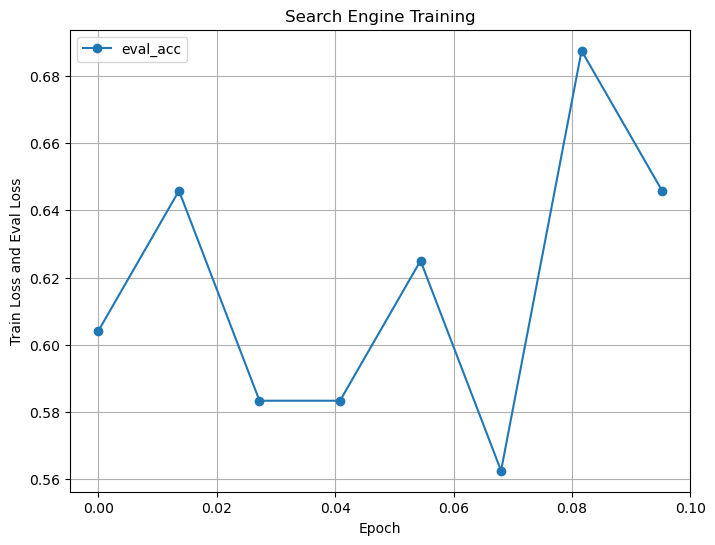

In [7]:
exp_dir = "exp11"
param_save_path = "model2"
last_check_point = "checkpoint-140"
#train_data_path = f"{exp_dir}/{param_save_path}/{last_check_point}/trainer_state.json"
train_data_path = f"{param_save_path}/{last_check_point}/trainer_state.json"

import json
with open(train_data_path) as f:
    train_data = json.load(f)
    log_hist = train_data["log_history"]

train_epoch = []
eval_epoch = []
train_loss = []
eval_loss = []
eval_acc = []
for i, log_hist_data in enumerate(log_hist):
    if "eval_loss" in log_hist_data:
        eval_epoch.append(log_hist_data["epoch"])
        eval_loss.append(log_hist_data["eval_loss"])
        eval_acc.append(log_hist_data["eval_accuracy"])
    else:
        train_epoch.append(log_hist_data["epoch"])
        train_loss.append(log_hist_data["loss"])

import matplotlib.pyplot as plt
# Create a new figure with a specific size
plt.figure(figsize=(8, 6))

# Plot each set of values with markers and labels
plt.plot(eval_epoch, eval_acc, marker='o', label='eval_acc')
#plt.plot(eval_epoch, eval_loss, marker='s', label='eval_loss')
#plt.plot(eval_epoch, eval_acc, marker='^', label='eval_acc')

# Add labels and title
plt.xlabel('Epoch')
plt.ylabel('Train Loss and Eval Loss')
plt.title('Search Engine Training')

# Enable the legend and grid
plt.legend()
plt.grid(True)

# Display the plot
plt.show()



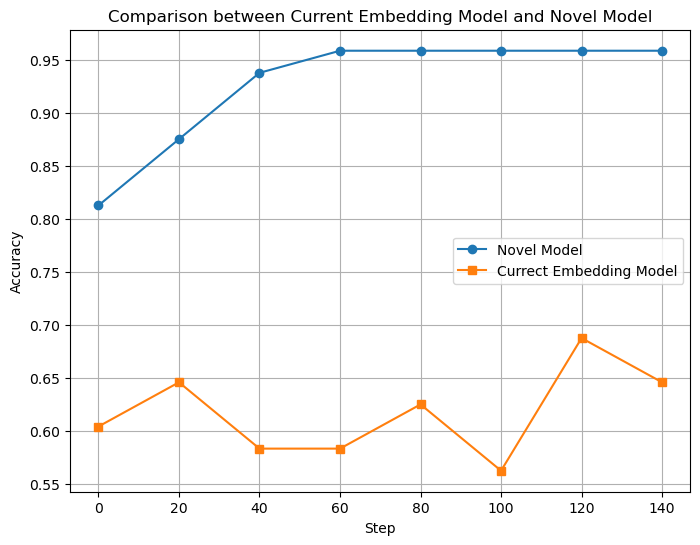

In [25]:
# Comparison from exp dir

exp_dir = "exp11"
param_save_path = "model1"
last_check_point = "checkpoint-140"
#train_data_path = f"{exp_dir}/{param_save_path}/{last_check_point}/trainer_state.json"
train_data_path = f"{param_save_path}/{last_check_point}/trainer_state.json"

import json
with open(train_data_path) as f:
    train_data = json.load(f)
    log_hist = train_data["log_history"]

train_steps = []
eval_steps = []
train_epoch = []
eval_epoch = []
train_loss = []
eval_loss = []
eval_acc = []
for i, log_hist_data in enumerate(log_hist):
    if "eval_loss" in log_hist_data:
        eval_steps.append(log_hist_data["step"])
        eval_epoch.append(log_hist_data["epoch"])
        eval_loss.append(log_hist_data["eval_loss"])
        eval_acc.append(log_hist_data["eval_accuracy"])
    else:
        train_steps.append(log_hist_data["step"])
        train_epoch.append(log_hist_data["epoch"])
        train_loss.append(log_hist_data["loss"])


exp_dir = "exp11"
param_save_path = "model2"
last_check_point = "checkpoint-140"
#train_data_path = f"{exp_dir}/{param_save_path}/{last_check_point}/trainer_state.json"
train_data_path = f"{param_save_path}/{last_check_point}/trainer_state.json"

import json
with open(train_data_path) as f:
    train_data = json.load(f)
    log_hist = train_data["log_history"]

train_steps2 = []
eval_steps2 = []
train_epoch2 = []
eval_epoch2 = []
train_loss2 = []
eval_loss2 = []
eval_acc2 = []
for i, log_hist_data in enumerate(log_hist):
    if "eval_loss" in log_hist_data:
        eval_steps2.append(log_hist_data["step"])
        eval_epoch2.append(log_hist_data["epoch"])
        eval_loss2.append(log_hist_data["eval_loss"])
        eval_acc2.append(log_hist_data["eval_accuracy"])
    else:
        train_steps2.append(log_hist_data["step"])
        train_epoch2.append(log_hist_data["epoch"])
        train_loss2.append(log_hist_data["loss"])



import matplotlib.pyplot as plt
# Create a new figure with a specific size
plt.figure(figsize=(8, 6))

# Plot each set of values with markers and labels
plt.plot(eval_steps, eval_acc, marker='o', label='Novel Model')
plt.plot(eval_steps2, eval_acc2, marker='s', label='Currect Embedding Model')
#plt.plot(eval_epoch, eval_acc, marker='^', label='eval_acc')

# Add labels and title
plt.xlabel('Step')
plt.ylabel('Accuracy')
plt.title('Comparison between Current Embedding Model and Novel Model')

# Enable the legend and grid
plt.legend()
plt.grid(True)

# Display the plot
plt.show()

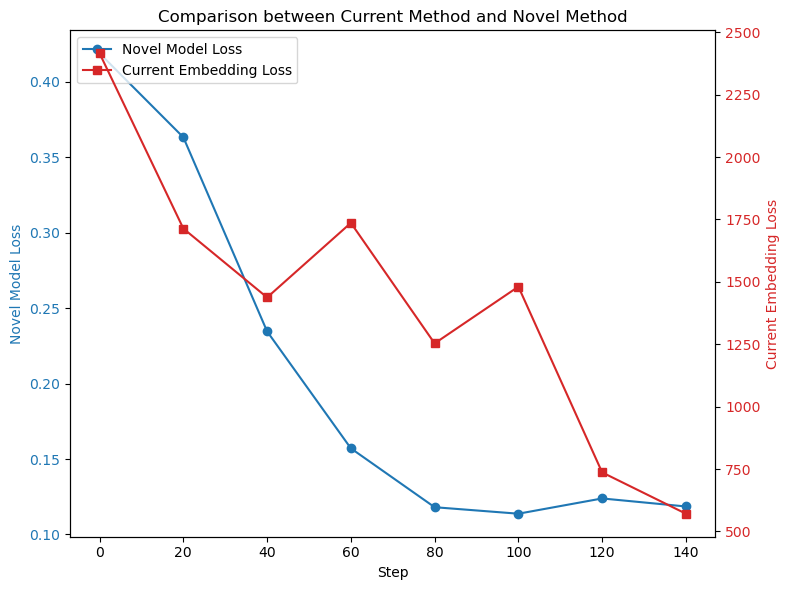

In [21]:
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(8, 6))

# Plot the first loss curve on the left y-axis
color1 = 'tab:blue'
ax1.plot(eval_steps, eval_loss, marker='o', color=color1, label='Novel Model Loss')
ax1.set_xlabel('Step')
ax1.set_ylabel('Novel Model Loss', color=color1)
ax1.tick_params(axis='y', labelcolor=color1)

# Create a second y-axis sharing the same x-axis
ax2 = ax1.twinx()
color2 = 'tab:red'
ax2.plot(eval_steps2, eval_loss2, marker='s', color=color2, label='Current Embedding Loss')
ax2.set_ylabel('Current Embedding Loss', color=color2)
ax2.tick_params(axis='y', labelcolor=color2)

# Optionally, combine the legends from both axes
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.title('Comparison between Current Method and Novel Method')
plt.tight_layout()  # Ensures labels don't overlap
plt.show()


In [ ]:
# Comparison with Manually Made Datapoints

old_step = list(range(5, 85, 5))
new_step = list(range(0, 380, 20))
old_acc = [0.807,0.820, 0.826,0.833,0.846,0.852,0.858,0.865,0.871,0.865,0.865,0.865,0.871,0.871,0.871,0.871]
new_acc = [0.848,0.871,0.914,0.944,0.956,0.968,0.973,0.979,0.980,0.984,0.984,0.984,0.984,0.989,0.989,0.987,0.986,0.984,0.986]

import matplotlib.pyplot as plt
# Create a new figure with a specific size
plt.figure(figsize=(8, 6))

# Plot each set of values with markers and labels
plt.plot(old_step, old_acc, marker='o', label='Currect Method')
plt.plot(new_step, new_acc, marker='s', label='Novel Method')
#plt.plot(eval_epoch, eval_acc, marker='^', label='eval_acc')

# Add labels and title
plt.xlabel('Step')
plt.ylabel('Accuracy with Current Method and Novel Method')
plt.title('Comparison between Current Method and Novel Method')

# Enable the legend and grid
plt.legend()
plt.grid(True)

# Display the plot
plt.show()



In [ ]:
exp_dir = "exp8"
param_save_path = "model1"
last_check_point = "step120"
eval_data_path = f"{exp_dir}-{param_save_path}-{last_check_point}-eval/eval_result.json"
log_path = "code-log5-corr1.json"

import json
with open(eval_data_path) as f:
    eval_result = json.load(f)
    generation_acc = eval_result["generation_acc"]

with open(log_path) as f:
    log = json.load(f)
    original_acc = log["Pass@1"]

new_acc = original_acc+(1-original_acc)*generation_acc

import matplotlib.pyplot as plt

# Sample data
categories = ['Normal', 'With Our Search Engine']
colors = ['blue', 'red']

values = [original_acc*100, new_acc*100]
print(values)
print()
print()
#generation_acc = 0.2916666666666667

# Create a bar graph with different colors for each bar
plt.bar(categories, values, color=colors)

# Set the range of the y-axis
plt.ylim(0, 100)

# Add labels and title
#plt.xlabel('Categories')
plt.ylabel('Accuracy in "bigcodebench/Deepseek-r1" (%)')
plt.title('Improvement By Proprietary Search Engine')

# Show the plot
plt.show()


## Checkpoint -> Lora Model -> Generate Model

In [ ]:
!pip install -U transformers
!pip install -U peft

In [ ]:
base_model_name = "llama3b-rm"
checkpoint_path = "exp8/model1/checkpoint-120"
save_dir = "exp8-model1-step120"
score_save_path = f"{save_dir}-score.pt"  # default

from transformers import AutoModelForSequenceClassification,AutoTokenizer,TrainingArguments,AutoConfig,AutoModelForCausalLM
from peft import PeftModel, PeftConfig

tokenizer = AutoTokenizer.from_pretrained(base_model_name, padding_side="left",add_eos_token=False,add_bos_token=False)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
    config.pad_token_id = config.eos_token_id

# Load the pre-trained model without the LM head.
# AutoModelForCausalLM usually refers to models with the LM head included, so you'd typically use a more specific base model class.
#base_model = AutoModelForCausalLM.from_config(config).base_model
model = AutoModelForSequenceClassification.from_pretrained(base_model_name, num_labels=1)

lora_model = PeftModel.from_pretrained(model, checkpoint_path)

merged_model = lora_model.merge_and_unload()

merged_model

import torch
torch.save(merged_model.score.weight.data, score_save_path)
tokenizer.save_pretrained(save_dir)
merged_model.save_pretrained(save_dir)

# Convert Classification class into Causal class(because LlamaClassification class is not supported by vllm yet)
from transformers import AutoTokenizer, AutoModelForSequenceClassification, AutoModelForCausalLM
merged_generate_model = AutoModelForCausalLM.from_pretrained(save_dir)
merged_generate_model.save_pretrained(save_dir)
print("Successfully Saved Model")

### test

In [ ]:
base_model_name = "llama3b-rm"
checkpoint_path = "exp7/model1/checkpoint-140"
save_dir = "exp7-model1-step140"
score_save_path = f"{save_dir}-score.pt"  # default

from transformers import AutoModelForSequenceClassification,AutoTokenizer,TrainingArguments,AutoConfig,AutoModelForCausalLM
from peft import PeftModel, PeftConfig

tokenizer = AutoTokenizer.from_pretrained(base_model_name, padding_side="left",add_eos_token=True,add_bos_token=True)
#tokenizer = AutoTokenizer.from_pretrained(base_model_name, padding_side="left",add_eos_token=False,add_bos_token=False)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
    config.pad_token_id = config.eos_token_id

# Load the pre-trained model without the LM head.
# AutoModelForCausalLM usually refers to models with the LM head included, so you'd typically use a more specific base model class.
#base_model = AutoModelForCausalLM.from_config(config).base_model
model = AutoModelForSequenceClassification.from_pretrained(base_model_name, num_labels=1)

lora_model = PeftModel.from_pretrained(model, checkpoint_path)

merged_model = lora_model.merge_and_unload()

merged_model

In [ ]:
merged_model.score.weight.data

In [ ]:
#prompt="Hello, my name is"

message = [
  {'role': 'user', 'content': f"Give me an advice to the problem and answer below;\n\nProblem:\n\nAnswer:"},
  {'role': 'assistant', 'content': f"Advice"}
]
prompt = tokenizer.apply_chat_template(message, tokenize=False)

inputs = tokenizer(prompt, return_tensors="pt", add_special_tokens=False)
outputs = merged_model(**inputs, output_hidden_states=True)

In [ ]:
prompt[17:]

In [ ]:
print(tokenizer.decode(inputs["input_ids"][0], skip_special_tokens=False))
print(outputs.logits)
print(outputs.hidden_states[-1][0][-1])

In [ ]:
tokenizer = AutoTokenizer.from_pretrained(base_model_name, padding_side="left",add_eos_token=False,add_bos_token=False)
print(tokenizer.decode(inputs["input_ids"][0]))
#print(outputs)
print(outputs.hidden_states[-1][0][-1])

In [ ]:
print(tokenizer.decode(inputs["input_ids"][0]))
print(outputs)

In [ ]:
from vllm import LLM, SamplingParams
class pooler_config:
    def __init__(self):
        self.pooling_type = "LAST"
        self.normalize = False
        self.softmax = False
        self.softmax = False
        self.step_tag_id = None
        self.returned_token_ids = None

base_model_name = "llama3b-rm"
checkpoint_path = "exp7/model1/checkpoint-140"
save_dir = "exp7-model1-step140"
score_save_path = f"{save_dir}-score.pt"  # default

from transformers import AutoModelForSequenceClassification,AutoTokenizer,TrainingArguments,AutoConfig,AutoModelForCausalLM

tokenizer = AutoTokenizer.from_pretrained(base_model_name, padding_side="left",add_eos_token=True,add_bos_token=True)
#tokenizer = AutoTokenizer.from_pretrained(base_model_name, padding_side="left",add_eos_token=False,add_bos_token=False)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
    config.pad_token_id = config.eos_token_id

message = [
  {'role': 'user', 'content': f"Give me an advice to the problem and answer below;\n\nProblem:\n\nAnswer:"},
  {'role': 'assistant', 'content': f"Advice"}
]
prompt = tokenizer.apply_chat_template(message, tokenize=False)

pooler_config_ = pooler_config()
model_name = "exp7-model1-step140"
#sampling_params = SamplingParams(skip_special_tokens=False)
llm = LLM(model=model_name,
          dtype="float32",
           tensor_parallel_size=1,
           task="embed",
           override_pooler_config=pooler_config_,)

#prompt="Hello, my name is"

outputs = llm.embed([prompt])


In [ ]:
from vllm import LLM, SamplingParams
class pooler_config:
    def __init__(self):
        self.pooling_type = "LAST"
        self.normalize = False
        self.softmax = False
        self.softmax = False
        self.step_tag_id = None
        self.returned_token_ids = None

base_model_name = "llama3b-rm"
checkpoint_path = "exp7/model1/checkpoint-140"
save_dir = "exp7-model1-step140"
score_save_path = f"{save_dir}-score.pt"  # default

from transformers import AutoModelForSequenceClassification,AutoTokenizer,TrainingArguments,AutoConfig,AutoModelForCausalLM

tokenizer = AutoTokenizer.from_pretrained(base_model_name, padding_side="left",add_eos_token=True,add_bos_token=True)
#tokenizer = AutoTokenizer.from_pretrained(base_model_name, padding_side="left",add_eos_token=False,add_bos_token=False)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
    config.pad_token_id = config.eos_token_id

message = [
  {'role': 'user', 'content': f"Give me an advice to the problem and answer below;\n\nProblem:\n\nAnswer:"},
  {'role': 'assistant', 'content': f"Advice"}
]
prompt = tokenizer.apply_chat_template(message, tokenize=False)

pooler_config_ = pooler_config()
model_name = "exp7-model1-step140"
#sampling_params = SamplingParams(skip_special_tokens=False)
pooling_params = PoolingParams(skip_special_tokens=False)
llm = LLM(model=model_name,
          dtype="float32",
           tensor_parallel_size=1,
           task="encode",
           override_pooler_config=pooler_config_,)

#prompt="Hello, my name is"

outputs = llm.encode([prompt], )


#"float16"
import torch
save_dir = "exp7-model1-step140"
score_save_path = f"{save_dir}-score.pt"  # default
score = torch.load(score_save_path)
print(torch.tensor(outputs[0].outputs.embedding))
reward = torch.matmul(torch.tensor(outputs[0].outputs.embedding), score.transpose(0,1))
reward

In [ ]:
#"float32"
import torch
save_dir = "exp7-model1-step140"
score_save_path = f"{save_dir}-score.pt"  # default
score = torch.load(score_save_path)
print(torch.tensor(outputs[0].outputs.embedding))
reward = torch.matmul(torch.tensor(outputs[0].outputs.embedding), score.transpose(0,1))
reward

In [ ]:
#"bfloat16"
import torch
save_dir = "exp7-model1-step140"
score_save_path = f"{save_dir}-score.pt"  # default
score = torch.load(score_save_path)
print(torch.tensor(outputs[0].outputs.embedding))
reward = torch.matmul(torch.tensor(outputs[0].outputs.embedding), score.transpose(0,1))
reward

In [ ]:
#"float32"
#outputs = llm.embed([prompt[17:]])
outputs = llm.embed([prompt])

import torch
save_dir = "exp7-model1-step140"
score_save_path = f"{save_dir}-score.pt"  # default
score = torch.load(score_save_path)
print(torch.tensor(outputs[0].outputs.embedding))
#outputs #print(tokenizer.decode([128000, 128000, 128006, 9125, 128007, 271, 38766, 1303, 33025, 2696, 25, 6790, 220, 2366, 18, 198, 15724, 2696, 25, 220, 1591, 13806, 220, 2366, 20, 271, 128009, 128006, 882, 128007, 271, 36227, 757, 459, 9650, 311, 279, 3575, 323, 4320, 3770, 401, 32298, 1473, 16533, 25, 128009, 128006, 78191, 128007, 271, 80039, 128009], skip_special_tokens=False))
reward = torch.matmul(torch.tensor(outputs[0].outputs.embedding), score.transpose(0,1))
reward

## Evaluate

In [ ]:
!pip install datasets
!pip install transformers
#!pip install accelerate
!pip install numpy, pandas, polars
!pip install matplotlib
!pip install sentence_transformers
#!pip install huggingface_hub
!pip install evaluate
#!pip install mistralai
#!pip install flask

# For vLLM
!pip install vllm  #==0.6.5
!pip install ray
!pip install packaging
!pip install typing
!pip install -U typing_extensions==4.11.0
!pip install pyarrow

### Delete Overlapping Advices

In [ ]:
exp_dir = "exp8"
model_name = "exp8-model1-step120"
exp_eval_dir = f"{model_name}-eval"
import os
if not os.path.exists(exp_eval_dir): os.makedirs(exp_eval_dir)

data_load_path = "bigcodebench3.json"
advice_load_path = "code-log5-corr1.json"
dataset_load_path = f"{exp_dir}/dataset"

result_save_path = f"{exp_eval_dir}/overlapping_advice_data.json"
train_data_dict_save_path = f"{exp_eval_dir}/train_data_dict.json"
test_data_dict_save_path = f"{exp_eval_dir}/test_data_dict.json"
#train_relevance_save_path = f"{exp_eval_dir}/train_relevance.pt"  # relevance between test_problem and train_advice
#test_relevance_save_path = f"{exp_eval_dir}/test_relevance.pt"  # relevance between test_problem and test_advice
test_problem_and_answer_save_path = f"{exp_eval_dir}/test_problem_and_answer.json"


In [ ]:
import random
import pandas as pd
from operator import itemgetter
import torch
import torch.nn as nn
#from transformers import AutoModelForSequenceClassification,AutoTokenizer,TrainingArguments,AutoConfig,AutoModelForCausalLM
import time

import json
with open(data_load_path) as f:
    data_dict = json.load(f)

task_id=data_dict["task_id"]
complete_prompt=data_dict["complete_prompt"]
instruct_prompt=data_dict["instruct_prompt"]
canonical_solution=data_dict["canonical_solution"]
code_prompt=data_dict["code_prompt"]
test=data_dict["test"]
doc_struct=data_dict["doc_struct"]
num_problems = len(task_id)

with open(advice_load_path) as f:
    log = json.load(f)

from datasets import load_from_disk
formatted_dataset = load_from_disk(dataset_load_path)
train_problem_ids = formatted_dataset["train"]["problem_id"]
test_problem_ids = formatted_dataset["test"]["problem_id"]

data_dict = {"problem_id":[], "problem":[], "advice":[], "advice_id":[], "output":[], "correct":[], "log_ids":[], "node_state":[]}

def search_log(log_dict, log_ids):  # node_id: str
    global data_dict
    node_id = log_ids[-1]

    if type(log_dict[node_id]) != dict:
        return None
        
    if "children" in log_dict[node_id]:
        for next_node_id in log_dict[node_id]["children"]:
            problem_id_str = log_ids[0]
            problem_id = int(problem_id_str)
            problem = instruct_prompt[problem_id]
            advice_list = log_dict[node_id]["children"][next_node_id]["instruction_list"]

            if "corrects" in log_dict[node_id]["children"][next_node_id]:  # when quiting the inference after finihing creating advice
                all_correct = True
                all_incorrect = True
                child_num_correct = 0
                child_num_problem = 0
                for advice_id, advice in enumerate(advice_list):
                    correct = log_dict[node_id]["children"][next_node_id]["corrects"][str(advice_id)]
                    child_num_problem += 1
                    if correct:
                        all_incorrect = False
                        child_num_correct += 1
                    else:
                        all_correct = False

                if child_num_problem == 0: continue

                for advice_id, advice in enumerate(advice_list):
                    correct = log_dict[node_id]["children"][next_node_id]["corrects"][str(advice_id)]
                    output = log_dict[node_id]["children"][next_node_id]["outputs"][str(advice_id)]
                    data_dict["problem_id"].append(problem_id)
                    data_dict["problem"].append(problem)
                    data_dict["output"].append(output)
                    data_dict["advice"].append(advice)
                    data_dict["advice_id"].append(advice_id)
                    data_dict["correct"].append(correct)
                    data_dict["log_ids"].append(log_ids+[next_node_id])
                    data_dict["node_state"].append({"num_problem":len(advice_list), "child_num_correct":child_num_correct, "all_correct":all_correct, "all_incorrect":all_incorrect})

                if all_incorrect:
                    search_log(log_dict[node_id]["children"], log_ids + [next_node_id])


problem_ids_with_advice = []
for problem_id_str in log:
    if problem_id_str.isdigit():
        if int(problem_id_str) in train_problem_ids:
            if "children" in log[problem_id_str]:
                problem_ids_with_advice.append(int(problem_id_str))
                search_log(log, [problem_id_str])

#advices = data_dict["advice"] # this includes only train advice
with open(train_data_dict_save_path, "w") as f:
    json.dump(data_dict, f)


data_dict = {"problem_id":[], "problem":[], "advice":[], "advice_id":[], "output":[], "correct":[], "log_ids":[], "node_state":[]}

problem_ids_with_advice = []
for problem_id_str in log:
    if problem_id_str.isdigit():
        if int(problem_id_str) in test_problem_ids:
            if "children" in log[problem_id_str]:
                problem_ids_with_advice.append(int(problem_id_str))
                search_log(log, [problem_id_str])
                
#advices = data_dict["advice"] # this includes only train advice
with open(test_data_dict_save_path, "w") as f:
    json.dump(data_dict, f)
    

import time
import torch
problems = []
answers = []
new_problem_ids = []
for new_problem_id, problem_id in enumerate(test_problem_ids):
    new_problem_ids.append(new_problem_id)
    problem = instruct_prompt[problem_id]
    problems.append(problem)
    answer = log[str(problem_id)]["outputs"]["0"]
    answers.append(answer)

with open(test_problem_and_answer_save_path, "w") as f:
    json.dump({"problems":problems, "answers":answers}, f)

In [ ]:
import json

if not os.path.exists(f"{exp_eval_dir}/advice_similarities.pt"):
    
    with open(train_data_dict_save_path) as f:
        train_data_dict = json.load(f)

    advices = train_data_dict["advice"]
    
    # Get similarities between advice so that avoid rejected advice being important for the problems
    from sentence_transformers import SentenceTransformer
    from sentence_transformers.util import cos_sim
    from sentence_transformers.quantization import quantize_embeddings
    
    # 1. Specify preffered dimensions
    dimensions = 512

    print("Model Loading...")
    # 2. load model
    model = SentenceTransformer("mixedbread-ai/mxbai-embed-large-v1", truncate_dim=dimensions).to("cuda")
    # The prompt used for query retrieval tasks:
    # query_prompt = 'Represent this sentence for searching relevant passages: '
    
    print("Encoding...")
    # 2. Encode
    query_embedding = model.encode(advices, prompt_name="query")
    # Equivalent Alternatives:
    # query_embedding = model.encode(query_prompt + query)
    # query_embedding = model.encode(query, prompt=query_prompt)
    
    docs_embeddings = model.encode(advices)

    print("Tensorizing...")
    # Optional: Quantize the embeddings
    binary_query_embedding = quantize_embeddings(query_embedding, precision="ubinary")
    binary_query_embedding = torch.tensor(binary_query_embedding).to("cuda")
    binary_docs_embeddings = quantize_embeddings(docs_embeddings, precision="ubinary")
    binary_docs_embeddings = torch.tensor(binary_docs_embeddings).to("cuda")
    
    print("Calculateing Similarities")
    advice_similarities = cos_sim(query_embedding, docs_embeddings)
    torch.save(advice_similarities, f"{exp_eval_dir}/advice_similarities.pt")

    print("Finished Saving")
    
else:
    advice_similarities = torch.load(f"{exp_eval_dir}/advice_similarities.pt")
    
    with open(train_data_dict_save_path) as f:
        train_data_dict = json.load(f)

    advices = train_data_dict["advice"]


In [ ]:
import torch

def remove_similar_sentences_optimized(relevance_matrix: torch.Tensor, sentences: list, threshold: float = 0.85):
    """
    Efficiently remove sentences that are too similar based on a precomputed relevance matrix.
    
    This function assumes that if sentence i (with i < j) is accepted and the similarity 
    between sentence i and sentence j exceeds the threshold, then sentence j is removed.
    It uses torch.nonzero to find candidate pairs and loops only over unique candidate j's.
    
    Additionally, the function returns two mappings:
        - similar_mapping_r2a: Mapping from each removed sentence index (r) to the list of accepted 
          sentence indices (a) that are similar.
        - similar_mapping_a2r: Mapping from each accepted sentence index (a) to the list of removed 
          sentence indices (r) that were removed because of similarity.
    
    Args:
        relevance_matrix (torch.Tensor): A square tensor of pairwise relevance scores.
        sentences (list of str): List of sentence strings.
        threshold (float): Similarity threshold above which a sentence is considered too similar.
    
    Returns:
        removed_ids (list of int): Indices of sentences that were removed.
        similar_mapping_r2a (dict): Mapping removed sentence index -> list of accepted similar sentence indices.
        similar_mapping_a2r (dict): Mapping accepted sentence index -> list of removed sentence indices.
    """
    num_sentences = len(sentences)
    # Boolean mask for accepted sentences: True means accepted, False means removed.
    accepted_mask = torch.ones(num_sentences, dtype=torch.bool, device=relevance_matrix.device)
    removed_ids = []
    similar_mapping_r2a = {}  # Mapping: removed sentence index -> accepted sentence indices
    similar_mapping_a2r = {}  # Mapping: accepted sentence index -> removed sentence indices

    # Get candidate pairs (i, j) with i < j and similarity >= threshold.
    candidate_pairs = torch.nonzero(torch.triu(relevance_matrix, diagonal=1) >= threshold, as_tuple=False)
    
    if candidate_pairs.numel() == 0:
        return [], {}, {}

    # Sort candidate pairs by j (the later sentence index).
    candidate_pairs = candidate_pairs[candidate_pairs[:, 1].argsort()]

    # Get unique candidate j's (the ones that might be removed).
    unique_j = torch.unique(candidate_pairs[:, 1])
    
    # Loop only over the candidate j's
    for j in unique_j.tolist():
        # Get all candidate pairs where the second column is j.
        rows = candidate_pairs[candidate_pairs[:, 1] == j]
        # Extract corresponding i indices.
        candidate_is = rows[:, 0]
        # Consider only those i that are still accepted.
        accepted_is = candidate_is[accepted_mask[candidate_is]]
        if accepted_is.numel() > 0:
            # Mark sentence j as removed since it is too similar to one or more accepted sentences.
            accepted_mask[j] = False
            removed_ids.append(j)
            similar_mapping_r2a[j] = accepted_is.tolist()
            # For each accepted sentence that is similar, record that j was removed.
            for acc_id in accepted_is.tolist():
                if acc_id in similar_mapping_a2r:
                    similar_mapping_a2r[acc_id].append(j)
                else:
                    similar_mapping_a2r[acc_id] = [j]
    
    return removed_ids, similar_mapping_r2a, similar_mapping_a2r

'''
# Example usage:
if __name__ == "__main__":
    sentences = [
        "The quick brown fox jumps over the lazy dog.",
        "A quick brown fox jumps over a lazy dog.",
        "Lorem ipsum dolor sit amet, consectetur adipiscing elit.",
        "Consectetur adipiscing elit, sed do eiusmod tempor incididunt ut labore."
    ]
    
    # Example relevance matrix as a torch.Tensor (symmetric, with 1.0 on the diagonal)
    relevance_matrix = torch.tensor([
        [1.0, 0.90, 0.2, 0.1],
        [0.90, 1.0, 0.3, 0.2],
        [0.2, 0.3, 1.0, 0.8],
        [0.1, 0.2, 0.8, 1.0]
    ])
'''

removed_ids, sim_r2a, sim_a2r = remove_similar_sentences_optimized(advice_similarities, advices, threshold=0.8)

print(f"N removed senteces: {len(removed_ids)} / {len(advices)}")
#print("Removed sentence indices:", removed_ids)
print()
print("Mapping of removed sentences to similar accepted sentences:")
print()
for rem_id, sim_ids in sim_r2a.items():
    print(f"rem_id {rem_id}, sim_ids {sim_ids}")
    print(f"Removed Sentence: {advices[rem_id]}")
    for sim_id in sim_ids:
        print(f"Similar Accepted Sentence: {advices[sim_id]}")
    print()

print()
for acc_id, rem_ids in sim_a2r.items():
    print(f"acc_id {acc_id}, rem_ids {rem_ids}")
    print(f"Accept Sentence: {advices[acc_id]}")
    for rem_id in rem_ids:
        print(f"Similar Removed Sentence: {advices[rem_id]}")
    print()

'''
print("Mapping of removed sentences to similar accepted sentences (r2a):")
for rem_id, sim_ids in sim_r2a.items():
    print(f"Sentence {rem_id} is similar to accepted sentences with indices: {sim_ids}")

print()
print()
print("\nMapping of accepted sentences to removed sentences (a2r):")
for acc_id, rem_ids in sim_a2r.items():
    print(f"Sentence {acc_id} has removed similar sentences with indices: {rem_ids}")

'''


In [ ]:
import json

accepted_ids = list(set(range(len(advices))) - set(removed_ids))
with open(result_save_path, "w") as f:
    json.dump({"accepted_ids":accepted_ids, "removed_ids":removed_ids, "sim_r2a":sim_r2a, "sim_a2r":sim_a2r}, f)


In [ ]:
len(accepted_ids), len(removed_ids), len(advices)

### Get Relevance

In [ ]:
exp_dir = "exp8"
model_name = "exp8-model1-step120"
#model_name = "llama3b-generate"
exp_eval_dir = f"{model_name}-eval"
import os
if not os.path.exists(exp_eval_dir): os.makedirs(exp_eval_dir)

data_load_path = "bigcodebench3.json"
advice_load_path = "code-log5-corr1.json"
dataset_load_path = f"{exp_dir}/dataset"
#overlapping_advice_data_load_path = None
overlapping_advice_data_load_path = f"{exp_eval_dir}/overlapping_advice_data.json"

train_data_dict_save_path = f"{exp_eval_dir}/train_data_dict.json"
test_data_dict_save_path = f"{exp_eval_dir}/test_data_dict.json"
train_relevance_save_path = f"{exp_eval_dir}/train_relevance.pt"  # relevance between test_problem and train_advice
test_relevance_save_path = f"{exp_eval_dir}/test_relevance.pt"  # relevance between test_problem and test_advice
test_problem_and_answer_save_path = f"{exp_eval_dir}/test_problem_and_answer.json"

#num_retrival = 30
tensor_parallel_size = 1
num_instances = 4

#model_name = "Ray2333/GRM-Llama3.2-3B-rewardmodel-ft"
score_path = f"{model_name}-score.pt"  # Default
#score_path = f"llama3b_rm_head.pt"

In [ ]:
import random
import pandas as pd
from operator import itemgetter
import torch
import torch.nn as nn
#from transformers import AutoModelForSequenceClassification,AutoTokenizer,TrainingArguments,AutoConfig,AutoModelForCausalLM
import time

import json
with open(data_load_path) as f:
    data_dict = json.load(f)

task_id=data_dict["task_id"]
complete_prompt=data_dict["complete_prompt"]
instruct_prompt=data_dict["instruct_prompt"]
canonical_solution=data_dict["canonical_solution"]
code_prompt=data_dict["code_prompt"]
test=data_dict["test"]
doc_struct=data_dict["doc_struct"]
num_problems = len(task_id)

with open(advice_load_path) as f:
    log = json.load(f)

from datasets import load_from_disk
formatted_dataset = load_from_disk(dataset_load_path)
train_problem_ids = formatted_dataset["train"]["problem_id"]
test_problem_ids = formatted_dataset["test"]["problem_id"]

data_dict = {"problem_id":[], "problem":[], "advice":[], "advice_id":[], "output":[], "correct":[], "log_ids":[], "node_state":[]}

def search_log(log_dict, log_ids):  # node_id: str
    global data_dict
    node_id = log_ids[-1]

    if type(log_dict[node_id]) != dict:
        return None
        
    if "children" in log_dict[node_id]:
        for next_node_id in log_dict[node_id]["children"]:
            problem_id_str = log_ids[0]
            problem_id = int(problem_id_str)
            problem = instruct_prompt[problem_id]
            advice_list = log_dict[node_id]["children"][next_node_id]["instruction_list"]

            if "corrects" in log_dict[node_id]["children"][next_node_id]:  # when quiting the inference after finihing creating advice
                all_correct = True
                all_incorrect = True
                child_num_correct = 0
                child_num_problem = 0
                for advice_id, advice in enumerate(advice_list):
                    correct = log_dict[node_id]["children"][next_node_id]["corrects"][str(advice_id)]
                    child_num_problem += 1
                    if correct:
                        all_incorrect = False
                        child_num_correct += 1
                    else:
                        all_correct = False

                if child_num_problem == 0: continue

                for advice_id, advice in enumerate(advice_list):
                    correct = log_dict[node_id]["children"][next_node_id]["corrects"][str(advice_id)]
                    output = log_dict[node_id]["children"][next_node_id]["outputs"][str(advice_id)]
                    data_dict["problem_id"].append(problem_id)
                    data_dict["problem"].append(problem)
                    data_dict["output"].append(output)
                    data_dict["advice"].append(advice)
                    data_dict["advice_id"].append(advice_id)
                    data_dict["correct"].append(correct)
                    data_dict["log_ids"].append(log_ids+[next_node_id])
                    data_dict["node_state"].append({"num_problem":len(advice_list), "child_num_correct":child_num_correct, "all_correct":all_correct, "all_incorrect":all_incorrect})

                if all_incorrect:
                    search_log(log_dict[node_id]["children"], log_ids + [next_node_id])


problem_ids_with_advice = []
for problem_id_str in log:
    if problem_id_str.isdigit():
        if int(problem_id_str) in train_problem_ids:
            if "children" in log[problem_id_str]:
                problem_ids_with_advice.append(int(problem_id_str))
                search_log(log, [problem_id_str])

#advices = data_dict["advice"] # this includes only train advice
with open(train_data_dict_save_path, "w") as f:
    json.dump(data_dict, f)


data_dict = {"problem_id":[], "problem":[], "advice":[], "advice_id":[], "output":[], "correct":[], "log_ids":[], "node_state":[]}

problem_ids_with_advice = []
for problem_id_str in log:
    if problem_id_str.isdigit():
        if int(problem_id_str) in test_problem_ids:
            if "children" in log[problem_id_str]:
                problem_ids_with_advice.append(int(problem_id_str))
                search_log(log, [problem_id_str])
                
#advices = data_dict["advice"] # this includes only train advice
with open(test_data_dict_save_path, "w") as f:
    json.dump(data_dict, f)
    

import time
import torch

problems = []
answers = []
new_problem_ids = []
for new_problem_id, problem_id in enumerate(test_problem_ids):
    new_problem_ids.append(new_problem_id)
    problem = instruct_prompt[problem_id]
    problems.append(problem)
    answer = log[str(problem_id)]["outputs"]["0"]
    answers.append(answer)

with open(test_problem_and_answer_save_path, "w") as f:
    json.dump({"problems":problems, "answers":answers}, f)

In [ ]:
from typing import Any, Dict, List
import numpy as np
import ray
from packaging.version import Version
from ray.util.scheduling_strategies import PlacementGroupSchedulingStrategy
from vllm import LLM, SamplingParams
assert Version(ray.__version__) >= Version(
    "2.22.0"), "Ray version must be at least 2.22.0"
from transformers import AutoTokenizer, AutoModelForSequenceClassification, AutoModelForCausalLM

class pooler_config:
    def __init__(self):
        self.pooling_type = "LAST"
        self.normalize = False
        self.softmax = False
        self.softmax = False
        self.step_tag_id = None
        self.returned_token_ids = None

pooler_config_ = pooler_config()

tokenizer = AutoTokenizer.from_pretrained(model_name, padding_side="left",add_eos_token=True,add_bos_token=True)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
    config.pad_token_id = config.eos_token_id


# Create a class to do batch inference.
class LLMPredictor:

    def __init__(self):
        # Create an LLM.
        self.llm = LLM(model=model_name,
                       dtype="bfloat16",
                       #dtype="float32",
                       tensor_parallel_size=tensor_parallel_size,
                       task="embed",
                       override_pooler_config=pooler_config_,)

    def __call__(self, batch: Dict[str, np.ndarray]) -> Dict[str, list]:
        outputs = self.llm.embed(batch["prompt"])

        embeddings = []
        for output in outputs:
            embeddings.append(output.outputs.embedding)
            #generated_text.append(' '.join([o.text for o in output.outputs]))

        return {
            "embeddings": embeddings
        }


# Read one text file from S3. Ray Data supports reading multiple files
# from cloud storage (such as JSONL, Parquet, CSV, binary format).
#ds = ray.data.read_text("s3://anonymous@air-example-data/prompts.txt")

# For tensor_parallel_size > 1, we need to create placement groups for vLLM
# to use. Every actor has to have its own placement group.
def scheduling_strategy_fn():
    # One bundle per tensor parallel worker
    pg = ray.util.placement_group(
        [{
            "GPU": 1,
            "CPU": 1
        }] * tensor_parallel_size,
        strategy="STRICT_PACK",
    )
    return dict(scheduling_strategy=PlacementGroupSchedulingStrategy(
        pg, placement_group_capture_child_tasks=True))


resources_kwarg: Dict[str, Any] = {}
if tensor_parallel_size == 1:
    # For tensor_parallel_size == 1, we simply set num_gpus=1.
    resources_kwarg["num_gpus"] = 1
else:
    # Otherwise, we have to set num_gpus=0 and provide
    # a function that will create a placement group for
    # each instance.
    resources_kwarg["num_gpus"] = 0
    resources_kwarg["ray_remote_args_fn"] = scheduling_strategy_fn



def get_relevance(problems, answers, advices):
    
    import pandas as pd
    import itertools
    
    # Generate the Cartesian product
    new_problem_ids = list(range(len(problems)))
    combinations = list(itertools.product(new_problem_ids, advices))
    df = pd.DataFrame(combinations, columns=['problem_id', 'advice'])
    df['problem'] = df['problem_id'].apply(lambda idx: problems[idx])
    df['answer'] = df['problem_id'].apply(lambda idx: answers[idx])
    
    from datasets import Dataset
    dataset1 = Dataset.from_pandas(df)
    
    def format(row):
        advice = row["advice"]
        problem = row["problem"]
        answer = row["answer"]
        answer = answer[:4000]
        
        message = [
          {'role': 'user', 'content': f"Give me an advice to the problem and answer below;\n\nProblem:{problem}\n\nAnswer:{answer}"},
          {'role': 'assistant', 'content': f"{advice}"}
        ]
        prompt = tokenizer.apply_chat_template(message, tokenize=False)
        prompt = prompt[17:]  # to eliminate <|begin_of_text|> because vllm automatically add it to prompt
        row["prompt"] = prompt
        return row
    
    formatted_dataset = dataset1.map(format)
    df_formatted = formatted_dataset.to_pandas()
    list_of_prompts = df_formatted[['prompt']].to_dict('records')  # [{"prompt":".."}, ...]
    
    ds = ray.data.from_items(list_of_prompts)
    #ds = ray.data.read_text("s3://anonymous@air-example-data/prompts.txt")
    
    batch_size = len(list_of_prompts)//num_instances
    
    # Apply batch inference for all input data.
    ds = ds.map_batches(
        LLMPredictor,
        # Set the concurrency to the number of LLM instances.
        concurrency=num_instances,
        # Specify the batch size for inference.
        batch_size=batch_size,
        **resources_kwarg,
    )
    
    # Peek first 10 results.
    # NOTE: This is for local testing and debugging. For production use case,
    # one should write full result out as shown below.
    # outputs = ds.take(limit=10)
    outputs = ds.take_all()  # [{"embeddings":(2d list)}, ...]
    
    #outputs = model.embed(prompts)
    from datasets import Dataset
    import torch
    dataset1 = Dataset.from_list(outputs)
    print("Putting All Embeddings onto GPU...")
    all_embeddings = torch.tensor(dataset1["embeddings"]).to("cuda")
    #all_embeddings = torch.tensor([outputs[i].outputs.embedding for i in range(len(outputs))]).to("cuda")
    rm_head = torch.load(score_path, weights_only=True)
    rm_head = rm_head.to(all_embeddings.device)
    print("Calculating matmul...")
    advice_rewards = torch.matmul(all_embeddings, rm_head.transpose(0,1)).squeeze()
    relevance = advice_rewards.reshape(len(problems), len(advices))  # [len(problems), len(advices)]
    print("Obtained Relevance")
    
    return relevance

#top_advice_rewards, advice_indices = torch.topk(reshaped_advice_rewards, k=num_retrival) # [len(problems), num_advices]
#torch.save(advice_indices, retrieved_advice_ids_save_path)  #all_advice_indices: [len(test_problem_ids), num_retrival]


In [ ]:
import torch

with open(test_problem_and_answer_save_path) as f:
    data_dict = json.load(f)
    problems = data_dict["problems"]
    answers = data_dict["answers"]

with open(train_data_dict_save_path) as f:
    train_data_dict = json.load(f)
    train_advices = train_data_dict["advice"]

with open(test_data_dict_save_path) as f:
    test_data_dict = json.load(f)
    test_advices = test_data_dict["advice"]

if overlapping_advice_data_load_path:
    with open(overlapping_advice_data_load_path) as f:
        overlapping_advice_data = json.load(f)

    accepted_ids = overlapping_advice_data["accepted_ids"]

    accepted_train_advices = []
    for a_id in accepted_ids:
        accepted_train_advices.append(train_advices[a_id])

    n_train_advices = len(accepted_train_advices)
    advices = accepted_train_advices+test_advices
    relevance = get_relevance(problems, answers, advices)
    
    train_relevance = relevance[:,:n_train_advices]
    test_relevance = relevance[:,n_train_advices:]
    
    torch.save(train_relevance, train_relevance_save_path)
    torch.save(test_relevance, test_relevance_save_path)
    
else:
    n_train_advices = len(train_advices)
    advices = train_advices+test_advices
        
    relevance = get_relevance(problems, answers, advices)
    
    train_relevance = relevance[:,:n_train_advices]
    test_relevance = relevance[:,n_train_advices:]
    
    torch.save(train_relevance, train_relevance_save_path)
    torch.save(test_relevance, test_relevance_save_path)

### Retrival Task

In [ ]:
exp_dir = "exp8"
model_name = "exp8-model1-step120"
#model_name = "llama3b-generate"
exp_eval_dir = f"{model_name}-eval"

data_load_path = "bigcodebench3.json"
advice_load_path = "code-log5-corr1.json"
dataset_load_path = f"{exp_dir}/dataset"
overlapping_advice_data_load_path = f"{exp_eval_dir}/overlapping_advice_data.json"

train_data_dict_save_path = f"{exp_eval_dir}/train_data_dict.json"
test_data_dict_save_path = f"{exp_eval_dir}/test_data_dict.json"
train_relevance_save_path = f"{exp_eval_dir}/train_relevance.pt"  # relevance between test_problem and train_advice
test_relevance_save_path = f"{exp_eval_dir}/test_relevance.pt"  # relevance between test_problem and test_advice
test_problem_and_answer_save_path = f"{exp_eval_dir}/test_problem_and_answer.json"
eval_result_save_path = f"{exp_eval_dir}/eval_result.json"

#num_retrival = 30
#tensor_parallel_size = 1
#num_instances = 2
k_values = [5, 10, 30, 100, 500, 1000]
num_retrieval = max(k_values)

#### With OverlappingAdvice Data

In [ ]:
import json
import torch

with open(train_data_dict_save_path) as f:
    train_data_dict = json.load(f)
    train_advices = train_data_dict["advice"]
    train_advice_problem_ids = train_data_dict["problem_id"]  # index of train_advices -> original_problem_id where advice belongs

with open(overlapping_advice_data_load_path) as f:
    overlapping_advice_data = json.load(f)
    accepted_ids = overlapping_advice_data["accepted_ids"]
    accepted_train_advices = []
    accepted_train_advice_problem_ids = []
    for a_id in accepted_ids:
        accepted_train_advices.append(train_advices[a_id])
        accepted_train_advice_problem_ids.append(train_advice_problem_ids[a_id])
    
with open(test_problem_and_answer_save_path) as f:
    data_dict = json.load(f)
    test_problems = data_dict["problems"]
    test_answers = data_dict["answers"]

with open(test_data_dict_save_path) as f:
    test_data_dict = json.load(f)
    test_advices = test_data_dict["advice"]
    test_advice_problem_ids = test_data_dict["problem_id"]  # index of test_advices -> original_problem_id where advice belongs

train_relevance = torch.load(train_relevance_save_path)  # [len(test_problems), len(train_advices)]
test_relevance = torch.load(test_relevance_save_path)  # [len(test_problems), len(test_dvices)]
n_test_problems, n_train_advices = train_relevance.shape
n_test_problems2, n_test_advices = test_relevance.shape
if not n_test_problems == n_test_problems2: raise Exception("wrong shape")
relevance = torch.cat((train_relevance, test_relevance), dim=1)

advice_problem_ids = accepted_train_advice_problem_ids + test_advice_problem_ids

from datasets import load_from_disk
formatted_dataset = load_from_disk(dataset_load_path)
train_problem_ids = formatted_dataset["train"]["problem_id"]
test_problem_ids = formatted_dataset["test"]["problem_id"]


num_correct_advice_dict = {str(k):[] for k in k_values}
for new_problem_id, original_problem_id in enumerate(test_problem_ids):
    top_values, top_indices = torch.topk(relevance[new_problem_id], k=num_retrieval) # [num_retrieval]
    #print(top_values, top_indices)
    top_indices = top_indices.tolist()
    
    for k in k_values:
        top_indices_ = top_indices[:k]
        top_original_problem_ids = torch.tensor([advice_problem_ids[top_index] for top_index in top_indices_])
        #print(top_original_problem_ids, original_problem_id)
        result_tensor = torch.where(top_original_problem_ids==original_problem_id, 1, 0)
        n_correct_advice = torch.sum(result_tensor).item()
        num_correct_advice_dict[str(k)].append(n_correct_advice)

eval_result = {"num_correct_advice_dict":num_correct_advice_dict, "mean_n_correct_advice":{}}

for k in k_values:
    print()
    print(f"top-{k}")
    mean_n_correct_advice = sum(num_correct_advice_dict[str(k)])/len(num_correct_advice_dict[str(k)])
    print(f"mean n_correct_advice: {mean_n_correct_advice}")
    eval_result["mean_n_correct_advice"][str(k)] = mean_n_correct_advice

with open(eval_result_save_path, "w") as f:
    json.dump(eval_result, f)

print("eval_result has been saved")


#### Normal

In [ ]:
import json
import torch

with open(train_data_dict_save_path) as f:
    train_data_dict = json.load(f)
    train_advices = train_data_dict["advice"]
    train_advice_problem_ids = train_data_dict["problem_id"]  # index of train_advices -> original_problem_id where advice belongs

with open(test_problem_and_answer_save_path) as f:
    data_dict = json.load(f)
    test_problems = data_dict["problems"]
    test_answers = data_dict["answers"]

with open(test_data_dict_save_path) as f:
    test_data_dict = json.load(f)
    test_advices = test_data_dict["advice"]
    test_advice_problem_ids = test_data_dict["problem_id"]  # index of test_advices -> original_problem_id where advice belongs

train_relevance = torch.load(train_relevance_save_path)  # [len(test_problems), len(train_advices)]
test_relevance = torch.load(test_relevance_save_path)  # [len(test_problems), len(test_dvices)]
n_test_problems, n_train_advices = train_relevance.shape
n_test_problems2, n_test_advices = test_relevance.shape
if not n_test_problems == n_test_problems2: raise Exception("wrong shape")
relevance = torch.cat((train_relevance, test_relevance), dim=1)

advice_problem_ids = train_advice_problem_ids + test_advice_problem_ids

from datasets import load_from_disk
formatted_dataset = load_from_disk(dataset_load_path)
train_problem_ids = formatted_dataset["train"]["problem_id"]
test_problem_ids = formatted_dataset["test"]["problem_id"]


num_correct_advice_dict = {str(k):[] for k in k_values}
for new_problem_id, original_problem_id in enumerate(test_problem_ids):
    top_values, top_indices = torch.topk(relevance[new_problem_id], k=num_retrieval) # [num_retrieval]
    #print(top_values, top_indices)
    top_indices = top_indices.tolist()
    
    for k in k_values:
        top_indices_ = top_indices[:k]
        top_original_problem_ids = torch.tensor([advice_problem_ids[top_index] for top_index in top_indices_])
        #print(top_original_problem_ids, original_problem_id)
        result_tensor = torch.where(top_original_problem_ids==original_problem_id, 1, 0)
        n_correct_advice = torch.sum(result_tensor).item()
        num_correct_advice_dict[str(k)].append(n_correct_advice)

eval_result = {"num_correct_advice_dict":num_correct_advice_dict, "mean_n_correct_advice":{}}

for k in k_values:
    print()
    print(f"top-{k}")
    mean_n_correct_advice = sum(num_correct_advice_dict[str(k)])/len(num_correct_advice_dict[str(k)])
    print(f"mean n_correct_advice: {mean_n_correct_advice}")
    eval_result["mean_n_correct_advice"][str(k)] = mean_n_correct_advice

with open(eval_result_save_path, "w") as f:
    json.dump(eval_result, f)

print("eval_result has been saved")


### Generation Task

In [ ]:
!pip install datasets
!pip install transformers
#!pip install accelerate
!pip install numpy, pandas, polars
!pip install matplotlib
!pip install sentence_transformers
#!pip install huggingface_hub
!pip install evaluate
#!pip install mistralai
#!pip install flask

# For vLLM
!pip install vllm  #==0.6.5
!pip install ray
!pip install packaging
!pip install typing
!pip install -U typing_extensions==4.11.0
!pip install pyarrow

In [ ]:
exp_dir = "exp7"
model_name = "exp7-model1-step140"
data_save_path = "bigcodebench3.json"
log_save_path = "code-log5-corr1.json"
#train_advices_save_path = f"{exp_dir}/train_advices.json"
#retrieved_advice_ids_save_path = f"{exp_dir}/retrieved_advice_ids.pt"
dataset_save_path = f"{exp_dir}/dataset"
exp_eval_dir = f"{model_name}-eval2"

overlapping_advice_data_load_path = f"{exp_eval_dir}/overlapping_advice_data.json"
train_data_dict_save_path = f"{exp_eval_dir}/train_data_dict.json"
test_data_dict_save_path = f"{exp_eval_dir}/test_data_dict.json"
train_relevance_save_path = f"{exp_eval_dir}/train_relevance.pt"  # relevance between test_problem and train_advice
test_relevance_save_path = f"{exp_eval_dir}/test_relevance.pt"  # relevance between test_problem and test_advice
test_problem_and_answer_save_path = f"{exp_eval_dir}/test_problem_and_answer.json"
eval_result_path = f"{exp_eval_dir}/eval_result.json"

num_retrieval = 5
tensor_parallel_size = 2
model = "deepseek_r1_qwen14b"
max_tokens = 15000
temperature = 0.4

In [ ]:
import json
import torch

with open(train_data_dict_save_path) as f:
    train_data_dict = json.load(f)
    advices = train_data_dict["advice"]

if os.path.exists(overlapping_advice_data_load_path):
    with open(overlapping_advice_data_load_path) as f:
        overlapping_advice_data = json.load(f)
        accepted_ids = overlapping_advice_data["accepted_ids"]


train_relevance = torch.load(train_relevance_save_path)

from datasets import load_from_disk
formatted_dataset = load_from_disk(dataset_save_path)
train_problem_ids = formatted_dataset["train"]["problem_id"]#.to_list()
test_problem_ids = formatted_dataset["test"]["problem_id"]#.to_list()

with open(data_save_path) as f:
    data_dict = json.load(f)
with open(log_save_path) as f:
    log = json.load(f)

task_id=data_dict["task_id"]
complete_prompt=data_dict["complete_prompt"]
instruct_prompt=data_dict["instruct_prompt"]
canonical_solution=data_dict["canonical_solution"]
code_prompt=data_dict["code_prompt"]
test=data_dict["test"]
doc_struct=data_dict["doc_struct"]
num_problems = len(task_id)

In [ ]:


from vllm import LLM, SamplingParams
llm = LLM(model=model, tensor_parallel_size=tensor_parallel_size)
sampling_params = SamplingParams(max_tokens=max_tokens, temperature=temperature, top_p=0.95)

from transformers import AutoTokenizer
tokenizer = AutoTokenizer.from_pretrained(model, padding_side="left",add_eos_token=True,add_bos_token=True)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
    config.pad_token_id = config.eos_token_id


In [ ]:
#advice_num = 5
pre_prompts = []
pre_outputs = []
prompts2 = []
for test_problem_id in test_problem_ids:
    pre_prompt = log[str(test_problem_id)]["prompts"]["0"]
    pre_output = log[str(test_problem_id)]["outputs"]["0"]
    pre_prompts.append(pre_prompt)
    pre_outputs.append(pre_output)

for i, prompt in enumerate(pre_prompts):
    #prompt = output.prompt
    #generated_text = output.outputs[0].text
    generated_text = pre_outputs[i]
    test_problem_id = test_problem_ids[i]

    values, top_indices = torch.topk(train_relevance[i], k=num_retrieval)
    advices_text = ""

    if os.path.exists(overlapping_advice_data_load_path):
        for j, top_index in enumerate(top_indices):
            advice_index = accepted_ids[top_index.item()]
            advices_text += f"\nAdvice {j+1}: {advices[advice_index]}"
    else:
        for j, top_index in enumerate(top_indices):
            advices_text += f"\nAdvice {j+1}: {advices[top_index.item()]}"

    print()
    print(i)
    print(advices_text)
    
    messages = [
        {"role": "user", "content": prompt[29:][:-13]},
        {"role": "assistant", "content": generated_text},
        {"role": "user", "content": f"""Your answer might contain some errors. Please revise your answer following the advice below;
{advices_text}"""}
    ]

    prompt = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
    )
    
    prompts2.append(prompt)

outputs2 = llm.generate(prompts2, sampling_params)

In [ ]:
import re
def extract_text_inside_backticks(text, arbitrary_text):
    # Define the pattern to match the text inside ``` that follows the arbitrary text
    pattern = re.compile(r'```{}\s*([\s\S]*?)\s*```'.format(re.escape(arbitrary_text)))

    # Search for the pattern in the text
    match = pattern.search(text)

    if match:
        return match.group(1).strip()
    else:
        return None


test_cases = []
candidates = []
for i, output in enumerate(outputs2):
    prompt = output.prompt
    generated_text = output.outputs[0].text
    test_problem_id = test_problem_ids[i]
    test_code = test[test_problem_id]
    
    output_code = extract_text_inside_backticks(generated_text, "python")
    if not output_code: output_code = extract_text_inside_backticks(generated_text, "")
    if not output_code: output_code = "raise Exception()"

    test_cases.append(test_code)
    candidates.append([output_code])
    
import os, time
os.environ["HF_ALLOW_CODE_EVAL"] = "1"
from code_eval.code_eval import CodeEval
code_eval_metric = CodeEval()
# Compute pass@k
k_values = [1]
print("Evaluating generated code...")
start = time.time()
pass_at_k, results = code_eval_metric._compute(
    references=test_cases,
    predictions=candidates,
    k=k_values,
    num_workers=10,  # Adjust based on your system
    timeout=150.0,   # Adjust the timeout as needed
)
end = time.time()
print("calculation time(s): ", end-start)

correct_list = []
correct_num = 0
problem_num = 0
for i in range(len(results)):
    problem_id = test_problem_ids[i]
    unexpected_error = False
    if results[i] == []:
        is_correct = False  # [] appeared sometimes for unknown reason. I define it as incorrect for now, but it should be fixed.
        unexpected_error = True
    else: is_correct = results[i][0][1]["passed"]

    correct_list.append(is_correct)
    problem_num +=1
    if is_correct: correct_num += 1

print("with advice")
print("acc: ", correct_num/problem_num)



In [ ]:
with open(eval_result_path) as f:
    eval_result = json.load(f)

acc = correct_num/problem_num
eval_result["generation_acc"] = acc

with open(eval_result_path, "w") as f:
    json.dump(eval_result, f)

In [ ]:
# Human Eval comparing retrieved advice + generate advice(correct)
import torch
advice_save_path = "code-log5-corr1.json"
#train_log_path = f"{advice_save_path[:-5]}-train_log.json"
#test_id_save_path = f"{advice_save_path[:-5]}-test_ids.pt"
#advices_save_path = f"{advice_save_path[:-5]}-advices.json"

import json
'''
import torch
all_advice_indices = torch.load(test_id_save_path)
with open(advices_save_path) as f:
    advices = json.load(f)
'''

from datasets import load_from_disk
formatted_dataset = load_from_disk(dataset_save_path)
train_problem_ids = formatted_dataset["train"]["problem_id"]#.to_list()
test_problem_ids = formatted_dataset["test"]["problem_id"]

'''
with open(train_log_path) as f:
    train_log = json.load(f)
test_problem_ids = train_log["test_problem_ids"]
train_problem_ids = train_log["train_problem_ids"]
'''
with open(data_save_path) as f:
    data_dict = json.load(f)
with open(log_save_path) as f:
    log = json.load(f)

task_id=data_dict["task_id"]
complete_prompt=data_dict["complete_prompt"]
instruct_prompt=data_dict["instruct_prompt"]
canonical_solution=data_dict["canonical_solution"]
code_prompt=data_dict["code_prompt"]
test=data_dict["test"]
doc_struct=data_dict["doc_struct"]
num_problems = len(task_id)


advice_num = 5
pre_prompts = []
pre_outputs = []
prompts2 = []
for test_problem_id in test_problem_ids:
    pre_prompt = log[str(test_problem_id)]["prompts"]["0"]
    pre_output = log[str(test_problem_id)]["outputs"]["0"]
    pre_prompts.append(pre_prompt)
    pre_outputs.append(pre_output)

for i, prompt in enumerate(pre_prompts):
    #prompt = output.prompt
    #generated_text = output.outputs[0].text
    #generated_text = pre_outputs[i]
    
    test_problem_id = test_problem_ids[i]
    
    values, top_indices = torch.topk(train_relevance[i], k=num_retrieval)
    advices_text = ""
    for j, top_index in enumerate(top_indices):
        advice_index = accepted_ids[top_index.item()]
        advices_text += f"Advice {j+1}: {advices[advice_index]}\n"

    print()
    print(i, test_problem_id, results[i][0][1]["passed"])
    print("Retrieved Advice")
    print(advices_text)

    advice_list = log[str(test_problem_id)]["children"]["0"]["instruction_list"]
    print("Generated Advice")
    for j, advice in enumerate(advice_list):
        print(f"Advice {j+1}: {advice}")

### Generation Task with embedding model

In [ ]:
exp_dir = "exp7"
model_name = "exp7-model1-step140"
data_save_path = "bigcodebench3.json"
log_save_path = "code-log5-corr1.json"
#train_advices_save_path = f"{exp_dir}/train_advices.json"
#retrieved_advice_ids_save_path = f"{exp_dir}/retrieved_advice_ids.pt"
dataset_save_path = f"{exp_dir}/dataset"
exp_eval_dir = f"{model_name}-eval2"

overlapping_advice_data_load_path = f"{exp_eval_dir}/overlapping_advice_data.json"
train_data_dict_save_path = f"{exp_eval_dir}/train_data_dict.json"
test_data_dict_save_path = f"{exp_eval_dir}/test_data_dict.json"
train_relevance_save_path = f"{exp_eval_dir}/train_relevance.pt"  # relevance between test_problem and train_advice
test_relevance_save_path = f"{exp_eval_dir}/test_relevance.pt"  # relevance between test_problem and test_advice
test_problem_and_answer_save_path = f"{exp_eval_dir}/test_problem_and_answer.json"
eval_result_path = f"{exp_eval_dir}/eval_result.json"

num_retrieval = 5
tensor_parallel_size = 2
model = "deepseek_r1_qwen14b"
max_tokens = 15000
temperature = 0.4

In [ ]:
import json
import torch

with open(train_data_dict_save_path) as f:
    train_data_dict = json.load(f)
    advices = train_data_dict["advice"]

if os.path.exists(overlapping_advice_data_load_path):
    with open(overlapping_advice_data_load_path) as f:
        overlapping_advice_data = json.load(f)
        accepted_ids = overlapping_advice_data["accepted_ids"]


train_relevance = torch.load(train_relevance_save_path)

from datasets import load_from_disk
formatted_dataset = load_from_disk(dataset_save_path)
train_problem_ids = formatted_dataset["train"]["problem_id"]#.to_list()
test_problem_ids = formatted_dataset["test"]["problem_id"]#.to_list()

with open(data_save_path) as f:
    data_dict = json.load(f)
with open(log_save_path) as f:
    log = json.load(f)

task_id=data_dict["task_id"]
complete_prompt=data_dict["complete_prompt"]
instruct_prompt=data_dict["instruct_prompt"]
canonical_solution=data_dict["canonical_solution"]
code_prompt=data_dict["code_prompt"]
test=data_dict["test"]
doc_struct=data_dict["doc_struct"]
num_problems = len(task_id)

In [ ]:


from vllm import LLM, SamplingParams
llm = LLM(model=model, tensor_parallel_size=tensor_parallel_size)
sampling_params = SamplingParams(max_tokens=max_tokens, temperature=temperature, top_p=0.95)

from transformers import AutoTokenizer
tokenizer = AutoTokenizer.from_pretrained(model, padding_side="left",add_eos_token=True,add_bos_token=True)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
    config.pad_token_id = config.eos_token_id


In [ ]:
#advice_num = 5
pre_prompts = []
pre_outputs = []
prompts2 = []
for test_problem_id in test_problem_ids:
    pre_prompt = log[str(test_problem_id)]["prompts"]["0"]
    pre_output = log[str(test_problem_id)]["outputs"]["0"]
    pre_prompts.append(pre_prompt)
    pre_outputs.append(pre_output)

import random

for i, prompt in enumerate(pre_prompts):
    #prompt = output.prompt
    #generated_text = output.outputs[0].text
    generated_text = pre_outputs[i]
    test_problem_id = test_problem_ids[i]

    values, top_indices = torch.topk(train_relevance[i], k=num_retrieval)
    advices_text = ""

    random_list = random.sample(range(len(advices)), 5)

    for j, index in enumerate(random_list):
        advices_text += f"\nAdvice {j+1}: {advices[index]}"

    print()
    print(i)
    print(advices_text)
    
    messages = [
        {"role": "user", "content": prompt[29:][:-13]},
        {"role": "assistant", "content": generated_text},
        {"role": "user", "content": f"""Your answer might contain some errors. Please revise your answer following the advice below;
{advices_text}"""}
    ]

    prompt = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
    )
    
    prompts2.append(prompt)

outputs2 = llm.generate(prompts2, sampling_params)

In [ ]:
import re
def extract_text_inside_backticks(text, arbitrary_text):
    # Define the pattern to match the text inside ``` that follows the arbitrary text
    pattern = re.compile(r'```{}\s*([\s\S]*?)\s*```'.format(re.escape(arbitrary_text)))

    # Search for the pattern in the text
    match = pattern.search(text)

    if match:
        return match.group(1).strip()
    else:
        return None


test_cases = []
candidates = []
for i, output in enumerate(outputs2):
    prompt = output.prompt
    generated_text = output.outputs[0].text
    test_problem_id = test_problem_ids[i]
    test_code = test[test_problem_id]
    
    output_code = extract_text_inside_backticks(generated_text, "python")
    if not output_code: output_code = extract_text_inside_backticks(generated_text, "")
    if not output_code: output_code = "raise Exception()"

    test_cases.append(test_code)
    candidates.append([output_code])
    
import os, time
os.environ["HF_ALLOW_CODE_EVAL"] = "1"
from code_eval.code_eval import CodeEval
code_eval_metric = CodeEval()
# Compute pass@k
k_values = [1]
print("Evaluating generated code...")
start = time.time()
pass_at_k, results = code_eval_metric._compute(
    references=test_cases,
    predictions=candidates,
    k=k_values,
    num_workers=10,  # Adjust based on your system
    timeout=150.0,   # Adjust the timeout as needed
)
end = time.time()
print("calculation time(s): ", end-start)

correct_list = []
correct_num = 0
problem_num = 0
for i in range(len(results)):
    problem_id = test_problem_ids[i]
    unexpected_error = False
    if results[i] == []:
        is_correct = False  # [] appeared sometimes for unknown reason. I define it as incorrect for now, but it should be fixed.
        unexpected_error = True
    else: is_correct = results[i][0][1]["passed"]

    correct_list.append(is_correct)
    problem_num +=1
    if is_correct: correct_num += 1

print("with advice")
print("acc: ", correct_num/problem_num)



### Human Eval for Advices

In [ ]:
# Check if similar advice in test dataset is included in train dataset
dataset_save_path = "bigcodebench3.json"
log_path = "code-log5-corr1.json"
test_id_save_path = "code-log5-corr1-test_ids.pt"
advices_save_path = "code-log5-corr1-advices.json"
train_log_path = "code-log5-corr1-train_log.json"
tensor_parallel_size = 2
model = "deepseek_r1_qwen14b"
max_tokens = 15000
temperature = 0.4

import json
import torch
all_advice_indices = torch.load(test_id_save_path, map_location=torch.device('cpu'))
with open(advices_save_path) as f:
    train_advices = json.load(f)
with open(train_log_path) as f:
    train_log = json.load(f)
test_problem_ids = train_log["test_problem_ids"]
train_problem_ids = train_log["train_problem_ids"]

with open(dataset_save_path) as f:
    data_dict = json.load(f)
with open(log_path) as f:
    log = json.load(f)

task_id=data_dict["task_id"]
complete_prompt=data_dict["complete_prompt"]
instruct_prompt=data_dict["instruct_prompt"]
canonical_solution=data_dict["canonical_solution"]
code_prompt=data_dict["code_prompt"]
test=data_dict["test"]
doc_struct=data_dict["doc_struct"]
num_problems = len(task_id)

data_dict = {"problem_id":[], "problem":[], "advice":[], "advice_id":[], "correct":[], "log_ids":[], "score":[]}

def search_log(log_dict, log_ids):  # node_id: str
    global data_dict
    node_id = log_ids[-1]

    if type(log_dict[node_id]) != dict:
        return None
        
    if "children" in log_dict[node_id]:
        for next_node_id in log_dict[node_id]["children"]:
            problem_id_str = log_ids[0]
            problem_id = int(problem_id_str)
            problem = instruct_prompt[problem_id]
            advice_list = log_dict[node_id]["children"][next_node_id]["instruction_list"]

            if "corrects" in log_dict[node_id]["children"][next_node_id]:  # when quiting the inference after finihing creating advice
                all_correct = True
                all_incorrect = True
                child_num_correct = 0
                child_num_problem = 0
                for advice_id, advice in enumerate(advice_list):
                    correct = log_dict[node_id]["children"][next_node_id]["corrects"][str(advice_id)]
                    child_num_problem += 1
                    if correct:
                        all_incorrect = False
                        child_num_correct += 1
                    else:
                        all_correct = False

                if child_num_problem == 0: continue

                for advice_id, advice in enumerate(advice_list):
                    correct = log_dict[node_id]["children"][next_node_id]["corrects"][str(advice_id)]
                    data_dict["problem_id"].append(problem_id)
                    data_dict["problem"].append(problem)
                    data_dict["advice"].append(advice)
                    data_dict["advice_id"].append(advice_id)
                    data_dict["correct"].append(correct)
                    data_dict["log_ids"].append(log_ids+[next_node_id])
                    if all_correct: score = 0.1
                    elif all_incorrect: score = 0
                    else:
                        if not correct: score = 0.1 + child_num_correct/child_num_problem
                        else: score = 0.1

                    data_dict["score"].append(score)

                if all_incorrect:
                    search_log(log_dict[node_id]["children"], log_ids + [next_node_id])

with open(train_log_path) as f:
    train_log = json.load(f)
test_problem_ids = train_log["test_problem_ids"]
train_problem_ids = train_log["train_problem_ids"]

problem_ids_with_advice = []
for problem_id_str in log:
    if problem_id_str.isdigit():
        if int(problem_id_str) in test_problem_ids:
            if "children" in log[problem_id_str]:
                problem_ids_with_advice.append(int(problem_id_str))
                search_log(log, [problem_id_str])

test_advices = data_dict["advice"] # this includes only test advice


In [ ]:
# Check if similar advice in test dataset is included in train dataset
from sentence_transformers import SentenceTransformer
from sentence_transformers.util import cos_sim
from sentence_transformers.quantization import quantize_embeddings

# 1. Specify preffered dimensions
dimensions = 512

# 2. load model
model = SentenceTransformer("mixedbread-ai/mxbai-embed-large-v1", truncate_dim=dimensions)

# The prompt used for query retrieval tasks:
# query_prompt = 'Represent this sentence for searching relevant passages: '

query = "A man is eating a piece of bread"
docs = [
    "A man is eating food.",
    "A man is eating pasta.",
    "The girl is carrying a baby.",
    "A man is riding a horse.",
]

# 2. Encode
query_embedding = model.encode(test_advices, prompt_name="query")
# Equivalent Alternatives:
# query_embedding = model.encode(query_prompt + query)
# query_embedding = model.encode(query, prompt=query_prompt)

docs_embeddings = model.encode(train_advices)

# Optional: Quantize the embeddings
binary_query_embedding = quantize_embeddings(query_embedding, precision="ubinary")
binary_docs_embeddings = quantize_embeddings(docs_embeddings, precision="ubinary")

similarities = cos_sim(query_embedding, docs_embeddings)
print('similarities:', similarities)


In [ ]:
values, indices = torch.topk(similarities, k = 5)

In [ ]:
for j in range(len(test_advices)):
    print()
    print("test:")
    print(test_advices[j])
    print("train:")
    for i in range(5):
        print(train_advices[indices[j, i].item()])